In [1]:
# Container-Informationen
!echo "===== Container ID ====="
!echo "Container ID: $(hostname)"

===== Container ID =====
Container ID: codespaces-0927d1


In [2]:
# Betriebssystem
!echo "===== OS Release ====="
!cat /etc/os-release

===== OS Release =====
PRETTY_NAME="Ubuntu 22.04.3 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.3 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [3]:
# Aktueller Nutzer
!printf "\n===== Whoami =====\n"
!whoami


===== Whoami =====
jovyan


In [4]:
# uv-Version
!printf "\n===== uv Version =====\n"
!uv --version


===== uv Version =====
uv 0.6.6


In [5]:
# pyflyby-Version
!printf "\n===== pyflyby Version =====\n"
!python -c "import pyflyby; print(pyflyby.__version__)"


===== pyflyby Version =====
1.9.11


In [6]:
# Paket-Versionen in Dockerfile-Reihenfolge anzeigen
pakete = [
    "marimo", "jupyter-marimo-proxy", "jupyterlab-pyflyby", "pyflyby",
    "altair", "hvplot", "matplotlib", "memray", "numba", "numpy",
    "pandas", "plotly", "polars", "pyarrow", "scalene", "scipy", "viztracer"
]

print("===== Paketversionen =====\n")
import importlib.metadata

for paket in pakete:
    try:
        version = importlib.metadata.version(paket)
        print(f"{paket:<22} {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{paket:<22} (nicht installiert)")

===== Paketversionen =====

marimo                 0.11.20
jupyter-marimo-proxy   0.0.4
jupyterlab-pyflyby     5.1.2
pyflyby                1.9.11
altair                 5.5.0
hvplot                 0.11.2
matplotlib             3.10.1
memray                 1.16.0
numba                  0.61.0
numpy                  1.24.4
pandas                 2.2.3
plotly                 6.0.0
polars                 1.25.2
pyarrow                19.0.1
scalene                1.5.51
scipy                  1.15.2
viztracer              1.0.3


### Ausschnitt aus Dockerfile zum Vergleich
```Dockerfile
...
  uv pip install \
    # jupyterlab is preinstalled in the base image
    # jupyterlab==4.3.6 \
    # alternative to jupyter notebooks
    marimo==0.11.20 \
    # start marimo notebooks from jupyterlab
    jupyter-marimo-proxy==0.0.4 \
    # try to automatically import missing imports
    jupyterlab-pyflyby==5.1.2 \
    pyflyby==1.9.11 \
    # visualization
    altair==5.5.0 \
    # visualization
    hvplot==0.11.2 \
    # visualization
    matplotlib==3.10.1 \
    # memary profiler (tracer)
    memray==1.16.0 \
    # just-in-time compiler for numerical functions
    numba==0.61.0 \
    # arrays, version set by numba
    numpy \
    # dataframes
    pandas==2.2.3 \
    # visualization
    plotly==6.0.0 \
    # dataframes
    polars==1.25.2 \
    # polars backend, only used for to_pandas() when plotting with hvplot
    pyarrow==19.0.1 \
    # CPU, GPU, and memory profiler (sampler)
    scalene==1.5.51 \
    # algorithms for scientific computing
    scipy==1.15.2 \
    # python tracer
    viztracer==1.0.3 && \
  # load pyflyby automatically
  py pyflyby.install_in_ipython_config_file
  ...

In [7]:
# Import-Test
print("===== Import-Test =====")

for pkg in [
    "marimo", "jupyter_marimo_proxy", "jupyterlab_pyflyby", "pyflyby",
    "altair", "hvplot", "matplotlib", "memray", "numba", "numpy",
    "pandas", "plotly", "polars", "pyarrow", "scalene", "scipy", "viztracer"
]:
    try:
        # Dynamischer Import: lädt ein Modul anhand seines Namens als String
        # Wenn __import__ benutzt wird, muss man das geladene Modul explizit einer Variablen zuweisen
        # Hier wird es nur für die Überprüfung verwendet
        __import__(pkg) 
        print(f"{pkg} kann ohne Probleme importiert werden")
    except ImportError:
        print(f"{pkg} ACHTUNG: PAKET KANN NICHT IMPORTIERT WERDEN")

===== Import-Test =====
marimo kann ohne Probleme importiert werden
jupyter_marimo_proxy kann ohne Probleme importiert werden
jupyterlab_pyflyby kann ohne Probleme importiert werden
pyflyby kann ohne Probleme importiert werden
altair kann ohne Probleme importiert werden
hvplot kann ohne Probleme importiert werden
matplotlib kann ohne Probleme importiert werden
memray kann ohne Probleme importiert werden
numba kann ohne Probleme importiert werden
numpy kann ohne Probleme importiert werden
pandas kann ohne Probleme importiert werden
plotly kann ohne Probleme importiert werden
polars kann ohne Probleme importiert werden
pyarrow kann ohne Probleme importiert werden
scalene kann ohne Probleme importiert werden
scipy kann ohne Probleme importiert werden
viztracer kann ohne Probleme importiert werden


In [8]:
# NumPy ist das zentrale Paket für numerische Berechnungen mit Arrays/Vektoren/Matrizen in Python.
# Es bietet leistungsfähige Funktionen für Vektoroperationen, mathematische Ausdrücke, lineare Algebra, etc.
import numpy as np                          

# Pandas wird zur tabellarischen Datenanalyse und -darstellung verwendet.
# Hier dient es dazu, Fehlerkennzahlen übersichtlich in DataFrames zu organisieren und zu vergleichen.
import pandas as pd

# Matplotlib ist eine weit verbreitete Bibliothek zur Erstellung von 2D-Diagrammen.
# `pyplot` ist ein Modul, das eine Matlab-ähnliche Schnittstelle bereitstellt.
# Wird hier zur Visualisierung der Biegelinien verwendet (numerisch vs. analytisch).
import matplotlib.pyplot as plt             

# Importiert die Fakultätsfunktion aus `scipy.special`, die auch auf ganze Arrays angewendet werden kann.
# Wird z. B. zur Berechnung von Taylor-Koeffizienten oder Finite-Differenzen-Gewichten benötigt.
from scipy.special import factorial         

# Sparse-Matrix-Funktionalitäten aus `scipy.sparse`:
# `diags`: Erzeugt eine Sparse-Diagonalmatrix aus einer Liste von Diagonalen.
# `lil_matrix`: List-of-Lists-Format, ideal für inkrementellen Aufbau von dünn besetzten Matrizen.
# Beide sind wichtig für speichereffiziente Darstellung von Finite-Differenzen-Systemmatrizen.
from scipy.sparse import diags, lil_matrix  

# Löst dünn besetzte lineare Gleichungssysteme der Form A·x = b.
# `spsolve` erwartet typischerweise CSR- oder CSC-Format, funktioniert aber auch mit lil_matrix nach interner Umwandlung.
# Wird hier zur Lösung des linearen Biegesystems verwendet.
from scipy.sparse.linalg import spsolve     

# Löst Randwertprobleme (BVP) für gewöhnliche Differentialgleichungen numerisch.
# `solve_bvp` ist ein sehr mächtiger, adaptiver Solver.
# Dient als alternative Methode zur Finite-Differenzen-Lösung.
from scipy.integrate import solve_bvp

# Für schöne Überschriften in Jupyter, mit Markdown
from IPython.display import display, Markdown, HTML

# Projektarbeit: Die Differentialgleichung der Biegelinie

**Autor:** Ahmed Hossam  
**Zeitraum:** Juni–August 2025  
**Thema:** Analyse und numerische Lösung der Differentialgleichung der Biegelinie elastischer Balken

---

## Einleitung

Diese Projektarbeit behandelt die mathematische Modellierung und Lösung der sogenannten [*Differentialgleichung der Biegelinie*](https://en.wikipedia.org/wiki/Euler%E2%80%93Bernoulli_beam_theory#Static_beam_equation), die das Durchbiegeverhalten elastischer Balken beschreibt. Sie ist ein zentrales Element der Technischen Mechanik und findet breite Anwendung in der Statik und im Maschinenbau.

Die Untersuchung umfasst:

- die **Herleitung** der Biegelinien-Differentialgleichung aus physikalischen Grundlagen,
- die **analytische Lösung einfacher Fälle** (z. B. Balken mit gleichmäßig verteilter Last),
- die **numerische Lösung** mittels Finiter Differenzen sowie unter Verwendung moderner Python-Pakete (`scipy`),
- und die **grafische Darstellung** der Ergebnisse zur Veranschaulichung des Biegeverhaltens (`matplotlib`).

Ziel der Arbeit ist es, sowohl das physikalisch-mathematische Verständnis als auch die praktische Anwendung numerischer Verfahren zur Lösung der Biegelinien-Differentialgleichung zu vertiefen.

---


## Historischer Überblick zur Differentialgleichung der Biegelinie

Die Differentialgleichung der Biegelinie hat ihren Ursprung im 18. Jahrhundert, als erste systematische Ansätze zur Beschreibung der Elastizität und des Biegeverhaltens von Balken entwickelt wurden. Wesentliche Beiträge leisteten insbesondere:

- [**Leonhard Euler (1707–1783)**](https://de.wikipedia.org/wiki/Leonhard_Euler) und [**Daniel Bernoulli (1700–1782)**](https://de.wikipedia.org/wiki/Daniel_Bernoulli), die als Begründer der klassischen Elastizitätstheorie gelten.  
- Euler formulierte die Grundgleichung zur Biegung schlanker Balken, aus der später die [**Euler-Bernoulli-Balkentheorie**](https://de.wikipedia.org/wiki/Balkentheorie) hervorging.  
- Die heute gebräuchliche Form der Differentialgleichung lautet:  
  $$
  EI \frac{d^4 w}{dx^4} = q(x)
  $$  
  Hierbei bezeichnet $w(x)$ die Durchbiegung des Balkens, $EI$ die Biegesteifigkeit (Produkt aus Elastizitätsmodul $E$ und Flächenträgheitsmoment $I$), und $q(x)$ die auf den Balken wirkende Querlast.

Die Euler-Bernoulli-Theorie ermöglichte erstmals eine mathematisch präzise Beschreibung des Durchbiegungsverhaltens elastischer Balken und bildete die Grundlage für moderne Berechnungsmethoden im Bau- und Maschinenwesen. Mit der Weiterentwicklung numerischer Verfahren konnte die Analyse zunehmend komplexerer Strukturen realisiert werden.

Heutzutage stellt die Biegelinien-Differentialgleichung ein fundamentales Werkzeug der Technischen Mechanik dar. Sie wird sowohl analytisch als auch numerisch angewendet, um das Tragverhalten technischer Bauteile mit hoher Genauigkeit zu prognostizieren.

---

## Art der Differentialgleichung und verwandte Beispiele

Die Differentialgleichung der Biegelinie beschreibt die Durchbiegung $w(x)$ eines elastischen Balkens unter einer Querlast $q(x)$ und hat in der Euler-Bernoulli-Theorie die Form:
$$
EI \frac{d^4 w}{dx^4} = q(x)
$$
Hierbei ist:
- $w(x)$ die gesuchte Biegung des Balkens in Abhängigkeit von der Koordinate $x \in [0, L]$,
- $E$ der Elastizitätsmodul (Materialkonstante),
- $I$ das Flächenträgheitsmoment (abhängig von der Querschnittsform),
- $q(x)$ die äußere Belastung (Querlast pro Längeneinheit),
- $EI$ zusammen die konstante Biegesteifigkeit des Balkens.

Die Gleichung wird ergänzt durch geeignete **Randbedingungen**, z. B. feste Einspannungen, gelenkige Lager oder freie Enden. Dadurch ergibt sich ein **Randwertproblem** ([*Boundary Value Problem*](https://de.wikipedia.org/wiki/Randwertproblem), BVP).

### Wesentliche Merkmale

Die Biegelinien-Gleichung ist eine:

- **Gewöhnliche Differentialgleichung (ODE)**:  
  Es handelt sich um eine [gewöhnliche Differentialgleichung](https://de.wikipedia.org/wiki/Gew%C3%B6hnliche_Differentialgleichung), da die gesuchte Funktion $w(x)$ **nur von einer unabhängigen Variablen**, nämlich der Raumkoordinate $x$, abhängt.  
  - Keine partiellen Ableitungen, keine weiteren unabhängigen Variablen wie $t$ (Zeit) oder $y$ (Querkoordinate) treten auf.  
  - Im Gegensatz dazu würde eine **partielle Differentialgleichung (PDE)** mindestens zwei unabhängige Variablen enthalten, z. B. $w(x, t)$.

- **Lineare Differentialgleichung**:  
   Die Differentialgleichung ist **linear** in der gesuchten Funktion $w(x)$, weil sie die folgenden Eigenschaften erfüllt:
  - $w(x)$ und alle Ableitungen ($w''(x)$, $w^{(4)}(x)$ etc.) treten **nicht potenziert**, **nicht multipliziert** untereinander und **nicht in nichtlinearen Funktionen** (wie $\sin(w)$, $\exp(w)$ etc.) auf.
  - Der Operator $L[w] = \frac{d^4 w}{dx^4}$ ist ein **linearer Differentialoperator**, da für beliebige Funktionen $w_1(x)$, $w_2(x)$ und Konstanten $a, b \in \mathbb{R}$ gilt:
    $$
    L[aw_1 + bw_2] = aL[w_1] + bL[w_2]
    $$
  Damit ist die gesamte Gleichung linear im mathematischen Sinne.

- **Differentialgleichung vierter Ordnung**:  Die Differentialgleichung ist **vierter Ordnung**, da die höchste vorkommende Ableitung die vierte Ableitung von $w(x)$ ist, also $w^{(4)}(x)$.

### Randbedingungen

Zur eindeutigen Lösung werden Randbedingungen am linken und rechten Rand ($x = 0$ und $x = L$) benötigt. Beispiele:
- Feste Einspannung: $w(0) = 0$, $w'(0) = 0$
- Freies Ende: $w''(L) = 0$, $w'''(L) = 0$
- Gelenklager: $w(L) = 0$, $M(L) = EI w''(L) = 0$

Diese Bedingungen ergeben sich aus physikalischen Anforderungen wie Zwangsbedingungen, Momenten- oder Kraftfreiheit.


### Bedeutung von Randwertproblemen

Randwertprobleme beschreiben physikalische oder technische Systeme, bei denen die Zustände an mehreren Randpunkten eines Intervalls vorgegeben sind. Die Lösung bestimmt das Verhalten im Inneren des Intervalls. Im Gegensatz zu Anfangswertproblemen (z. B. bei Bewegungsgleichungen) werden hier die Randbedingungen an verschiedenen Stellen, typischerweise an $x = 0$ und $x = L$, spezifiziert.

### Verwandte Beispiele aus Physik und Technik

- **Biegeschwingungen eines Balkens:** Eigenfrequenzen ergeben sich aus homogenen BVPs vierter Ordnung.
- **Stationäre Wärmeleitung:** Temperaturverteilung durch eine lineare BVP zweiter Ordnung.
- **Strömungsmechanik:** Druck- oder Geschwindigkeitsprofile mit vorgegebenen Randwerten.
- **Elektrotechnik:** Elektrische Felder in Wellenleitern mit Randbedingungen an metallischen Flächen.

Das mathematische Verständnis und die numerische Lösung von Randwertproblemen sind essenziell für die Analyse technischer Systeme und bilden ein zentrales Werkzeug in der Technischen Mechanik, der angewandten Mathematik sowie der Physik.

---


## Physikalische Grundlagen

Die Biegelinie $w(x)$ beschreibt die Durchbiegung eines Balkens infolge äußerer Belastungen in Abhängigkeit von der Längsposition $x$. Die Formänderung eines Balkens ergibt sich aus der Wirkung von Querkräften und Momenten entlang seiner Achse. Grundlage der mathematischen Beschreibung ist die klassische **Euler-Bernoulli-Balkentheorie**, die die Biegeverformung schlanker Träger idealisiert.

### Annahmen der Euler-Bernoulli-Theorie

Die Theorie beruht auf den folgenden idealisierenden Annahmen:

- Der Balken ist **schlank**, d. h. seine Länge ist wesentlich größer als seine Querschnittsabmessungen ($L \gg h$).
- **Querschnitte** des Balkens bleiben bei der Biegung **eben** und **normal zur neutralen Faser** (keine Querschnittsverdrehung).
- **Schubverformungen** werden vernachlässigt (reine Biegung).
- Das Material ist **linear-elastisch** und isotrop (Hooke’sches Gesetz gilt).

Diese Voraussetzungen ermöglichen eine vereinfachte, aber dennoch sehr zuverlässige Modellierung von Biegeverhalten in vielen technischen Anwendungen.

### Zusammenhang zwischen Biegemoment und Krümmung

Die zentrale physikalische Größe für die Beschreibung der Balkenbiegung ist das **Biegemoment** $M(x)$. Es steht im direkten Zusammenhang mit der **Krümmung** der Biegelinie:
$$
M(x) = -EI \cdot \frac{d^2 w(x)}{dx^2}
$$

Hierbei bedeuten:

- $w(x)$: Durchbiegung senkrecht zur Balkenachse bei Position $x$,  
- $E$: Elastizitätsmodul des Balkenmaterials (Materialkonstante),  
- $I$: Flächenträgheitsmoment des Balkenquerschnitts (geometrische Eigenschaft),  
- $EI$: Biegesteifigkeit des Balkens.

Die Krümmung $\kappa(x)$ eines Balkens im Sinne der Theorie ergibt sich als:
$$
\kappa(x) = \frac{d^2 w(x)}{dx^2}
$$
Damit folgt direkt:
$$
M(x) = -EI \cdot \kappa(x)
$$

Das negative Vorzeichen ergibt sich aus der Konvention, dass eine positive Durchbiegung nach unten eine negative Krümmung verursacht (bei positivem Moment nach Ingenieursvorzeichenregel).

### Herleitung der Biegelinien-Differentialgleichung

Wird das Momentengleichgewicht auf ein infinitesimales Balkenelement angewendet und mit dem obigen Zusammenhang verknüpft, ergibt sich nach Einbezug der Querlast $q(x)$:
$$
\frac{d^2 M(x)}{dx^2} = q(x)
$$
Einsetzen von $M(x) = -EI \cdot \frac{d^2 w}{dx^2}$ ergibt schließlich:
$$
EI \cdot \frac{d^4 w}{dx^4} = q(x)
$$

Dies ist die **lineare, gewöhnliche Differentialgleichung vierter Ordnung**, die die Biegelinie $w(x)$ bei gegebener Belastung $q(x)$ beschreibt. Sie wird im nächsten Abschnitt numerisch gelöst, da eine exakte analytische Lösung nur in Sonderfällen (z. B. statisch bestimmte Systeme) möglich oder praktikabel ist.

---

## Lösung der Biegelinien-Differentialgleichung

In diesem Abschnitt wird die Differentialgleichung der Biegelinie sowohl **analytisch** (für einfache Lastfälle) als auch **numerisch** gelöst. Zur numerischen Lösung verwenden wir die **Finite-Differenzen-Methode (FDM)**, eine bewährte Technik, bei der Differentialoperatoren durch diskrete Differenzenquotienten approximiert werden.

Die Grundgleichung lautet:
$$
EI \frac{d^4 w}{dx^4} = q(x)
$$
wobei
- $w(x)$ die Durchbiegung des Balkens,
- $q(x)$ die verteilte Querlast,
- $EI$ die Biegesteifigkeit ist.

### Diskretisierung mittels Finite Differenzen

Der Balken der Länge $L$ wird in $N$ gleich große Teilabschnitte mit Schrittweite
$$
h = \frac{L}{N}
$$
unterteilt. An den Diskretisierungspunkten $x_i = i \cdot h$ für $i = 0, \ldots, N$ wird die Funktion $w(x)$ durch den Vektor
$$
\mathbf{w} = \begin{bmatrix} w_0 & w_1 & \cdots & w_N \end{bmatrix}^T
$$
approximiert.

Die vierte Ableitung $w^{(4)}(x)$ wird mit Hilfe zentraler Differenzenquotienten approximiert, z. B. an inneren Punkten durch
$$
w^{(4)}(x_i) \approx \frac{w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}}{h^4}
$$

### Lineares Gleichungssystem

Durch Einsetzen der Finite-Differenzen-Approximation in die Differentialgleichung entsteht ein lineares Gleichungssystem der Form:
$$
\mathbf{A} \mathbf{w} = \mathbf{b}
$$
- $\mathbf{A} \in \mathbb{R}^{(N+1) \times (N+1)}$ ist die Koeffizientenmatrix, die die Differenzenoperatoren und Randbedingungen beinhaltet,
- $\mathbf{w} \in \mathbb{R}^{N+1}$ der Vektor der unbekannten Auslenkungen an den Diskretisierungspunkten,
- $\mathbf{b} \in \mathbb{R}^{N+1}$ der Lastvektor mit Werten der Belastung $q(x_i)$ und eventuellen Einflüssen der Randbedingungen.

### Vorgehen

Im Folgenden erfolgt:

1. Die genaue Formulierung der Matrix $\mathbf{A}$ unter Berücksichtigung der Randbedingungen,
2. die Diskretisierung der Belastung $q(x)$ im Vektor $\mathbf{b}$,
3. und schließlich die numerische Lösung des Gleichungssystems mit Python.

---


## Betrachtete Randbedingungen

In dieser Arbeit wird ein Balken unter einer konstant über seine gesamte Länge verteilten Last untersucht. Die Analyse umfasst sechs unterschiedliche Lagerungsbedingungen, die typische Randwertprobleme der Biegelinien-Differentialgleichung in der technischen Mechanik repräsentieren:

1. **Beidseitig gelenkig gelagert:** Beide Enden sind gelenkig unterstützt – es liegt Momentfreiheit an den Lagerstellen vor.
2. **Nur links eingespannt:** Das linke Ende ist fest eingespannt (keine Verschiebung, keine Rotation), das rechte Ende ist frei.
3. **Nur rechts eingespannt:** Das rechte Ende ist fest eingespannt, das linke Ende ist frei.
4. **Links gelenkig, rechts eingespannt:** Das linke Ende ist gelenkig gelagert, das rechte Ende fest eingespannt.
5. **Rechts gelenkig, links eingespannt:** Das rechte Ende ist gelenkig gelagert, das linke Ende fest eingespannt.
6. **Beidseitig eingespannt:** Beide Enden sind fest eingespannt, wodurch sowohl Verschiebung als auch Rotation unterbunden werden.

Diese Auswahl deckt eine Vielzahl praxisrelevanter Fälle ab und bildet die Grundlage für eine differenzierte Analyse der Biegelinien unter unterschiedlichen Randbedingungen.

## Visualisierung der Randbedingungen

Zur Veranschaulichung der mechanischen Lagerungszustände werden alle sechs genannten Randbedingungen grafisch dargestellt. Jeder Balken wird als dicke farbige Linie gezeichnet. Lagerstellen sind durch farblich hervorgehobene Rechtecke markiert:  
- **Gelenkige Lagerungen** erscheinen als flache, niedrige Rechtecke.  
- **Feste Einspannungen** werden durch höhere Rechtecke dargestellt.  
Die über den Balken wirkende, gleichmäßig verteilte Last wird durch nach unten gerichtete Pfeile angedeutet.

Diese grafische Darstellung dient der anschaulichen Einordnung der jeweiligen Lagerungsformen und bildet die Grundlage für die spätere analytische und numerische Bearbeitung der Biegelinien-Differentialgleichung. Die Darstellung ist modular aufgebaut und lässt sich leicht erweitern oder anpassen.

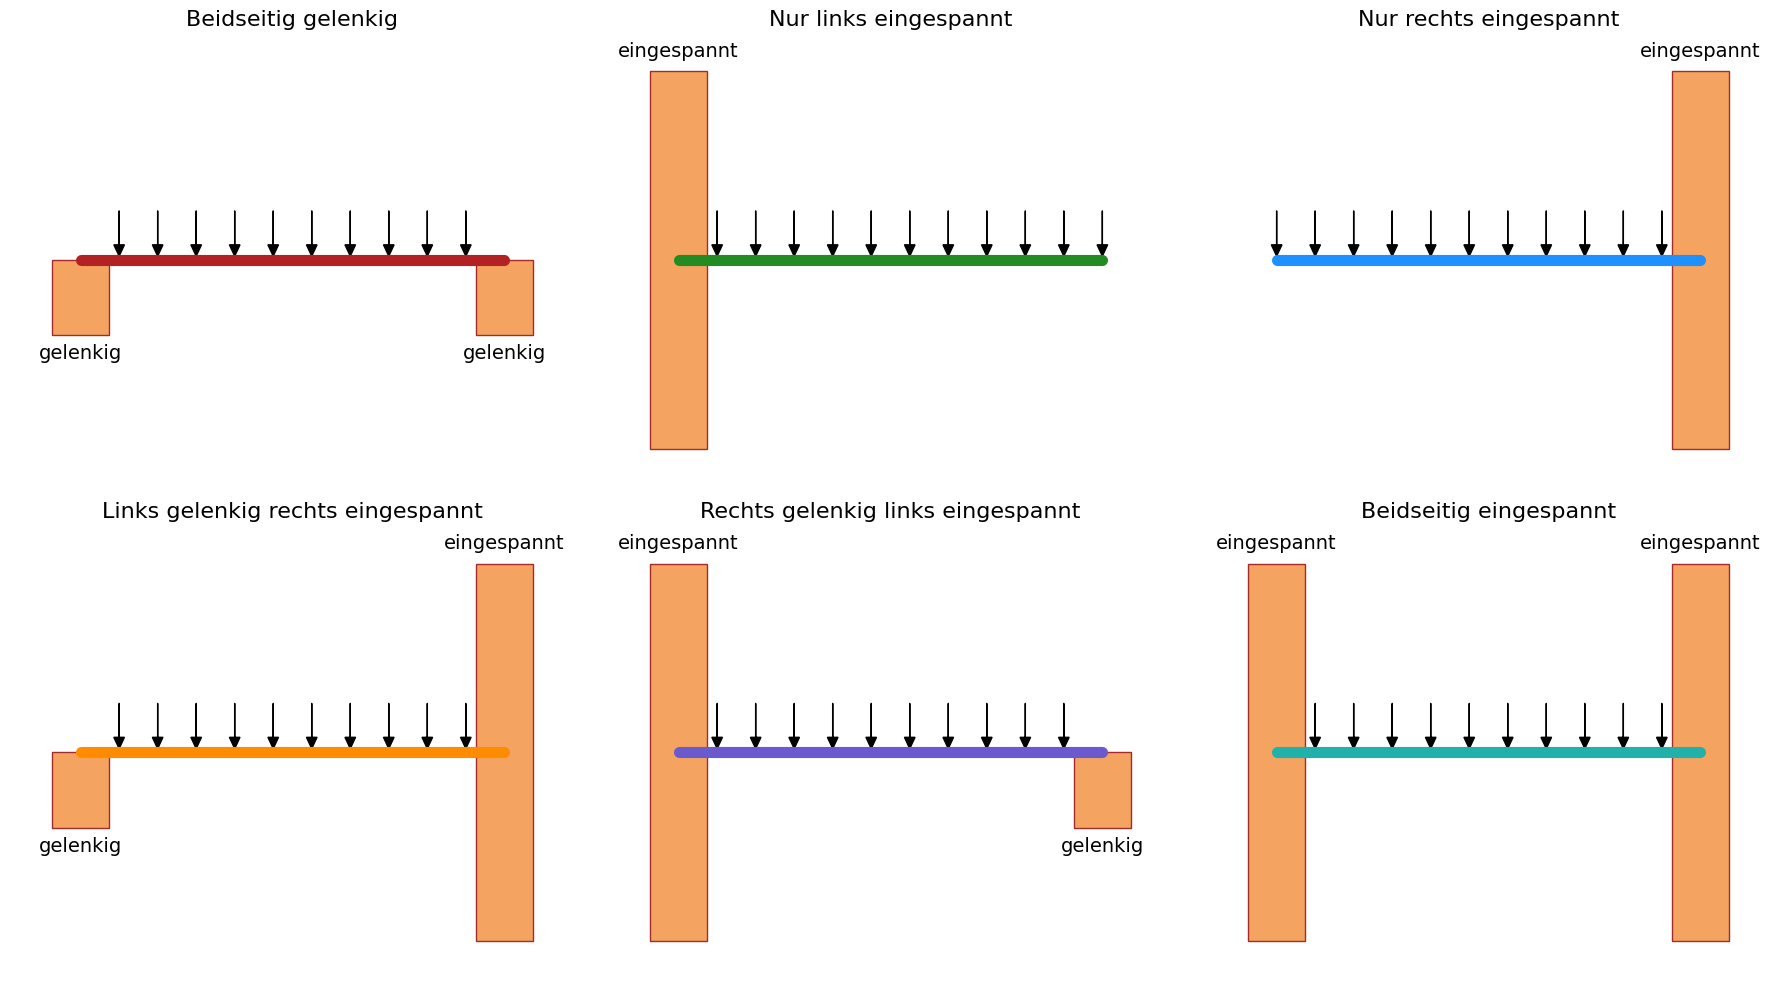

In [9]:
#==================#
# --- Parameter ---#
#==================#

x0, x1 = 0, 6
figsize = (18, 10)
arrow_x = np.linspace(x0, x1, 12)
xlim, ylim = (-1, 7), (-3, 3)

# Balkeneigenschaften
beam_linewidth = 8
beam_capstyle = 'round'
beam_colors = [
    "#B22222",  # firebrick red (kräftiges, dunkles Rot)
    "#228B22",  # forest green (kräftiges Grün)
    "#1E90FF",  # dodger blue (kräftiges Blau)
    "#FF8C00",  # dark orange (kräftiges Orange)
    "#6A5ACD",  # slate blue (sanftes Lila-Blau)
    "#20B2AA"   # light sea green (türkis-grünlich)
]

# Lager-Daten
support_props = {
    "gelenkig":    {"y": -1,   "h": 1, "label_y": -1.3},
    "eingespannt": {"y": -2.5, "h": 5, "label_y": 2.7},
}

# Liste für spätere Verwendung
boundary_conditions = [
    "beidseitig_gelenkig",
    "nur_links_eingespannt",
    "nur_rechts_eingespannt",
    "links_gelenkig_rechts_eingespannt",
    "rechts_gelenkig_links_eingespannt",
    "beidseitig_eingespannt"
]

#==========================#
# --- Hilfsfunktionen  ---#
#==========================#

def draw_support(ax, x, kind):
    prop = support_props[kind]
    ax.add_patch(plt.Rectangle((x - 0.4, prop["y"]), 0.8, prop["h"], facecolor="sandybrown", edgecolor="brown"))
    ax.text(x, prop["label_y"], kind, ha='center', fontsize=14)

def plot_case(ax, bc_name, color):
    ax.axis('off')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    match bc_name:
        case "beidseitig_gelenkig":
            draw_support(ax, x0, "gelenkig")
            draw_support(ax, x1, "gelenkig")
            arrows = arrow_x[1:-1]
        case "nur_links_eingespannt":
            draw_support(ax, x0, "eingespannt")
            arrows = arrow_x[1:]
        case "nur_rechts_eingespannt":
            draw_support(ax, x1, "eingespannt")
            arrows = arrow_x[:-1]
        case "links_gelenkig_rechts_eingespannt":
            draw_support(ax, x0, "gelenkig")
            draw_support(ax, x1, "eingespannt")
            arrows = arrow_x[1:-1]
        case "rechts_gelenkig_links_eingespannt":
            draw_support(ax, x0, "eingespannt")
            draw_support(ax, x1, "gelenkig")
            arrows = arrow_x[1:-1]
        case "beidseitig_eingespannt":
            draw_support(ax, x0, "eingespannt")
            draw_support(ax, x1, "eingespannt")
            arrows = arrow_x[1:-1]
        case _:
            arrows = []

    # Balken
    ax.plot([x0, x1], [0, 0], lw=beam_linewidth, color=color, solid_capstyle=beam_capstyle)

    # Pfeile
    for x in arrows:
        ax.arrow(x, 0.65, 0, -0.6, head_width=0.15, head_length=0.15,
                 fc='black', ec='black', length_includes_head=True)

    # Titel
    ax.set_title(bc_name.replace("_", " ").capitalize(), fontsize=16)

#================#
# --- Plotten ---#
#================#

fig, axs = plt.subplots(2, 3, figsize=figsize)

for ax, bc, color in zip(axs.flat, boundary_conditions, beam_colors):
    plot_case(ax, bc, color)


plt.tight_layout()
plt.show()


In [10]:
# ------------
# Vorbereitung
# -------------

# --- Physikalische Parameter ---

L = 10      # Länge des Balkens in Metern [m]
E = 2.1e11     # Elastizitätsmodul [Pa]
I = 8.3e-6     # Flächenträgheitsmoment [m^4]
EI = E * I     # Biegesteifigkeit: Produkt aus Elastizitätsmodul E und Flächenträgheitsmoment I [N m^2]

# --- Erzeugung der Gitterpunkte (Diskretisierung) ---

N_intervalls = 150               # Anzahl der Unterteilungen des Balkens (Anzahl Gitterintervalle), absichtlich klein gewählt,
                                # um Differenzen zwischen analytischen und numerischen Lösungen zu zeigen
N_nodes = N_intervalls + 1      # Anzahl der Gitterpunkte
x = np.linspace(0, L, N_nodes)  # np.linspace erzeugt N_nodes gleichmäßig verteilte Punkte von 0 bis L
                                # Diese entsprechen den Knotenpunkten x_0, x_1, ..., x_N_intervalls
h = x[1] - x[0]                 # Schrittweite h = Abstand zwischen zwei benachbarten Gitterpunkten

# --- Lastverteilung ---

q0 = 50     # Konstante Streckenlast mit q(x) = q = q0 = 50 [N/m]
q = q0 * np.ones(N_nodes)

In [11]:
def plot_durchbiegung(x, w_expr, beam_color, title, formula_text, text_pos, text_color):
    # w(x) berechnen
    w = w_expr(x)

    # Plot vorbereiten
    plt.figure(figsize=(8, 4))
    plt.plot(x, w, label='Durchbiegung $w(x)$', color=beam_color)
    plt.xlabel('$x$ [m]')
    plt.xlim(0, L)
    plt.ylabel('Durchbiegung $w(x)$ [m]')
    plt.ylim(-0.05 * max(np.abs(w)), 1.05 * max(np.abs(w)))
    plt.title(title)
    plt.grid(True)
    plt.legend()

    # Formeltext einfügen
    plt.text(text_pos[0], text_pos[1] * max(w), formula_text,
             fontsize=14, color=text_color,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # Achse invertieren
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


---

# Analytische Herleitung der Lösung für den Fall eines beidseitig gelenkig gelagerten Balkens

Wir betrachten einen Balken der Länge $L$ mit konstantem Biegesteifigkeitsprodukt $EI$, belastet durch eine konstante, über die Länge verteilte Last $q$. Die Durchbiegung entlang der Längsachse $x \in [0, L]$ wird durch die Biegelinie $w(x)$ beschrieben.

## Differentialgleichung der Biegelinie

Aus der Euler-Bernoulli-Balkentheorie gilt:

$$
EI \frac{d^4 w}{dx^4} = q,
$$

bzw. umgestellt:

$$
\frac{d^4 w}{dx^4} = \frac{q}{EI}.
$$

## Integration der Differentialgleichung

Wir integrieren die Gleichung viermal, um $w(x)$ zu bestimmen:

1. Erste Integration:

$$
\frac{d^3 w}{dx^3} = \int \frac{q}{EI} dx = \frac{q}{EI} x + C_1,
$$

mit Integrationskonstante $C_1$.

2. Zweite Integration:

$$
\frac{d^2 w}{dx^2} = \int \left( \frac{q}{EI} x + C_1 \right) dx = \frac{q}{2 EI} x^2 + C_1 x + C_2,
$$

mit Integrationskonstante $C_2$.

3. Dritte Integration:

$$
\frac{d w}{dx} = \int \left( \frac{q}{2 EI} x^2 + C_1 x + C_2 \right) dx = \frac{q}{6 EI} x^3 + \frac{C_1}{2} x^2 + C_2 x + C_3,
$$

mit Integrationskonstante $C_3$.

4. Vierte Integration:

$$
w(x) = \int \left( \frac{q}{6 EI} x^3 + \frac{C_1}{2} x^2 + C_2 x + C_3 \right) dx = \frac{q}{24 EI} x^4 + \frac{C_1}{6} x^3 + \frac{C_2}{2} x^2 + C_3 x + C_4,
$$

mit Integrationskonstante $C_4$.

Zur Vereinfachung definieren wir neue Konstanten:

$$
C_1' = \frac{C_1}{6}, \quad C_2' = \frac{C_2}{2}, \quad C_3, \quad C_4,
$$

so dass die allgemeine Lösung geschrieben werden kann als

$$
w(x) = \frac{q}{24 EI} x^4 + C_1' x^3 + C_2' x^2 + C_3 x + C_4.
$$

## Randbedingungen für den beidseitig gelenkig gelagerten Balken

Für $x=0$ und $x=L$ gilt:

- Durchbiegung ist null:

$$
w(0) = 0, \quad w(L) = 0,
$$

- Biegemoment ist null, d.h. die zweite Ableitung verschwindet:

$$
w''(0) = 0, \quad w''(L) = 0.
$$

Die zweite Ableitung lautet (unter Verwendung der ursprünglichen Konstanten):

$$
w''(x) = \frac{q}{2 EI} x^2 + 6 C_1' x + 2 C_2'.
$$

## Bestimmung der Integrationskonstanten

1. Aus $w(0)=0$ folgt:

$$
C_4 = 0.
$$

2. Aus $w(L)=0$ folgt:

$$
\frac{q}{24 EI} L^4 + C_1' L^3 + C_2' L^2 + C_3 L + 0 = 0.
$$

3. Aus $w''(0)=0$ folgt:

$$
2 C_2' = 0 \implies C_2' = 0.
$$

4. Aus $w''(L) = 0$ folgt:

$$
\frac{q}{2 EI} L^2 + 6 C_1' L + 0 = 0 \implies 6 C_1' L = - \frac{q}{2 EI} L^2 \implies C_1' = - \frac{q L}{12 EI}.
$$

Setzen wir $C_2' = 0$ und $C_4 = 0$ in Gleichung (2) ein:

$$
\frac{q}{24 EI} L^4 - \frac{q L}{12 EI} L^3 + C_3 L = 0,
$$

was vereinfacht:

$$
\left( \frac{1}{24} - \frac{1}{12} \right) \frac{q L^4}{EI} + C_3 L = 0 \implies - \frac{1}{24} \frac{q L^4}{EI} + C_3 L = 0,
$$

also

$$
C_3 = \frac{q L^3}{24 EI}.
$$

## Endgültige Lösung

Somit ergibt sich für die Durchbiegung $w(x)$

$$
\boxed{
w(x) = \frac{q}{24 EI} x^4 - \frac{q L}{12 EI} x^3 + \frac{q L^3}{24 EI} x,
}
$$

die die Biegelinie eines beidseitig gelenkig gelagerten Balkens unter einer konstanten verteilten Last beschreibt.


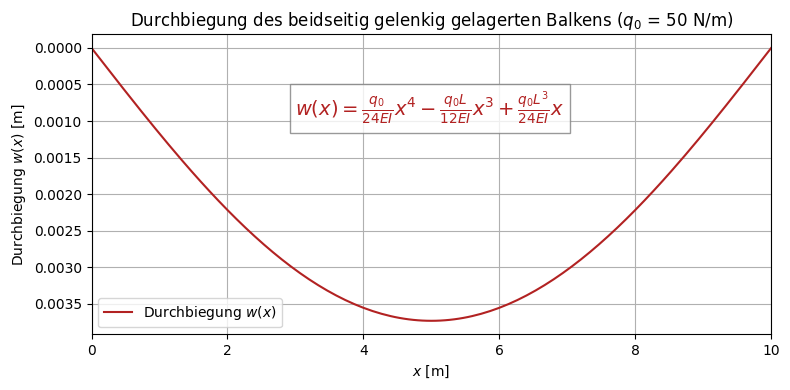

In [12]:
# --- Beidseitig gelenkig ---
def analytical_solution_beidseitig_gelenkig(x):
    """Analytische Lösung für beidseitig gelenkigen Balken mit konstanter Last."""
    return (q0 / (24 * EI)) * x**4 - ((q0 * L)/(12 * EI)) * x**3 + ((q0 * L**3)/(24 * EI)) * x

w_expr = analytical_solution_beidseitig_gelenkig
beam_color = text_color = beam_colors[0]
title = f'Durchbiegung des beidseitig gelenkig gelagerten Balkens ($q_0$ = {q0} N/m)'
formula_text = r'$w(x) = \frac{q_0}{24EI} x^{4} - \frac{q_0L}{12EI} x^{3} + \frac{q_0L^{3}}{24EI} x$'
text_pos = (0.3 * L, 0.25)

plot_durchbiegung(x, w_expr, beam_color, title, formula_text, text_pos, text_color)


# Analytische Herleitung der Lösung für den Fall links eingespannt und rechts frei

Wir betrachten einen Balken der Länge $L$ mit konstanter Querschnittsträgheit $EI$, belastet durch eine gleichmäßig verteilte Last $q$. Die Durchbiegung entlang des Balkens wird durch die Funktion $w(x)$ beschrieben.

## Differentialgleichung der Biegelinie

Nach Euler-Bernoulli-Balkentheorie gilt:

$$
EI \frac{d^4 w}{dx^4} = q,
$$

bzw. umgestellt:

$$
\frac{d^4 w}{dx^4} = \frac{q}{EI}.
$$

## Integration der Differentialgleichung

Wir integrieren die Differentialgleichung viermal, um die Durchbiegung $w(x)$ zu erhalten:

1. Erste Integration:

$$
\frac{d^3 w}{dx^3} = \int \frac{q}{EI} \, dx = \frac{q}{EI} x + C_1,
$$

mit Integrationskonstante $C_1$.

2. Zweite Integration:

$$
\frac{d^2 w}{dx^2} = \int \left( \frac{q}{EI} x + C_1 \right) dx = \frac{q}{2 EI} x^2 + C_1 x + C_2,
$$

mit Integrationskonstante $C_2$.

3. Dritte Integration:

$$
\frac{d w}{dx} = \int \left( \frac{q}{2 EI} x^2 + C_1 x + C_2 \right) dx = \frac{q}{6 EI} x^3 + \frac{C_1}{2} x^2 + C_2 x + C_3,
$$

mit Integrationskonstante $C_3$.

4. Vierte Integration:

$$
w(x) = \int \left( \frac{q}{6 EI} x^3 + \frac{C_1}{2} x^2 + C_2 x + C_3 \right) dx = \frac{q}{24 EI} x^4 + \frac{C_1}{6} x^3 + \frac{C_2}{2} x^2 + C_3 x + C_4,
$$

mit Integrationskonstante $C_4$.

Zur Vereinfachung schreiben wir die Lösung als

$$
w(x) = \frac{q}{24 EI} x^4 + C_1' x^3 + C_2' x^2 + C_3 x + C_4,
$$

wobei

$$
C_1' = \frac{C_1}{6}, \quad C_2' = \frac{C_2}{2}.
$$

## Randbedingungen für den Balken mit linksseitiger Einspannung und rechtsfrei

- Bei $x=0$ (eingespannt):

  - Durchbiegung ist null:

  $$
  w(0) = 0,
  $$

  - Neigung ist null (erste Ableitung):

  $$
  w'(0) = 0.
  $$

- Bei $x=L$ (frei):

  - Biegemoment ist null (zweite Ableitung):

  $$
  w''(L) = 0,
  $$

  - Querkraft ist null (dritte Ableitung):

  $$
  w'''(L) = 0.
  $$

## Ableitungen von $w(x)$

Aus der allgemeinen Form ergeben sich

$$
w'(x) = \frac{q}{6 EI} x^3 + 3 C_1' x^2 + 2 C_2' x + C_3,
$$

$$
w''(x) = \frac{q}{2 EI} x^2 + 6 C_1' x + 2 C_2',
$$

$$
w'''(x) = \frac{q}{EI} x + 6 C_1'.
$$

## Einsetzen der Randbedingungen

1. Aus $w(0) = 0$ folgt:

$$
C_4 = 0.
$$

2. Aus $w'(0) = 0$ folgt:

$$
C_3 = 0.
$$

3. Aus $w''(L) = 0$ folgt:

$$
\frac{q}{2 EI} L^2 + 6 C_1' L + 2 C_2' = 0.
$$

4. Aus $w'''(L) = 0$ folgt:

$$
\frac{q}{EI} L + 6 C_1' = 0 \quad \Rightarrow \quad C_1' = -\frac{q L}{6 EI}.
$$

## Bestimmung von $C_2'$

Setze $C_1'$ in die Gleichung für $w''(L)$ ein:

$$
\frac{q}{2 EI} L^2 + 6 \left(-\frac{q L}{6 EI}\right) L + 2 C_2' = 0,
$$

$$
\frac{q}{2 EI} L^2 - \frac{q}{EI} L^2 + 2 C_2' = 0,
$$

$$
-\frac{q}{2 EI} L^2 + 2 C_2' = 0 \quad \Rightarrow \quad C_2' = \frac{q L^2}{4 EI}.
$$

## Endgültige Lösung

Somit lautet die Durchbiegung für den links eingespannten und rechts freien Balken:

$$
\boxed{
w(x) = \frac{q}{24 EI} x^4 - \frac{q L}{6 EI} x^3 + \frac{q L^2}{4 EI} x^2,
}
$$

was die Biegelinie unter der gegebenen Belastung und Randbedingungen vollständig beschreibt.


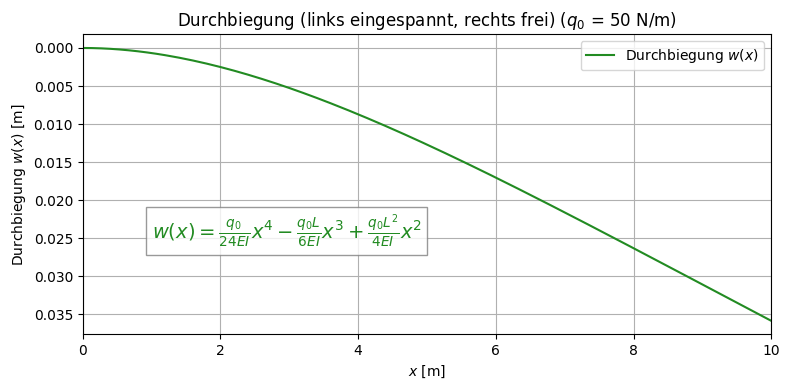

In [13]:
# --- Links eingespannt, rechts frei ---
def analytical_solution_eingespannt_links(x):
    """Analytische Lösung für Balken mit links eingespannt und rechts frei."""
    return (q0 / (24 * EI)) * x**4 - ((q0 * L)/(6 * EI)) * x**3 + ((q0 * L**2)/(4 * EI)) * x**2

w_expr = analytical_solution_eingespannt_links
beam_color = text_color = beam_colors[1]
title = f'Durchbiegung (links eingespannt, rechts frei) ($q_0$ = {q0} N/m)'
formula_text = r'$w(x) = \frac{q_0}{24EI} x^{4} - \frac{q_0L}{6EI} x^{3} + \frac{q_0L^{2}}{4EI} x^{2}$'
text_pos = (0.1 * L, 0.7)

plot_durchbiegung(x, w_expr, beam_color, title, formula_text, text_pos, text_color)

# Analytische Herleitung der Lösung für Balken mit links frei und rechts eingespannt

Wir betrachten denselben Balken der Länge $L$, mit konstantem Biegesteifigkeitsprodukt $EI$ und einer gleichmäßig verteilten Last $q$.

## Differentialgleichung und allgemeine Lösung

Die Durchbiegung $w(x)$ erfüllt die Euler-Bernoulli-Balkengleichung

$$
EI \frac{d^4 w}{dx^4} = q,
$$

bzw.

$$
\frac{d^4 w}{dx^4} = \frac{q}{EI}.
$$

Durch vierfache Integration erhält man die allgemeine Lösung:

$$
w(x) = \frac{q}{24 EI} x^4 + C_1 x^3 + C_2 x^2 + C_3 x + C_4,
$$

mit vier Integrationskonstanten $C_1$, $C_2$, $C_3$ und $C_4$.

## Randbedingungen

Für den Fall **links frei (x=0)** und **rechts eingespannt (x=L)** gelten:

- Links frei ($x=0$):
  - Biegemoment null: $w''(0) = 0$
  - Querkraft null: $w'''(0) = 0$

- Rechts eingespannt ($x=L$):
  - Durchbiegung null: $w(L) = 0$
  - Steifigkeit (erste Ableitung) null: $w'(L) = 0$

## Ableitungen von $w(x)$

\begin{aligned}
w'(x) &= \frac{q}{6 EI} x^3 + 3 C_1 x^2 + 2 C_2 x + C_3, \\
w''(x) &= \frac{q}{2 EI} x^2 + 6 C_1 x + 2 C_2, \\
w'''(x) &= \frac{q}{EI} x + 6 C_1.
\end{aligned}

## Einsetzen der Randbedingungen

1. Aus $w''(0) = 0$ folgt:

$$
2 C_2 = 0 \implies C_2 = 0.
$$

2. Aus $w'''(0) = 0$ folgt:

$$
6 C_1 = 0 \implies C_1 = 0.
$$

3. Aus $w(L) = 0$ folgt:

$$
\frac{q}{24 EI} L^4 + C_3 L + C_4 = 0.
$$

4. Aus $w'(L) = 0$ folgt:

$$
\frac{q}{6 EI} L^3 + C_3 = 0 \implies C_3 = - \frac{q}{6 EI} L^3.
$$

## Bestimmung von $C_4$

Einsetzen von $C_3$ in (3):

$$
\frac{q}{24 EI} L^4 - \frac{q}{6 EI} L^3 \cdot L + C_4 = 0,
$$

was sich vereinfacht zu

$$
\frac{q}{24 EI} L^4 - \frac{q}{6 EI} L^4 + C_4 = 0,
$$

und weiter

$$
-\frac{q}{8 EI} L^4 + C_4 = 0 \implies C_4 = \frac{q}{8 EI} L^4.
$$

## Endgültige Lösung

Somit lautet die Durchbiegung $w(x)$

$$
\boxed{
w(x) = \frac{q}{24 EI} x^4 - \frac{q}{6 EI} L^3 x + \frac{q}{8 EI} L^4,
}
$$

die die Biegelinie eines Balkens mit links frei und rechts eingespannt unter gleichmäßiger Belastung beschreibt.


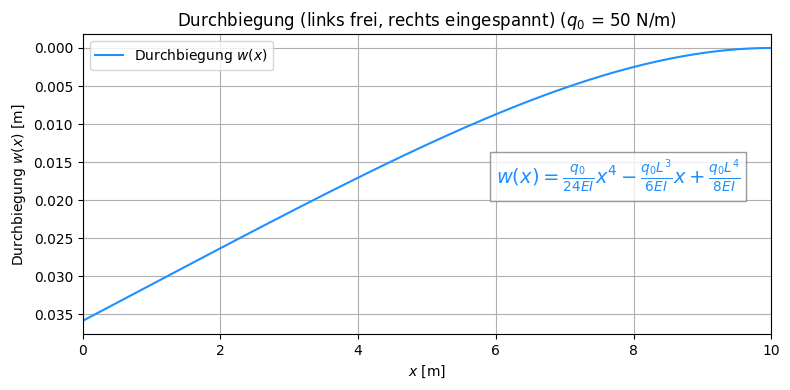

In [14]:
# --- Links frei, rechts eingespannt ---
def analytical_solution_eingespannt_rechts(x):
    """Analytische Lösung für Balken mit links frei und rechts eingespannt."""
    # Spiegelung von links eingespannt, frei rechts: w(x) = W(L-x)
    return (q0 / (24 * EI)) * x**4 - (q0 * L**3 / (6 * EI)) * x + (q0 * L**4 / (8 * EI))

w_expr = analytical_solution_eingespannt_rechts
beam_color = text_color = beam_colors[2]
title = f'Durchbiegung (links frei, rechts eingespannt) ($q_0$ = {q0} N/m)'
formula_text = r'$w(x) = \frac{q_0}{24EI} x^{4} - \frac{q_0L^{3}}{6EI} x + \frac{q_0L^{4}}{8EI}$'
text_pos = (0.6 * L, 0.5)

plot_durchbiegung(x, w_expr, beam_color, title, formula_text, text_pos, text_color)


# Analytische Herleitung der Lösung für Balken mit links gelenkig und rechts eingespannt

Wir betrachten einen Balken der Länge $L$, mit konstanter Biegesteifigkeit $EI$ und einer gleichmäßig verteilten Last $q$ über die gesamte Länge.

## Differentialgleichung und allgemeine Lösung

Die Biegelinie $w(x)$ erfüllt die Euler-Bernoulli-Differentialgleichung:

$$
EI \frac{d^4 w}{dx^4} = q \quad \Rightarrow \quad \frac{d^4 w}{dx^4} = \frac{q}{EI}.
$$

Durch vierfache Integration ergibt sich die allgemeine Lösung der Biegelinie:

$$
w(x) = \frac{q}{24 EI} x^4 + C_1 x^3 + C_2 x^2 + C_3 x + C_4,
$$

mit den Integrationskonstanten $C_1$, $C_2$, $C_3$, $C_4$.

## Randbedingungen

Für den Fall **links gelenkig (x = 0)** und **rechts eingespannt (x = L)** gelten die folgenden Randbedingungen:

- Links gelenkig ($x=0$):
  - Durchbiegung null: $w(0) = 0$
  - Biegemoment null: $w''(0) = 0$
- Rechts eingespannt ($x=L$):
  - Durchbiegung null: $w(L) = 0$
  - Neigung null: $w'(L) = 0$

## Ableitungen

\begin{aligned}
w'(x) &= \frac{q}{6 EI} x^3 + 3 C_1 x^2 + 2 C_2 x + C_3, \\\\
w''(x) &= \frac{q}{2 EI} x^2 + 6 C_1 x + 2 C_2, \\\\
w'''(x) &= \frac{q}{EI} x + 6 C_1.
\end{aligned}

## Einsetzen der Randbedingungen

1. Aus $w(0) = 0$:

$$
C_4 = 0.
$$

2. Aus $w''(0) = 0$:

$$
2 C_2 = 0 \Rightarrow C_2 = 0.
$$

3. Aus $w(L) = 0$:

$$
\frac{q}{24 EI} L^4 + C_1 L^3 + C_3 L = 0. \quad \text{(Gleichung A)}
$$

4. Aus $w'(L) = 0$:

$$
\frac{q}{6 EI} L^3 + 3 C_1 L^2 + C_3 = 0. \quad \text{(Gleichung B)}
$$

## Lösen des Gleichungssystems

Aus Gleichung B:

$$
C_3 = -\frac{q}{6 EI} L^3 - 3 C_1 L^2
$$

In Gleichung A einsetzen:

\begin{aligned}
\frac{q}{24 EI} L^4 + C_1 L^3 - \left( \frac{q}{6 EI} L^3 + 3 C_1 L^2 \right) L &= 0 \\\\
\frac{q}{24 EI} L^4 + C_1 L^3 - \frac{q}{6 EI} L^4 - 3 C_1 L^3 &= 0 \\\\
\left( \frac{q}{24 EI} - \frac{q}{6 EI} \right) L^4 - 2 C_1 L^3 &= 0 \\\\
-\frac{q}{8 EI} L^4 - 2 C_1 L^3 &= 0
\end{aligned}

Daraus folgt:

$$
C_1 = -\frac{q}{16 EI} L.
$$

Einsetzen in $C_3$:

\begin{aligned}
C_3 &= -\frac{q}{6 EI} L^3 - 3 \cdot \left( -\frac{q}{16 EI} L \right) L^2 \\\\
&= -\frac{q}{6 EI} L^3 + \frac{3 q}{16 EI} L^3 = \left( -\frac{8}{48} + \frac{9}{48} \right) \frac{q}{EI} L^3 = \frac{1}{48} \frac{q}{EI} L^3
\end{aligned}

## Endgültige Lösung

Die Durchbiegung des Balkens ergibt sich damit zu:

$$
\boxed{
w(x) = \frac{q}{24 EI} x^4 - \frac{q}{16 EI} L x^3 + \frac{q}{48 EI} L^3 x
}
$$

Dies beschreibt die Biegelinie eines Balkens, der links gelenkig gelagert und rechts fest eingespannt ist, unter einer konstant verteilten Last.


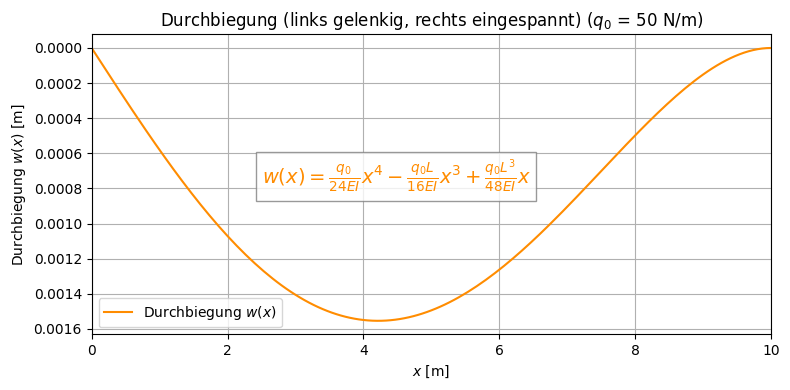

In [15]:
# --- Links gelenkig, rechts eingespannt ---
def analytical_solution_links_gelenkig_rechts_eingespannt(x):
    """Analytische Lösung für Balken mit links gelenkig und rechts eingespannt."""
    return (
        (q0 / (24 * EI)) * x**4
        - (q0 * L / (16 * EI)) * x**3
        + (q0 * L**3 / (48 * EI)) * x
    )

w_expr = analytical_solution_links_gelenkig_rechts_eingespannt
title = f'Durchbiegung (links gelenkig, rechts eingespannt) ($q_0$ = {q0} N/m)'
formula_text = r'$w(x) = \frac{q_0}{24EI}x^4 - \frac{q_0L}{16EI}x^3 + \frac{q_0L^3}{48EI}x$'
text_pos = (0.25 * L, 0.5)
beam_color = text_color = beam_colors[3]

plot_durchbiegung(x, w_expr, beam_color, title, formula_text, text_pos, text_color)


# Analytische Herleitung der Lösung für Balken mit links eingespannt und rechts gelenkig

Wir betrachten einen Balken der Länge $L$, mit konstanter Biegesteifigkeit $EI$ und einer gleichmäßig verteilten Last $q$.

## Differentialgleichung und allgemeine Lösung

Die Biegelinie $w(x)$ erfüllt die Euler-Bernoulli-Differentialgleichung:

$$
EI \frac{d^4 w}{dx^4} = q \quad \Rightarrow \quad \frac{d^4 w}{dx^4} = \frac{q}{EI}.
$$

Die allgemeine Lösung nach vierfacher Integration lautet:

$$
w(x) = \frac{q}{24 EI} x^4 + C_1 x^3 + C_2 x^2 + C_3 x + C_4,
$$

mit den Integrationskonstanten $C_1, C_2, C_3, C_4$.

## Randbedingungen

Für den Fall **links eingespannt (x=0)** und **rechts gelenkig (x=L)** gelten:

- Links eingespannt ($x=0$):
  - Durchbiegung null: $w(0) = 0$
  - Neigung null: $w'(0) = 0$

- Rechts gelenkig ($x=L$):
  - Durchbiegung null: $w(L) = 0$
  - Biegemoment null: $w''(L) = 0$

## Ableitungen von $w(x)$

\begin{aligned}
w'(x) &= \frac{q}{6 EI} x^3 + 3 C_1 x^2 + 2 C_2 x + C_3, \\\\
w''(x) &= \frac{q}{2 EI} x^2 + 6 C_1 x + 2 C_2.
\end{aligned}

## Einsetzen der Randbedingungen

1. Aus $w(0) = 0$ folgt:

$$
C_4 = 0.
$$

2. Aus $w'(0) = 0$ folgt:

$$
C_3 = 0.
$$

3. Aus $w(L) = 0$ folgt:

$$
\frac{q}{24 EI} L^4 + C_1 L^3 + C_2 L^2 = 0. \quad \text{(Gleichung A)}
$$

4. Aus $w''(L) = 0$ folgt:

$$
\frac{q}{2 EI} L^2 + 6 C_1 L + 2 C_2 = 0. \quad \text{(Gleichung B)}
$$

## Lösen des Gleichungssystems

Aus Gleichung B:

$$
2 C_2 = -\frac{q}{2 EI} L^2 - 6 C_1 L \implies C_2 = -\frac{q}{4 EI} L^2 - 3 C_1 L
$$

Einsetzen in Gleichung A:

\begin{aligned}
\frac{q}{24 EI} L^4 + C_1 L^3 + \left(-\frac{q}{4 EI} L^2 - 3 C_1 L \right) L^2 &= 0 \\\\
\frac{q}{24 EI} L^4 + C_1 L^3 - \frac{q}{4 EI} L^4 - 3 C_1 L^3 &= 0 \\\\
\left( \frac{q}{24 EI} - \frac{q}{4 EI} \right) L^4 + (C_1 - 3 C_1) L^3 &= 0 \\\\
-\frac{5 q}{24 EI} L^4 - 2 C_1 L^3 &= 0
\end{aligned}

Daraus folgt:

$$
C_1 = -\frac{5 q}{48 EI} L.
$$

Dann:

$$
C_2 = -\frac{q}{4 EI} L^2 - 3 \cdot \left(-\frac{5 q}{48 EI} L \right) L = -\frac{q}{4 EI} L^2 + \frac{15 q}{48 EI} L^2 = \frac{q}{16 EI} L^2.
$$

## Endgültige Lösung

Die Durchbiegung des Balkens lautet:

$$
\boxed{
w(x) = \frac{q}{24 EI} x^4 - \frac{5 q}{48 EI} L x^3 + \frac{q}{16 EI} L^2 x^2
}
$$

Diese Funktion beschreibt die Biegelinie eines Balkens mit links eingespanntem und rechts gelenkigem Lager unter einer konstant verteilten Last.


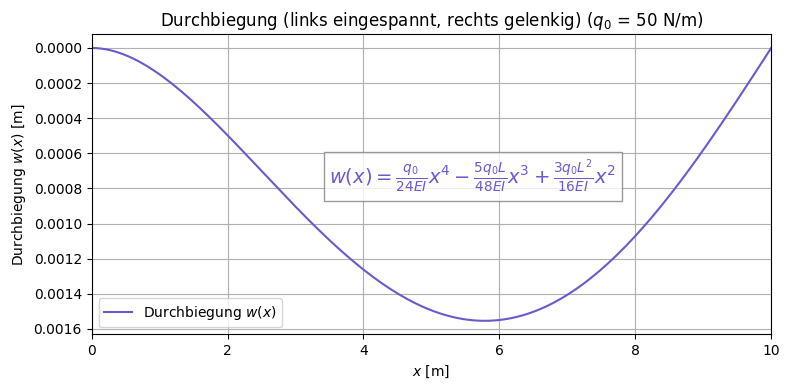

In [16]:
# --- Rechts gelenkig, links eingespannt ---
def analytical_solution_rechts_gelenkig_links_eingespannt(x):
    """Analytische Lösung für Balken mit rechts gelenkig und links eingespannt."""
    return (
        (q0 / (24 * EI)) * x**4
        - (5 * q0 * L / (48 * EI)) * x**3
        + (q0 * L**2 / (16 * EI)) * x**2
    )

w_expr = analytical_solution_rechts_gelenkig_links_eingespannt
title = f'Durchbiegung (links eingespannt, rechts gelenkig) ($q_0$ = {q0} N/m)'
formula_text = r'$w(x) = \frac{q_0}{24EI}x^4 - \frac{5q_0L}{48EI}x^3 + \frac{3q_0L^2}{16EI}x^2$'
text_pos = (0.35 * L, 0.5)
beam_color = text_color = beam_colors[4]

plot_durchbiegung(x, w_expr, beam_color, title, formula_text, text_pos, text_color)


# Analytische Herleitung der Lösung für Balken beidseitig eingespannt

Wir betrachten einen Balken der Länge $L$, mit konstanter Biegesteifigkeit $EI$ und einer gleichmäßig verteilten Last $q$.

## Differentialgleichung und allgemeine Lösung

Die Durchbiegung $w(x)$ erfüllt die Euler-Bernoulli-Gleichung:

$$
EI \frac{d^4 w}{dx^4} = q \quad \Rightarrow \quad \frac{d^4 w}{dx^4} = \frac{q}{EI}.
$$

Die allgemeine Lösung ist:

$$
w(x) = \frac{q}{24 EI} x^4 + C_1 x^3 + C_2 x^2 + C_3 x + C_4,
$$

mit den Integrationskonstanten $C_1, C_2, C_3, C_4$.

## Randbedingungen

Für den Fall **beidseitig eingespannt** ($x=0$ und $x=L$) gelten:

- Links eingespannt ($x=0$):
  - Durchbiegung null: $w(0) = 0$
  - Neigung null: $w'(0) = 0$
  
- Rechts eingespannt ($x=L$):
  - Durchbiegung null: $w(L) = 0$
  - Neigung null: $w'(L) = 0$

## Ableitungen von $w(x)$

\begin{aligned}
w'(x) &= \frac{q}{6 EI} x^3 + 3 C_1 x^2 + 2 C_2 x + C_3.
\end{aligned}

## Einsetzen der Randbedingungen

1. Aus $w(0) = 0$ folgt:

$$
C_4 = 0.
$$

2. Aus $w'(0) = 0$ folgt:

$$
C_3 = 0.
$$

3. Aus $w(L) = 0$ folgt:

$$
\frac{q}{24 EI} L^4 + C_1 L^3 + C_2 L^2 = 0.
$$

4. Aus $w'(L) = 0$ folgt:

$$
\frac{q}{6 EI} L^3 + 3 C_1 L^2 + 2 C_2 L = 0.
$$

## Lösen des Gleichungssystems

Aus (3) und (4) erhält man:

\begin{cases}
\frac{q}{24 EI} L^4 + C_1 L^3 + C_2 L^2 = 0 \\
\frac{q}{6 EI} L^3 + 3 C_1 L^2 + 2 C_2 L = 0
\end{cases}

Durch Umformen folgt:

$$
C_1 = -\frac{q}{12 EI} L, \quad C_2 = \frac{q}{24 EI} L^2.
$$

## Endgültige Lösung

Die Durchbiegung ist somit:

$$
\boxed{
w(x) = \frac{q}{24 EI} x^4 - \frac{q}{12 EI} L x^3 + \frac{q}{24 EI} L^2 x^2.
}
$$

Diese Funktion beschreibt die Biegelinie eines Balkens, der beidseitig fest eingespannt und mit einer konstanten verteilten Last belastet ist.


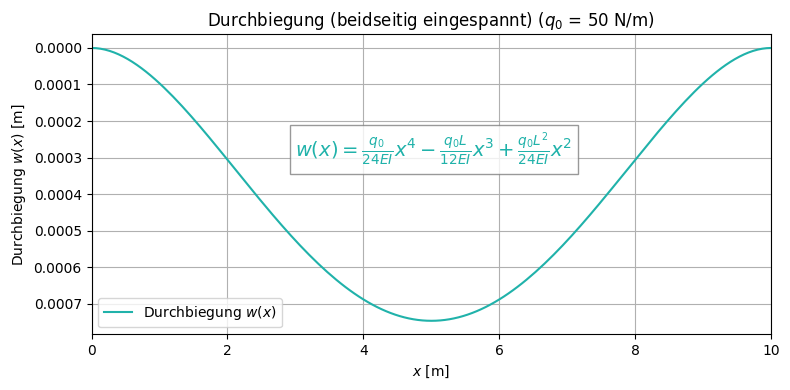

In [17]:
# --- Beidseitig eingespannt ---
def analytical_solution_beidseitig_eingespannt(x):
    """Analytische Lösung für Balken beidseitig eingespannt."""
    return (
        (q0 / (24 * EI)) * x**4
        - (q0 * L / (12 * EI)) * x**3
        + (q0 * L**2 / (24 * EI)) * x**2
    )

w_expr = analytical_solution_beidseitig_eingespannt
title = f'Durchbiegung (beidseitig eingespannt) ($q_0$ = {q0} N/m)'
formula_text = r'$w(x) = \frac{q_0}{24EI}x^4 - \frac{q_0L}{12EI}x^3 + \frac{q_0L^2}{24EI}x^2$'
text_pos = (0.3 * L, 0.4)
beam_color = text_color = beam_colors[5]

plot_durchbiegung(x, w_expr, beam_color, title, formula_text, text_pos, text_color)


In [18]:
# wird später benötigt
analytical_solutions = {
        "beidseitig_gelenkig": analytical_solution_beidseitig_gelenkig,
        "nur_links_eingespannt": analytical_solution_eingespannt_links,
        "nur_rechts_eingespannt": analytical_solution_eingespannt_rechts,
        "links_gelenkig_rechts_eingespannt": analytical_solution_links_gelenkig_rechts_eingespannt,
        "rechts_gelenkig_links_eingespannt": analytical_solution_rechts_gelenkig_links_eingespannt,
        "beidseitig_eingespannt": analytical_solution_beidseitig_eingespannt
        
    }

### Analytische Herleitung der Finite-Differenzen-Diskretisierung für die vierte Ableitung

Um die Differentialgleichung der Biegelinie numerisch zu lösen, approximieren wir die Ableitungen durch endliche Differenzen auf einem diskreten Gitter.

**Diskretisierung des Balkens**  
Wir teilen den Balken der Länge $L$ in $N$ gleich große Abschnitte auf, sodass wir die Stützstellen  
$$
x_0, x_1, \ldots, x_N
$$  
mit Abstand  
$$
h = \frac{L}{N}
$$  
erhalten. Die Auslenkung an diesen Punkten schreiben wir als $w_i = w(x_i)$.

---


### Taylorreihen: Theorie, Geschichte und Anwendung

Die [Taylorreihe](https://de.wikipedia.org/wiki/Taylorreihe) ist ein fundamentaler Begriff in der Analysis und numerischen Mathematik, der es erlaubt, differenzierbare Funktionen durch unendliche Potenzreihen in der Umgebung eines Punktes darzustellen. Dies ermöglicht nicht nur theoretische Einsichten in das Verhalten von Funktionen, sondern bildet auch die Grundlage für zahlreiche numerische Verfahren, wie z. B. finite Differenzen, Approximationen und Lösung von Differentialgleichungen.

#### Historischer Hintergrund

Die Idee, Funktionen als unendliche Summen von Potenzen darzustellen, lässt sich bis in die Anfänge der Analysis zurückverfolgen. Die heutige Form der Taylorreihe ist nach dem englischen Mathematiker [Brook Taylor (1685–1731)](https://de.wikipedia.org/wiki/Brook_Taylor) benannt, der 1715 die nach ihm benannte Formel veröffentlichte. Allerdings hatten schon Mathematiker wie James Gregory, Isaac Newton und Gottfried Wilhelm Leibniz frühere Formen dieser Reihen entwickelt und angewandt.

Die Taylorreihe stellt eine Verallgemeinerung der bekannten Maclaurin-Reihe dar, welche speziell am Punkt $x=0$ entwickelt wird. Die Taylorreihe an einem allgemeinen Punkt $x = a$ wurde durch Taylor formalisiert und später von Mathematikern wie Augustin-Louis Cauchy rigoros untersucht und bewiesen.

#### Mathematische Theorie und Herleitung

Sei $f:\mathbb{R} \to \mathbb{R}$ eine Funktion, die in einer Umgebung von $a \in \mathbb{R}$ unendlich oft differenzierbar ist. Dann lässt sich $f$ um den Punkt $a$ als Potenzreihe darstellen:

$$
f(x) = \sum_{n=0}^\infty \frac{f^{(n)}(a)}{n!} (x - a)^n,
$$

wobei $f^{(n)}(a)$ die $n$-te Ableitung von $f$ an der Stelle $a$ bezeichnet, und $n!$ die Fakultät von $n$ ist.

Die Taylorreihe ergibt sich durch wiederholtes Anwenden der Taylorformel, welche besagt, dass für ein hinreichend glattes $f$ gilt:

$$
f(x) = \sum_{n=0}^N \frac{f^{(n)}(a)}{n!} (x - a)^n + R_N(x),
$$

wobei $R_N(x)$ der Restterm ist, der die Differenz zwischen der Funktion und ihrem Polynom $N$-ter Ordnung beschreibt. Der Restterm kann z.B. in der Lagrange-Form geschrieben werden als:

$$
R_N(x) = \frac{f^{(N+1)}(\xi)}{(N+1)!} (x - a)^{N+1}
$$

für ein geeignetes $\xi$ zwischen $a$ und $x$. Unter bestimmten Bedingungen verschwindet $R_N(x)$ für $N \to \infty$, sodass die Taylorreihe in diesem Fall tatsächlich die Funktion exakt darstellt.

#### Beispiel: Taylorreihe der Exponentialfunktion

Die Exponentialfunktion $e^x$ lässt sich an $a=0$ (Maclaurin-Reihe) als

$$
e^x = \sum_{n=0}^\infty \frac{x^n}{n!} = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \ldots
$$

darstellen, wobei alle Ableitungen von $e^x$ gleich $e^x$ sind.

#### Anwendung auf Finite Differenzen und numerische Verfahren

In numerischen Verfahren, insbesondere bei der Approximation von Ableitungen, wird die Taylorreihe genutzt, um den Wert einer Funktion an diskreten Punkten um eine Stelle $x$ zu entwickeln. **Dadurch können Ableitungen durch Linearkombinationen von Funktionswerten an benachbarten Punkten approximiert werden**.

Für eine kleine Verschiebung $h$ kann man schreiben:

$$
f(x + h) = f(x) + h f'(x) + \frac{h^2}{2} f''(x) + \frac{h^3}{6} f^{(3)}(x) + \ldots
$$

Analog für $f(x - h)$. Durch geschicktes Addieren und Subtrahieren dieser Entwicklungen lassen sich z.B. zentrale Differenzenformeln für die erste, zweite oder höhere Ableitungen herleiten.

Dies ist die Grundlage für die finite-Differenzen-Methode, mit der Differentialgleichungen diskretisiert und numerisch gelöst werden können, genau wie bei der Herleitung der finiten Differenzen für die vierte Ableitung in der Biegelinien-Differentialgleichung.

---



### Herleitung der Finite-Differenzen-Approximation für die vierte Ableitung

Finite Differenzen basieren auf der Taylorentwicklung einer Funktion $w$ um einen Punkt $x$. Allgemein gilt für ein kleines $h$ und eine beliebige Verschiebung $m \in \mathbb{Z}$:

$$
w(x + m h) = \sum_{k=0}^\infty \frac{w^{(k)}(x)}{k!} m^k h^k
$$

Das bedeutet, der Funktionswert an $x + m h$ lässt sich als unendliche Summe von Ableitungen an $x$ multipliziert mit Potenzen von $m h$ ausdrücken.

Um eine numerische Approximation der vierten Ableitung $w^{(4)}(x)$ zu erhalten, betrachten wir die Taylorreihen von $w$ an den benachbarten Punkten $x \pm h$ und $x \pm 2h$:

$$
\begin{aligned}
w(x + h) &= w(x) + h w'(x) + \frac{h^2}{2} w''(x) + \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + O(h^5) \\
w(x - h) &= w(x) - h w'(x) + \frac{h^2}{2} w''(x) - \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + O(h^5) \\
w(x + 2h) &= w(x) + 2h w'(x) + 2 h^2 w''(x) + \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + O(h^5) \\
w(x - 2h) &= w(x) - 2h w'(x) + 2 h^2 w''(x) - \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + O(h^5)
\end{aligned}
$$

**Jetzt setzen wir diese Taylorreihen in eine allgemeine Linearkombination ein:**  

$$
a \cdot w(x - 2h) + b \cdot w(x - h) + c \cdot w(x) + d \cdot w(x + h) + e \cdot w(x + 2h)
$$

Dabei ersetzen wir jeden Term durch seine Taylor-Entwicklung um $x$:

$$
\begin{aligned}
& a \left[ w(x) - 2h w'(x) + 2 h^2 w''(x) - \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + \ldots \right] \\
+& b \left[ w(x) - h w'(x) + \frac{h^2}{2} w''(x) - \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + \ldots \right] \\
+& c \cdot w(x) \\
+& d \left[ w(x) + h w'(x) + \frac{h^2}{2} w''(x) + \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + \ldots \right] \\
+& e \left[ w(x) + 2h w'(x) + 2 h^2 w''(x) + \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + \ldots \right]
\end{aligned}
$$

Nun fassen wir alle Terme zusammen, indem wir nach den Ableitungen von $w$ an der Stelle $x$ gruppieren:

$$
\begin{aligned}
& (a + b + c + d + e) \cdot w(x) \\
+& (-2a - b + d + 2e) \cdot h w'(x) \\
+& \left( 2a + \frac{b}{2} + \frac{d}{2} + 2e \right) \cdot h^2 w''(x) \\
+& \left( -\frac{4}{3} a - \frac{b}{6} + \frac{d}{6} + \frac{4}{3} e \right) \cdot h^3 w^{(3)}(x) \\
+& \left( \frac{2}{3} a + \frac{b}{24} + \frac{d}{24} + \frac{2}{3} e \right) \cdot h^4 w^{(4)}(x) + \ldots
\end{aligned}
$$

Unser Ziel ist, alle Terme außer dem mit $w^{(4)}(x)$ zu eliminieren, also die Koeffizienten der Terme mit $w(x)$, $w'(x)$, $w''(x)$ und $w^{(3)}(x)$ auf null zu setzen. Dadurch erhalten wir eine Approximation für die vierte Ableitung:

$$
\begin{cases}
a + b + c + d + e = 0 \\
-2a - b + d + 2e = 0 \\
2a + \frac{b}{2} + \frac{d}{2} + 2e = 0 \\
-\frac{4}{3} a - \frac{b}{6} + \frac{d}{6} + \frac{4}{3} e = 0 \\
\frac{2}{3} a + \frac{b}{24} + \frac{d}{24} + \frac{2}{3} e = K \neq 0
\end{cases}
$$

Die Lösung lautet:

$$
a = 1, \quad b = -4, \quad c = 6, \quad d = -4, \quad e = 1, \quad K = 1
$$

Damit erhalten wir die finite Differenzen-Formel für die vierte Ableitung:

$$
w^{(4)}(x) \approx \frac{w(x - 2h) - 4 w(x - h) + 6 w(x) - 4 w(x + h) + w(x + 2h)}{h^4} + O(h^2)
$$

Diese Formel verwendet fünf symmetrisch um $x$ verteilte Punkte und ist genau bis zur Ordnung $O(h^2)$. Mit diesem Verfahren lassen sich Differentialgleichungen mit vierter Ableitung diskretisieren und numerisch lösen.

---




**Schritt: Finite-Differenzen-Approximation der vierten Ableitung**  
Für die vierte Ableitung $\frac{d^4 w}{dx^4}$ an einem inneren Gitterpunkt $x_i$ (mit $2 \leq i \leq N-2$) gilt folgende zentrale Differenzenformel (Genauigkeit $O(h^2)$):

$$
\frac{d^4 w}{dx^4}\bigg|_{x_i} \approx \frac{w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}}{h^4}
$$

Diese Formel bezieht die Auslenkungen an fünf Punkten mit ein.


**Behandlung der Randpunkte und Ghost Points**  
An den Randpunkten ($i = 0, 1, N-1, N$) ist die direkte Anwendung der obigen Differenzenformel **nicht möglich**, da sie Werte außerhalb des Gitters erfordert (z. B. $w_{-1}$ oder $w_{N+2}$). Solche hypothetischen Punkte werden als *Ghost Points* bezeichnet.

Um dennoch ein geschlossenes Gleichungssystem zu erhalten, werden die Ghost Points durch geeignete Umformung mithilfe der vorgegebenen **Randbedingungen** ersetzt. Typische Randbedingungen (z. B. feste Einspannung, gelenkiges oder freies Lager) liefern Gleichungen, aus denen sich diese Ghost-Werte eliminieren oder durch bekannte Größen ausdrücken lassen.

Alternativ können für die Randpunkte spezielle Differenzenschemata niedrigerer Ordnung oder modifizierte Gleichungen verwendet werden, die direkt die jeweilige Randbedingung abbilden.

**Aufbau eines linearen Gleichungssystems**  
Für jeden inneren Punkt setzen wir die Differentialgleichung

$$
EI \frac{d^4 w}{dx^4} = q(x)
$$

ein und ersetzen die Ableitung durch die finite Differenz:

$$
EI \cdot \frac{w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}}{h^4} = q_i
$$

Für alle inneren Punkte zusammen erhalten wir ein lineares Gleichungssystem der Form

$$
EI \mathbf{A} \mathbf{w} = \mathbf{q}
$$

wobei

- $\mathbf{w} = [w_0, w_1, \ldots, w_N]^T$ der Vektor der Auslenkungen an den Gitterpunkten ist,  
- $\mathbf{q} = [q_0, q_1, \ldots, q_N]^T$ die Werte der verteilten Last an den Punkten enthält,  
- und $\mathbf{A}$ eine sogenannte **pentadiagonale Matrix** ist, die die Koeffizienten der Finite-Differenzen enthält und an den Rändern durch die Randbedingungen angepasst wird.

---

Mit diesem Verständnis können wir nun konkret die Matrix $\mathbf{A}$ aufbauen und das Gleichungssystem numerisch lösen.

## Aufbau der Biegesteifigkeitsmatrix $A$ mittels Finiter Differenzen

Zur Lösung der Biegungsgleichung eines schlanken Balkens

$$
EI \cdot w^{(4)}(x) = q(x)
$$

wird die Ableitung vierter Ordnung durch ein zentrales Finite-Differenzen-Schema approximiert. Dies führt auf ein lineares Gleichungssystem der Form

$$
A \cdot \vec{w} = \vec{q}
$$

wobei $\vec{w}$ der Vektor der gesuchten Verschiebungen an diskreten Gitterpunkten $x_0, x_1, \dots, x_{N-1}$ ist und $\vec{q}$ die diskretisierte Lastfunktion darstellt.

### Diskretisierung der vierten Ableitung

Für die inneren Knotenpunkte $i = 2, \dots, N-3$ wird die vierte Ableitung durch die sogenannte 5-Punkt-Formel ersetzt:

$$
w^{(4)}(x_i) \approx \frac{w_{i-2} - 4w_{i-1} + 6w_i - 4w_{i+1} + w_{i+2}}{h^4}
$$

Daraus ergibt sich für diese Knoten die folgende Struktur der Matrix $A$:

- Hauptdiagonale: $6$
- Nebendiagonalen: $-4$ (links und rechts daneben)
- Zwei Diagonalen weiter außen: $1$ (links und rechts)

---

### Dirichlet-Bedingungen in der Balkenbiegung

Die **Dirichlet-Bedingung** ist eine klassische Form der Randbedingung, bei der der Wert einer Funktion an einem oder mehreren Rändern des Definitionsbereichs **vorgegeben** ist. Im Kontext der Biegelinie eines Balkens bedeutet dies, dass die **Durchbiegung $w(x)$** an bestimmten Punkten des Balkens festgelegt ist.

---

#### Bedeutung in der Balkentheorie

Die zugrundeliegende Differentialgleichung vierter Ordnung lautet:

$$
EI \, w^{(4)}(x) = q(x)
$$

Hierbei ist:
- $E$ das Elastizitätsmodul,
- $I$ das Flächenträgheitsmoment,
- $w(x)$ die Durchbiegung,
- $q(x)$ die äußere Querlast.

Um diese Gleichung eindeutig zu lösen, werden **vier Randbedingungen** benötigt. Dirichlet-Bedingungen geben dabei konkret den Wert der Durchbiegung $w(x)$ an einem Randpunkt vor. Beispielsweise:

- $w(0) = 0$: Der Balken ist an $x=0$ ohne vertikale Verschiebung fixiert.
- $w(L) = 0$: Der Balken berührt am rechten Rand den Nullpunkt der Durchbiegung.

Solche Bedingungen treten typischerweise bei **Einspannungen** oder **gelenkigen Lagerungen** auf.

---

#### Historischer Hintergrund

Der Begriff "Dirichlet-Bedingung" geht auf den deutschen Mathematiker **Johann Peter Gustav Lejeune Dirichlet (1805–1859)** zurück, der sich intensiv mit Randwertproblemen in der Potentialtheorie befasste. Seine Arbeit legte den Grundstein für die moderne Theorie partieller Differentialgleichungen.

In der Ingenieurwissenschaft wurden Dirichlets Ideen später auf die Elastizitätstheorie und speziell auf Balken- und Plattenprobleme übertragen. Die Dirichlet-Bedingung stellt heute eine fundamentale Voraussetzung in numerischen Verfahren wie der **Finite-Differenzen-Methode** oder der **Finiten-Elemente-Methode** dar.

---

#### Fazit

Dirichlet-Randbedingungen spielen eine zentrale Rolle bei der Modellierung mechanischer Systeme. In der Balkentheorie geben sie die **Zwangsbedingungen** der Struktur in Form der **vorgegebenen Durchbiegung** wieder und ermöglichen die eindeutige Lösung der Biegelinien-Differentialgleichung.

---


### Behandlung der Randbedingungen

Die äußeren Zeilen der Matrix $A$ (also Zeilen $0$, $1$ und $N-2$, $N-1$) werden abhängig von der Randlagerung modifiziert, um bestimmte physikalische Randbedingungen zu erzwingen. Folgende Typen sind implementiert:

| Randbedingung                   | Linkes Ende                               | Rechtes Ende                              | Kommentar zur Randbedingung                                                                 |
|--------------------------------|-------------------------------------------|-------------------------------------------|----------------------------------------------------------------------------------------------|
| **beidseitig gelenkig**        | $w(0) = 0$ <br> $w''(0) = 0$              | $w(L) = 0$ <br> $w''(L) = 0$              | Beide Enden sind gelenkig gelagert <br> (keine Verschiebung, kein Moment)                   |
| **nur links eingespannt**      | $w(0) = 0$ <br> $w'(0) = 0$               | $w''(L) = 0$ <br> $w'''(L) = 0$           | Links feste Einspannung <br> (keine Verschiebung und Rotation), <br> rechts frei (moment- und scherfrei) |
| **nur rechts eingespannt**     | $w''(0) = 0$ <br> $w'''(0) = 0$           | $w(L) = 0$ <br> $w'(L) = 0$               | Rechts feste Einspannung, <br> links frei <br> (moment- und scherfrei)                       |
| **links gelenkig, rechts eingespannt** | $w(0) = 0$ <br> $w''(0) = 0$          | $w(L) = 0$ <br> $w'(L) = 0$               | Links gelenkig (nur Durchbiegung = 0), <br> rechts eingespannt (Durchbiegung & Rotation = 0) |
| **rechts gelenkig, links eingespannt** | $w(0) = 0$ <br> $w'(0) = 0$           | $w(L) = 0$ <br> $w''(L) = 0$              | Links eingespannt (Durchbiegung & Rotation = 0), <br> rechts gelenkig (nur Durchbiegung = 0, Moment = 0) |
| **beidseitig eingespannt**     | $w(0) = 0$ <br> $w'(0) = 0$               | $w(L) = 0$ <br> $w'(L) = 0$               | Beide Enden fest eingespannt <br> (keine Verschiebung, keine Rotation)                       |


---

# Allgemeine Herleitung von Finite-Differenzen-Approximationen für Randbedingungen

Wenn man Differentialgleichungen numerisch mit Finite-Differenzen löst, müssen Ableitungen an den Randpunkten approximiert werden. Da dort nicht genügend Werte „links“ oder „rechts“ vom Randpunkt existieren, nutzt man einseitige Differenzen.

## Grundidee

1. **Taylorreihen-Entwicklung:**  
   Man entwickelt die Funktionswerte an benachbarten Gitterpunkten um den Randpunkt in eine Taylorreihe. Zum Beispiel für eine Funktion $w(x)$ um $x = 0$:

   $$
   w(x_i) = w(0) + x_i w'(0) + \frac{x_i^2}{2} w''(0) + \frac{x_i^3}{6} w'''(0) + \cdots
   $$

2. **Linearkombination der Funktionswerte:**  
   Man sucht eine Linearkombination der Werte $w(x_i)$ mit Koeffizienten $a_i$, die eine Approximation der gesuchten Ableitung ergibt:

   $$
   \sum_i a_i w(x_i) \approx \text{(konstanter Faktor)} \cdot w^{(n)}(0)
   $$

   Dabei ist $w^{(n)}(0)$ die abzuschätzende $n$-te Ableitung am Randpunkt.

3. **Eliminierung unerwünschter Terme:**  
   Durch Einsetzen der Taylorreihen in die Linearkombination erhält man eine Gleichung mit den Ableitungen $w^{(0)}(0), w'(0), w''(0), \ldots$ als Variablen und den Koeffizienten $a_i$ als Unbekannte.

   Ziel ist, die Koeffizienten so zu wählen, dass alle Ableitungen außer der gewünschten $n$-ten eliminiert werden und der Koeffizient für $w^{(n)}(0)$ normiert ist.

4. **Lösen eines linearen Gleichungssystems:**  
   Die Bedingungen ergeben ein lineares Gleichungssystem für die $a_i$. Die Lösung dieses Systems liefert die Finite-Differenzen-Koeffizienten für die einseitige Approximation der Ableitung am Rand.

## Wichtige Punkte

- **Einseitige Differenzen:** Man verwendet nur Punkte auf einer Seite des Randes, da Daten außerhalb des Definitionsbereichs nicht verfügbar sind.
- **Genauigkeitsgrad:** Durch Einbeziehung weiterer Punkte kann man höhere Genauigkeit erreichen (höhere Ordnung der Approximation).
- **Anwendung:** Diese Methode ist universell und kann für beliebige Ableitungen und Positionen am Rand angewendet werden.

---

Diese systematische Herleitung mittels Taylorreihen und linearen Gleichungssystemen ist die Grundlage für die Konstruktion von Finite-Differenzen-Formeln an Randpunkten in numerischen Verfahren.

---

# Randbedingungen für **"beidseitig_gelenkig"**

Für die Randbedingungen an den Enden $x=0$ und $x=L$ gelten:

**Linke Seite:**

1. **Verschiebung Null:**

   $w(0) = w_0 = 0$

2. **Zweite Ableitung Null:**

   Approximation der zweiten Ableitung mit Taylorreihe an $x=0$:

   $$w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0$$

**Rechte Seite:**

1. **Verschiebung Null:**

   $w(L) = w_{N-1} = 0$

2. **Zweite Ableitung Null:**

   Rückwärts-Differenzenapproximation der zweiten Ableitung an $x=L$:

   $$w''(L) \approx \frac{w_{N-3} - 2 w_{N-2} + w_{N-1}}{h^2} = 0$$

---

# Randbedingungen für **"nur_links_eingespannt"**

Diese Randbedingungen beschreiben einen Balken, der am linken Ende fest eingespannt und am rechten Ende frei gelagert ist. Solche Konfigurationen treten häufig in technischen Anwendungen auf, z. B. bei Kragträgern.

**Linke Seite (eingespannt):**

1. **Verschiebung Null**  
   Die Einspannung verhindert jede vertikale Bewegung:

   $$
   w(0) = w_0 = 0
   $$

2. **Erste Ableitung Null**  
   Auch die Rotation ist blockiert. Die erste Ableitung wird per Vorwärtsdifferenz approximiert:

   $$
   w'(0) \approx \frac{-3 w_0 + 4 w_1 - w_2}{2h} = 0
   $$

**Rechte Seite (frei):**

1. **Zweite Ableitung Null**  
   Der momentfreie Rand führt zu folgender Bedingung:

   $$
   w''(L) \approx \frac{w_{N-3} - 2 w_{N-2} + w_{N-1}}{h^2} = 0
   $$

2. **Dritte Ableitung Null**  
   Die querkraftfreie Lagerung wird über eine Rückwärtsdifferenz dargestellt:

   $$
   w'''(L) \approx \frac{-w_{N-4} + 3 w_{N-3} - 3 w_{N-2} + w_{N-1}}{h^3} = 0
   $$
   
---

# Randbedingungen für **"nur_rechts_eingespannt"**

Diese Randbedingungen gelten für einen Balken, der am linken Ende frei und am rechten Ende fest eingespannt ist. Sie sind typisch für Probleme in der Biegetheorie und finden Anwendung in numerischen Verfahren wie der Finite-Differenzen-Methode.

**Linke Seite (frei):**

1. **Zweite Ableitung Null**  
   Dies entspricht einem momentfreien Rand:

   $$
   w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0
   $$

2. **Dritte Ableitung Null**  
   Dies steht für eine querkraftfreie Lagerung:

   $$
   w'''(0) \approx \frac{-w_0 + 3 w_1 - 3 w_2 + w_3}{h^3} = 0
   $$

**Rechte Seite (eingespannt):**

1. **Verschiebung Null**  
   Die Einspannung verhindert jegliche vertikale Bewegung:

   $$
   w(L) = w_{N-1} = 0
   $$

2. **Erste Ableitung Null**  
   Die Neigung (Rotation) ist ebenfalls unterdrückt:

   $$
   w'(L) \approx \frac{3 w_{N-1} - 4 w_{N-2} + w_{N-3}}{2h} = 0
   $$

---

# Randbedingungen für **"links_gelenkig_rechts_eingespannt"**

Diese Randbedingungen beschreiben die physikalischen Einschränkungen an den Enden eines Balkens, der links gelenkig gelagert und rechts eingespannt ist.

**Linke Seite (gelenkig):**

1. **Verschiebung Null (Dirichlet-Bedingung):**

   $$
   w(0) = w_0 = 0
   $$

2. **Moment Null, also zweite Ableitung Null (Biegemomentfrei):**

   $$
   w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0
   $$


**Rechte Seite (eingespannt):**

1. **Verschiebung Null (Dirichlet-Bedingung):**

   $$
   w(L) = w_{N-1} = 0
   $$

2. **Neigung Null, also erste Ableitung Null (keine Rotation):**

   $$
   w'(L) \approx \frac{3 w_{N-1} - 4 w_{N-2} + w_{N-3}}{2h} = 0
   $$

---


# Randbedingungen für **"rechts_gelenkig_links_eingespannt"**

**Linke Seite (eingespannt):**

1. **Verschiebung Null:**

   $w(0) = w_0 = 0$

2. **Erste Ableitung Null:**

   $$w'(0) \approx \frac{-3 w_0 + 4 w_1 - w_2}{2h} = 0$$

**Rechte Seite (gelenkig):**

1. **Verschiebung Null:**

   $w(L) = w_{N-1} = 0$

2. **Zweite Ableitung Null:**

   $$w''(L) \approx \frac{w_{N-3} - 2 w_{N-2} + w_{N-1}}{h^2} = 0$$

---


# Randbedingungen für **"beidseitig_eingespannt"**

**Linke Seite (eingespannt):**

1. **Verschiebung Null:**

   $w(0) = w_0 = 0$

2. **Erste Ableitung Null:**

   $$w'(0) \approx \frac{-3 w_0 + 4 w_1 - w_2}{2h} = 0$$

**Rechte Seite (eingespannt):**

1. **Verschiebung Null:**

   $w(L) = w_{N-1} = 0$

2. **Erste Ableitung Null:**

   $$w'(L) \approx \frac{3 w_{N-1} - 4 w_{N-2} + w_{N-3}}{2h} = 0$$

---

### Matrixdarstellung der Finite-Differenzen-Koeffizienten mittels Taylor-Matrix

Die bisherige Herleitung zeigt anschaulich, wie sich die Finite-Differenzen-Koeffizienten für eine konkrete Ableitung aus den Taylorreihen der Funktionswerte an den Stützstellen ergeben.

Dieses Vorgehen lässt sich jedoch elegant und allgemein in eine Matrixform bringen, die für beliebige Ableitungsordnungen und beliebige Verteilungen der Stützstellen funktioniert:

- Sei $x = (x_0, x_1, \ldots, x_{n-1})$ der Vektor der Stützstellen und $x_0$ der Punkt, an dem die Ableitung approximiert werden soll.

- Für jede Ableitungsordnung $k = 0, 1, \ldots, n-1$ und jede Stützstelle $x_i$ definieren wir die Einträge der **Taylor-Matrix** $A$ durch die normierten Taylor-Terme

$$A_{k,i} = \frac{(x_i - x_0)^k}{k!}.$$

- Die gesuchten Finite-Differenzen-Koeffizienten $c = (c_0, c_1, \ldots, c_{n-1})^T$ für die Approximation der $m$-ten Ableitung erhält man, indem man das lineare Gleichungssystem

$$A c = b$$

löst, wobei $b$ der Einheitsvektor ist mit

$$b_k = \begin{cases}
1 & \text{falls } k = m, \\
0 & \text{sonst}.
\end{cases}$$

Diese Gleichung drückt aus, dass wir eine Linearkombination der Funktionswerte an den Stützstellen suchen, die alle Ableitungsanteile außer der gewünschten $m$-ten eliminiert. Das Vorgehen ist numerisch stabil und flexibel: Es funktioniert für ungleichmäßig verteilte Stützstellen und beliebige Ableitungsordnungen. Im folgenden Code wird genau diese Taylor-Matrix konstruiert und das lineare Gleichungssystem gelöst, um die automatische Berechnung der Finite-Differenzen-Koeffizienten zu zeigen.

---

In [19]:
def build_taylor_matrix(x, x0, n):
    """
    Erzeugt die Taylor-Matrix A für Finite-Differenzen-Koeffizienten.

    Jeder Eintrag A[i,j] entspricht (x[j] - x0)^i / i! für i,j = 0..n-1.

    Parameter:
    ----------
    x : array_like, Form (n,)
        Stützstellenpunkte.
    x0 : float
        Auswertungspunkt.
    n : int
        Anzahl der Stützstellen (Matrixgröße).

    Rückgabe:
    ---------
    A : ndarray, Form (n, n)
        Taylor-Matrix.

    """

    A = np.zeros((n, n))     # Taylor-Matrix A: beschreibt Entwicklung um x0

    # orders: array von [0, 1, 2, ..., n-1], initial 1D-Array mit Länge n
    orders = np.arange(n)

    # reshape(-1, 1):
    # - Der Parameter '-1' bedeutet, dass numpy die passende Anzahl Zeilen automatisch bestimmt
    #   basierend auf der Gesamtzahl der Elemente und der angegebenen Anzahl Spalten.
    # - '1' steht für eine Spalte.
    #
    # Ergebnis: orders wird zu einer 2D-Matrix mit n Zeilen und 1 Spalte (also ein Spaltenvektor).
    # Beispiel: orders.shape vor reshape = (n,), nach reshape = (n, 1)
    orders = orders.reshape(-1, 1)

    # diffs: (x - x0) ist 1D-Array mit n Elementen
    diffs = (x - x0)

    # reshape(1, -1):
    # - '1' bedeutet genau 1 Zeile.
    # - '-1' sagt numpy, die passende Anzahl Spalten automatisch zu bestimmen.
    # Ergebnis: diffs wird zu einer 2D-Matrix mit 1 Zeile und n Spalten (also ein Zeilenvektor).
    # Beispiel: diffs.shape vor reshape = (n,), nach reshape = (1, n)
    diffs = diffs.reshape(1, -1)

    # Nun erzeugen wir die Potenzen:
    # numpy broadcastet die Formen (n,1) und (1,n) zu (n,n)
    # Jeder Eintrag powers[i,j] = (x[j] - x0)^i
    powers = np.power(diffs, orders)

    # Fakultäten als Spaltenvektor (n x 1) zur Division
    factorials = factorial(orders)

    # Division der Potenzen durch i! (elementweise)
    A = powers / factorials

    return A


# Finite-Differenzen-Koeffizienten berechnen

Diese Funktion `finite_diff_coeffs` berechnet die Finite-Differenzen-Koeffizienten zur numerischen Approximation der m-ten Ableitung einer Funktion an einem Punkt `x0`. 

Ausgehend von gegebenen Stützstellen `x` wird ein lineares Gleichungssystem auf Basis der Taylorentwicklung aufgestellt und gelöst. Die so erhaltenen Koeffizienten gewichten die Funktionswerte an den Stützstellen, um die m-te Ableitung an `x0` möglichst genau zu approximieren.

Die Methode stellt sicher, dass alle anderen Ableitungsordnungen bis auf die gewünschte m-te eliminiert werden, was eine präzise und systematische Berechnung von Differenzenquotienten ermöglicht.

In [20]:
def finite_diff_coeffs(x, x0, m):
    """
    Berechnet Finite-Differenzen-Koeffizienten zur Approximation der m-ten
    Ableitung einer Funktion f an der Stelle x0 mit gegebenen Stützstellen x.

    Hintergrund:
    Die Methode basiert auf der Taylorentwicklung:
        f(x + mh) = Σ_{k=0}^∞ (f^{(k)}(x) / k!) · (mh)^k

    Für eine Approximation der m-ten Ableitung an x0 wählen wir eine Linearkombination
    der Funktionswerte f(x_i) mit Gewichtungen c_i, sodass alle Terme der Taylorreihe
    bis auf den gewünschten Ableitungsterm f^{(m)}(x0) ausgelöscht werden.

    Mathematisch führt dies auf ein lineares Gleichungssystem:

        A @ c = b

    wobei:
        A_{k,i} = (x[i] - x0)^k / k!   (normierte Taylor-Matrix)
        b_k     = 1 falls k == m, sonst 0

    Lösung:
        Der Vektor c enthält die Koeffizienten der Finite-Differenzen-Formel:
            f^{(m)}(x0) = Σ c_i · f(x_i)
    """

    n = len(x)               # Anzahl der Stützstellen, bestimmt Größe des LGS

    if m >= n:
        raise ValueError("m (Ableitungsordnung) muss kleiner sein als die Anzahl der Stützstellen n")

    b = np.zeros(n)          # Rechte Seite b: erzeugt Kronecker-Delta für m-te Ableitung

    # Aufbau der Taylor-Matrix:
    # A[k, i] entspricht dem normierten k-ten Term der Taylor-Entwicklung
    # von f(x_i) um die Stelle x0
    A = build_taylor_matrix(x, x0, n)

    # Setze rechten Vektor b so, dass nur der m-te Ableitungsterm übrig bleibt
    b[m] = 1.0

    # Lösung des linearen Gleichungssystems: ergibt die gesuchten FD-Koeffizienten
    return np.linalg.solve(A, b)


### Aufbau der Systemmatrix und numerische Lösung der Biegelinie

Die Funktion `build_bending_matrix(...)` erstellt eine $(N \times N)$-Matrix $A$, die das Differentialgleichungsproblem

$$
EI \cdot w^{(4)}(x) = q(x)
$$

durch Finite-Differenzen diskretisiert. Durch Lösen des linearen Gleichungssystems

$$
A \vec{w} = \vec{q}
$$

wird die Biegelinie $\vec{w}$ numerisch ermittelt.

Dabei werden Randbedingungen explizit in Form von Näherungswerten eingebunden, die als feste Parameter in der Funktion definiert sind. Im nächsten Schritt folgen Erweiterungen, welche die automatisierte und flexible Handhabung der Randbedingungen ermöglichen.


In [21]:
def build_bending_matrix(boundary_condition="beidseitig_gelenkig"):
    """
    Erzeugt die Biegesteifigkeitsmatrix A für einen Balken, die Diskretisierung
    der Gleichung EI * w'''' = q(x) mit der Finite-Differenzen-Methode.

    Parameter:
    - N_nodes: Anzahl der Gitterpunkte
    - h: Abstand zwischen den Gitterpunkten
    - EI: Biegesteifigkeit (konstant)
    - q_c: Lastvektor (kopiert)
    - boundary_condition: Randbedingung als String, möglich:
        * "beidseitig_gelenkig": w=0 und w''=0 an beiden Enden
        * "nur_links_eingespannt": links w=0, w'=0; rechts w''=0, w'''=0
        * "nur_rechts_eingespannt": links w''=0, w'''=0; rechts w=0, w'=0
        * "links_gelenkig_rechts_eingespannt": links w=0, w''=0; rechts w=0, w'=0
        * "rechts_gelenkig_links_eingespannt": links w=0, w'=0; rechts w=0, w''=0
        * "beidseitig_eingespannt": links und rechts w=0, w'=0

    Rückgabe:
    - A: (N x N)-Matrix zur Diskretisierung von EI * w'''' = q
    - q: Angepasster Lastvektor 

    """

    if boundary_condition == "beidseitig_gelenkig" and N_nodes < 5:
        raise ValueError("Mindestens 5 Punkte für 'beidseitig_gelenkig' erforderlich!")
    elif "eingespannt" in boundary_condition and N_nodes < 6:
        raise ValueError("Mindestens 6 Punkte für eingespannten Rand erforderlich!")

    if EI <= 0:
        raise ValueError("EI muss größer 0 sein!")

    q_c = q.copy()
    A = lil_matrix((N_nodes, N_nodes), dtype=np.float64) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.lil_matrix.html

    # ===========================
    # 1. Diskretisierung im Inneren
    # ===========================
    # Für innere Punkte i=2 ... N-3 (weil wir 2 Nachbarn links und rechts brauchen)
    # Diskretisierung der 4. Ableitung mit Standard-Finite-Differenzen:
    # w''''(x_i) = (w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}) / h^4

    start_idx = 2
    end_idx = N_nodes - 2

    # Indexbereich der Matrix, der mit Finite-Differenzen beschrieben werden darf
    indices = np.arange(start_idx, end_idx) # 2, 3, ..., N - 3

    # Diskretisierung der 4. Ableitung
    A[indices, indices - 2] = 1 / h**4
    A[indices, indices - 1] = -4 / h**4
    A[indices, indices    ] = 6 / h**4
    A[indices, indices + 1] = -4 / h**4
    A[indices, indices + 2] = 1 / h**4

    # ===========================
    # 2. Randbedingungen
    # ===========================

    # Hier setzen wir die Randbedingungen direkt in der Matrix A um.
    # WICHTIG: Dies überschreibt die entsprechenden Zeilen in A,
    # um die Randwerte (Dirichlet oder Ableitungen) exakt vorzugeben.
    #
    # Dabei gilt: A @ w = q
    # - w ist der Vektor der Verschiebungen an den Gitterpunkten
    # - q ist der Vektor der äußeren Lasten (belastungsabhängig)
    #
    # Wenn z.B. w(0) = 0 vorgegeben ist, setzen wir die erste Zeile von A so,
    # dass nur w_0 darin auftaucht, und die rechte Seite q[0] muss dann auch 0 sein.
    # Somit erzwingen wir im Gleichungssystem w_0 = 0 unabhängig von der Last.
    #
    # Dadurch wird das lineare System korrekt gelöst, auch an den Rändern,
    # wo sonst Ableitungen auf Punkte außerhalb des Gitters zugreifen würden.

    # Randbedingungen

    match boundary_condition:
        case "beidseitig_gelenkig":
            # A ist nicht symmetrisch im mathematischen Sinne (A[i,j]==A[j,i]), da es sich um physikalische Gleichungen handelt!
        # --- Linke Randbedingung: w(0) = 0 ---
            # Wir wollen erzwingen, dass die Verschiebung (w) am linken Rand exakt 0 ist.
            # Das bedeutet: w_0 = 0, wobei w_0 die Verschiebung am ersten Gitterpunkt ist.
            #
            # Unser System ist A @ w = q, mit A als Matrix, w als Vektor der unbekannten Verschiebungen.
            #
            # Um im linearen Gleichungssystem w_0 = 0 sicherzustellen, stellen wir die erste Zeile so ein,
            # dass sie nur diese Variable betrifft:
            #    1 * w_0 + 0 * w_1 + 0 * w_2 + ... = 0
            #
            # In Matrixform: A[0,:] = [1, 0, 0, ..., 0] und rechte Seite q[0] = 0.
            #
            # Dadurch wird beim Lösen des Systems der Wert w_0 genau auf 0 gesetzt,
            # unabhängig von anderen Gleichungen.
            #
            # Ohne diese explizite Festlegung könnte das System versuchen,
            # w_0 anhand der Differentialgleichung zu bestimmen,
            # was an den Rändern ohne Stützpunkte „außerhalb“ des Bereichs nicht sinnvoll ist.
            #
            # Beispiel:
            #   Für ein System mit 3 Punkten wäre die erste Zeile der Matrix:
            #     [1, 0, 0]
            #   Die erste Gleichung: w_0 = 0
            #
            # w(0) = 0 (Verschiebung am linken Rand)
            # Matrixzeile wird zu: 1 * w_0 = 0
            A[0, :] = 0
            A[0, 0] = 1

            # Rechte Seite (q) an dieser Stelle muss 0 sein, um w_0=0 zu erzwingen
            q_c[0] = 0 

        # --- Linke Randbedingung: w''(0) = 0 ---
            # Zweite Ableitung an x=0 soll 0 sein.
            #
            # Die zweite Ableitung approximieren wir mit einer 3-Punkte-Formel, da
            # außerhalb des Bereichs keine Punkte liegen (keine negativen Indizes).
            #
            # Die Formel lautet:
            #   w''(x_0) = (w_0 - 2*w_1 + w_2) / h²
            #
            # Diese Approximation ist zweite Ordnung genau und benutzt nur Punkte im Bereich.
            #
            # Die Gleichung lautet also:
            #   (w_0 - 2 w_1 + w_2) / h² = 0
            #
            # Das setzen wir in die zweite Zeile der Matrix ein:
            A[1, :] = 0
            A[1, 0] = 1 / h**2
            A[1, 1] = -2 / h**2
            A[1, 2] = 1 / h**2

            # rechte Seite q[1] muss ebenfalls 0 sein
            q_c[1] = 0
            
        # --- Rechte Randbedingung: w(L) = 0 ---
            # Verschiebung am rechten Ende (x = L) soll exakt 0 sein.
            # Das heißt: w_{N-1} = 0, wobei N-1 der Index des letzten Gitterpunkts ist.
            #
            # Um das sicherzustellen, setzen wir die letzte Zeile der Matrix so,
            # dass nur die Variable w_{N-1} beteiligt ist:
            #    0 * w_0 + ... + 1 * w_{N-1} = 0
            #
            # Dadurch wird bei der Lösung w_{N-1} = 0 garantiert.
            #
            # Beispiel:
            #   Für ein System mit N=5 Gitterpunkten (Index 0..4) ist die letzte Zeile:
            #     [0, 0, 0, 0, 1]
            #   Die Gleichung: w_4 = 0
            A[-1, :] = 0
            A[-1, -1] = 1

            # (rechte Seite q[-1] muss 0 sein)
            q_c[-1] = 0

        # --- Rechte Randbedingung: w''(L) = 0 ---
            # Zweite Ableitung am rechten Rand soll 0 sein.
            #
            # Wir approximieren w''(x_{N-1}) mit der 3-Punkte-Rückwärts-Differenz,
            # weil rechts keine Gitterpunkte außerhalb des Bereichs existieren.
            #
            # Formel:
            #   w''(x_{N-1}) = (w_{N-3} - 2 w_{N-2} + w_{N-1}) / h² = 0
            #
            # Damit fassen wir die letzte vorletzte Zeile zusammen:
            #
            # Beispiel für N=5:
            #   Index -3 entspricht 2, -2 entspricht 3, -1 entspricht 4
            #
            #   Die Zeile wird:
            #     0 * w_0 + ... + 1/h² * w_2 - 2/h² * w_3 + 1/h² * w_4 = 0
            #
            # Dies setzt die Krümmung (Biegung) am rechten Rand auf 0.
            A[-2, :] = 0
            A[-2, -3] = 1 / h**2
            A[-2, -2] = -2 / h**2
            A[-2, -1] = 1 / h**2

            # (rechte Seite q[-2] muss 0 sein)
            q_c[-2] = 0
        
        case "nur_links_eingespannt":
        # --- Linkes Ende: Eingespannt (feste Einspannung) ---
            # Bedingung: w(0) = 0, also keine Verschiebung am linken Ende
            A[0, :] = 0          # Alle Einträge in der ersten Zeile löschen
            A[0, 0] = 1          # Nur w_0 wird in der Gleichung verwendet: w_0 = 0

            q_c[0] = 0             # Rechte Seite q an dieser Stelle muss 0 sein (keine Verschiebung)

            # Bedingung: w'(0) = 0, also keine Rotation am linken Ende
            # Die erste Ableitung wird hier mit einer Vorwärts-Differenz approximiert:
            # w'(x_0) = (-3 w_0 + 4 w_1 - w_2) / (2 h) = 0
            A[1, :] = 0          # Alle Einträge in der zweiten Zeile löschen
            A[1, 0] = -3 / (2*h)
            A[1, 1] =  4 / (2*h)
            A[1, 2] = -1 / (2*h)

            q_c[1] = 0            # sollte ebenfalls 0 sein, um w'(0)=0 zu erzwingen

        # --- Rechtes Ende: Frei (keine Momente, keine Scherkraft) ---
            # Bedingung: w''(L) = 0, Krümmung am rechten Ende soll null sein
            # Zweite Ableitung approximiert mit Rückwärts-Differenz:
            # w''(x_{N-1}) = (w_{N-3} - 2 w_{N-2} + w_{N-1}) / h² = 0
            A[-2, :] = 0         # Vorletzte Zeile löschen
            A[-2, -3] =  1 / h**2
            A[-2, -2] = -2 / h**2
            A[-2, -1] =  1 / h**2

            q_c[-2] = 0 

            # Bedingung: w'''(L) = 0, Scherkraft am rechten Ende soll null sein
            # Dritte Ableitung rückwärts differenziert (Rückwärts-Differenzformel):
            # w'''(x_{N-1}) = (-w_{N-4} + 3 w_{N-3} - 3 w_{N-2} + w_{N-1}) / h^3 = 0
            A[-1, :] = 0         # Letzte Zeile löschen
            A[-1, -4] = -1 / (2*h**3)
            A[-1, -3] =  3 / (2*h**3)
            A[-1, -2] = -3 / (2*h**3)
            A[-1, -1] =  1 / (2*h**3)

            q_c[-1] = 0

        case "nur_rechts_eingespannt":
        # --- Linkes Ende: Frei (keine Momente, keine Scherkraft) ---
            # Bedingung: w''(0) = 0, Krümmung am linken Ende soll null sein
            # Zweite Ableitung approximiert mit Vorwärts-Differenz:
            # w''(x_0) = (w_0 - 2 w_1 + w_2) / h² = 0
            A[0, :] = 0          # Erste Zeile löschen
            A[0, 0] = 1 / h**2
            A[0, 1] = -2 / h**2
            A[0, 2] = 1 / h**2

            q_c[0] = 0

            # Bedingung: w'''(0) = 0, Scherkraft am linken Ende soll null sein
            # Dritte Ableitung vorwärts differenziert:
            # w'''(x_0) = (-w_0 + 3 w_1 - 3 w_2 + w_3) / h³ = 0
            A[1, :] = 0          # Zweite Zeile löschen
            A[1, 0] = -1 / h**3
            A[1, 1] =  3 / h**3
            A[1, 2] = -3 / h**3
            A[1, 3] =  1 / h**3
            
            q_c[1] = 0

        # --- Rechtes Ende: Eingespannt (feste Einspannung) ---
            # Bedingung: w(L) = 0, keine Verschiebung am rechten Ende
            A[-1, :] = 0         # Letzte Zeile löschen
            A[-1, -1] = 1        # w_{N-1} = 0 direkt erzwingen
            
            q_c[-1] = 0

            # Bedingung: w'(L) = 0, keine Rotation am rechten Ende
            # Erste Ableitung rückwärts differenziert:
            # w'(x_{N-1}) = (3 w_{N-1} - 4 w_{N-2} + w_{N-3}) / (2 h) = 0
            A[-2, :] = 0         # Vorletzte Zeile löschen
            A[-2, -1] =  3 / (2*h)
            A[-2, -2] = -4 / (2*h)
            A[-2, -3] =  1 / (2*h)

            q_c[-2] = 0

        case "links_gelenkig_rechts_eingespannt":
            # --- Linkes Ende: Gelenkig ---
            # w(0) = 0 (Verschiebung am linken Rand)
            A[0, :] = 0
            A[0, 0] = 1
            q_c[0] = 0

            # w''(0) = 0 (Krümmung am linken Rand)
            # 3-Punkte-Vorwärts-Differenz:
            # w''(x_0) = (w_0 - 2 w_1 + w_2) / h² = 0
            A[1, :] = 0
            A[1, 0] = 1 / h**2
            A[1, 1] = -2 / h**2
            A[1, 2] = 1 / h**2
            q_c[1] = 0

            # --- Rechtes Ende: Eingespannt ---
            # w(L) = 0 (Verschiebung am rechten Rand)
            A[-1, :] = 0
            A[-1, -1] = 1
            q_c[-1] = 0

            # w'(L) = 0 (Rotation am rechten Rand)
            # 3-Punkte-Rückwärts-Differenz:
            # w'(x_{N-1}) = (3 w_{N-1} - 4 w_{N-2} + w_{N-3}) / (2 h) = 0
            A[-2, :] = 0
            A[-2, -1] = 3 / (2 * h)
            A[-2, -2] = -4 / (2 * h)
            A[-2, -3] = 1 / (2 * h)
            q_c[-2] = 0

        case "rechts_gelenkig_links_eingespannt":
            # --- Linkes Ende: Eingespannt ---
            # w(0) = 0
            A[0, :] = 0
            A[0, 0] = 1
            q_c[0] = 0

            # w'(0) = 0
            # Vorwärts-Differenz erste Ableitung:
            # w'(x_0) = (-3 w_0 + 4 w_1 - w_2) / (2 h) = 0
            A[1, :] = 0
            A[1, 0] = -3 / (2 * h)
            A[1, 1] = 4 / (2 * h)
            A[1, 2] = -1 / (2 * h)
            q_c[1] = 0

            # --- Rechtes Ende: Gelenkig ---
            # w(L) = 0
            A[-1, :] = 0
            A[-1, -1] = 1
            q_c[-1] = 0

            # w''(L) = 0
            # Rückwärts-Differenz zweite Ableitung:
            # w''(x_{N-1}) = (w_{N-3} - 2 w_{N-2} + w_{N-1}) / h² = 0
            A[-2, :] = 0
            A[-2, -3] = 1 / h**2
            A[-2, -2] = -2 / h**2
            A[-2, -1] = 1 / h**2
            q_c[-2] = 0

        case "beidseitig_eingespannt":
            # --- Linkes Ende: Eingespannt ---
            # w(0) = 0
            A[0, :] = 0
            A[0, 0] = 1
            q_c[0] = 0

            # w'(0) = 0 (keine Rotation)
            A[1, :] = 0
            A[1, 0] = -3 / (2 * h)
            A[1, 1] = 4 / (2 * h)
            A[1, 2] = -1 / (2 * h)
            q_c[1] = 0

            # --- Rechtes Ende: Eingespannt ---
            # w(L) = 0
            A[-1, :] = 0
            A[-1, -1] = 1
            q_c[-1] = 0

            # w'(L) = 0 (keine Rotation)
            A[-2, :] = 0
            A[-2, -1] = 3 / (2 * h)
            A[-2, -2] = -4 / (2 * h)
            A[-2, -3] = 1 / (2 * h)
            q_c[-2] = 0            

        case _:
            raise ValueError(f"Unbekannte Randbedingung: '{boundary_condition}'")

    return EI * A.tocsr(), q_c # https://stackoverflow.com/questions/32481829/compressed-sparse-column-csc-or-compressed-sparse-row-csr-sparse-matrix
# Hinweis:
# Die rechte Seite q muss an den Randstellen, wo Dirichlet- oder Ableitungsbedingungen
# vorgegeben sind, ebenfalls den passenden Wert enthalten (meist 0).

In [22]:
# Visualisierung der Matrixstruktur

def plot_matrix_with_boundaries(A):
    n = A.shape[0]                  # Dimension der quadratischen Matrix
    n_rows = 10                    # Anzahl der Zeilen/Spalten für Randbedingungen

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1x3 Subplots nebeneinander

    # Gesamtmatrix visualisieren: spy zeigt Nicht-Null-Elemente als Punkte
    axs[0].spy(A, markersize=1)   
    axs[0].set(title="Gesamtmatrix", xlabel="Spaltenindex", ylabel="Zeilenindex")
    axs[0].grid(True)              # Gitterlinien zur Orientierung

    # Obere linke Ecke (erste n_rows Zeilen/Spalten) als Randbedingung zoom
    axs[1].spy(A[:n_rows, :n_rows], markersize=5)
    axs[1].set(title=f"Obere Randbedingungen\n(erste {n_rows} Zeilen)",
               xlabel="Spaltenindex", ylabel="Zeilenindex",
               xticks=range(n_rows), yticks=range(n_rows))
    axs[1].grid(True)

    # Untere rechte Ecke (letzte n_rows Zeilen/Spalten) als Randbedingung zoom
    sub = A[-n_rows:, -n_rows:]
    axs[2].spy(sub, markersize=5)
    axs[2].set(title=f"Untere Randbedingungen\n(letzte {n_rows} Zeilen)",
               xlabel="Spaltenindex", ylabel="Zeilenindex",
               xticks=range(n_rows), yticks=range(n_rows),
               xticklabels=[str(i) for i in range(n - n_rows, n)],
               yticklabels=[str(i) for i in range(n - n_rows, n)])
    axs[2].grid(True)

    plt.tight_layout()   # Verhindert Überlappungen
    plt.show()           # Zeigt die Plots an

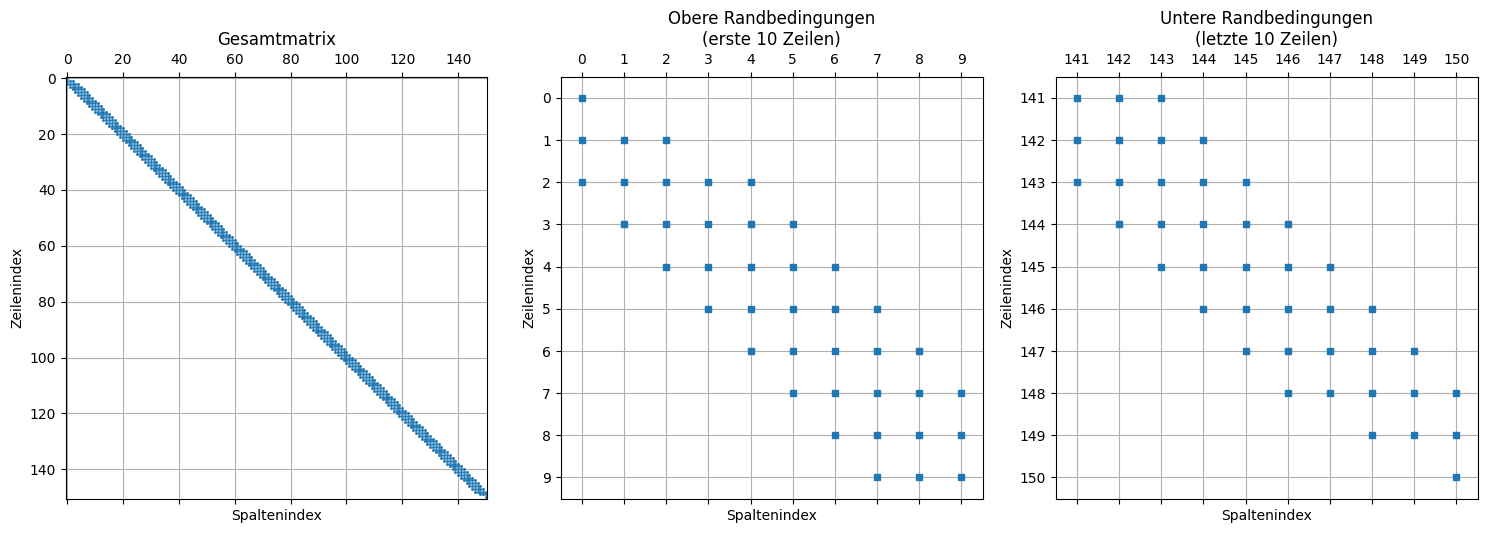

In [23]:
EIA1, _ = build_bending_matrix(boundary_condition="beidseitig_gelenkig")
plot_matrix_with_boundaries(EIA1)


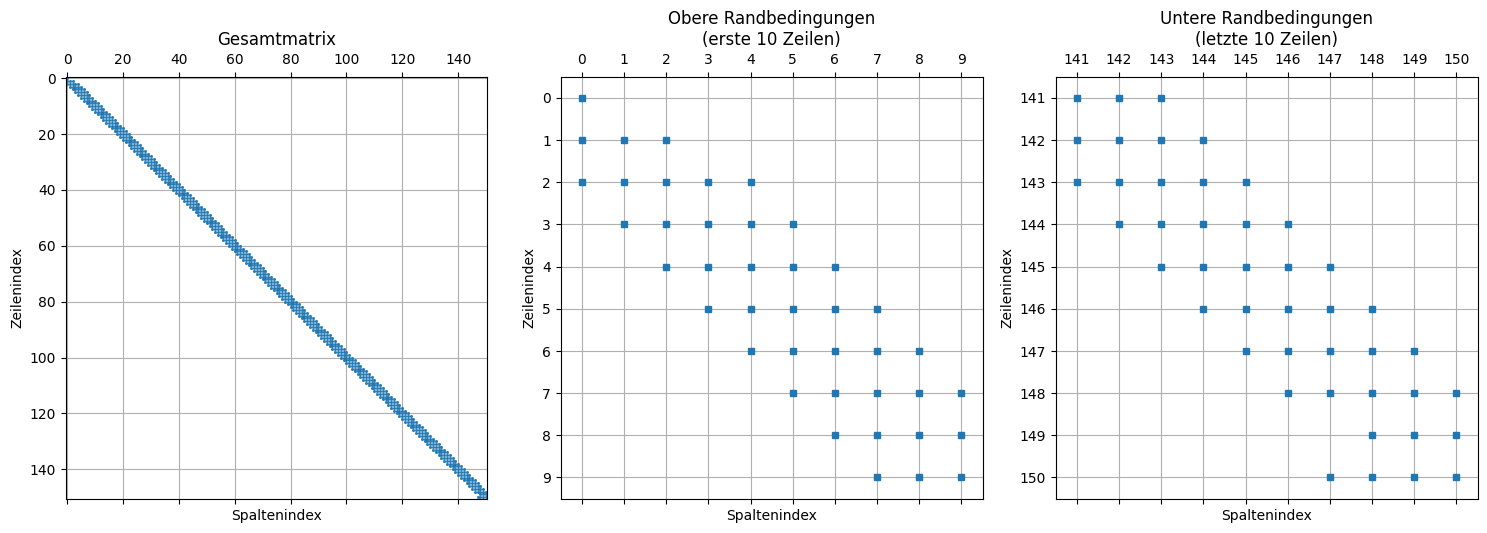

In [24]:
EIA2, _ = build_bending_matrix(boundary_condition="nur_links_eingespannt")
plot_matrix_with_boundaries(EIA2)

# Bedingung: w'''(L) = 0, Scherkraft am rechten Ende soll null sein
# Dritte Ableitung rückwärts differenziert (Rückwärts-Differenzformel):
# w'''(x_{N-1}) = (-w_{N-4} + 2 w_{N-3} - 2 w_{N-2} + w_{N-1}) / (2 h^3) = 0

# print(A2[-1,range(-4,0,1)]*(2*h**3)) # die Koeffizienten sind [-1.  2. -2.  1.]


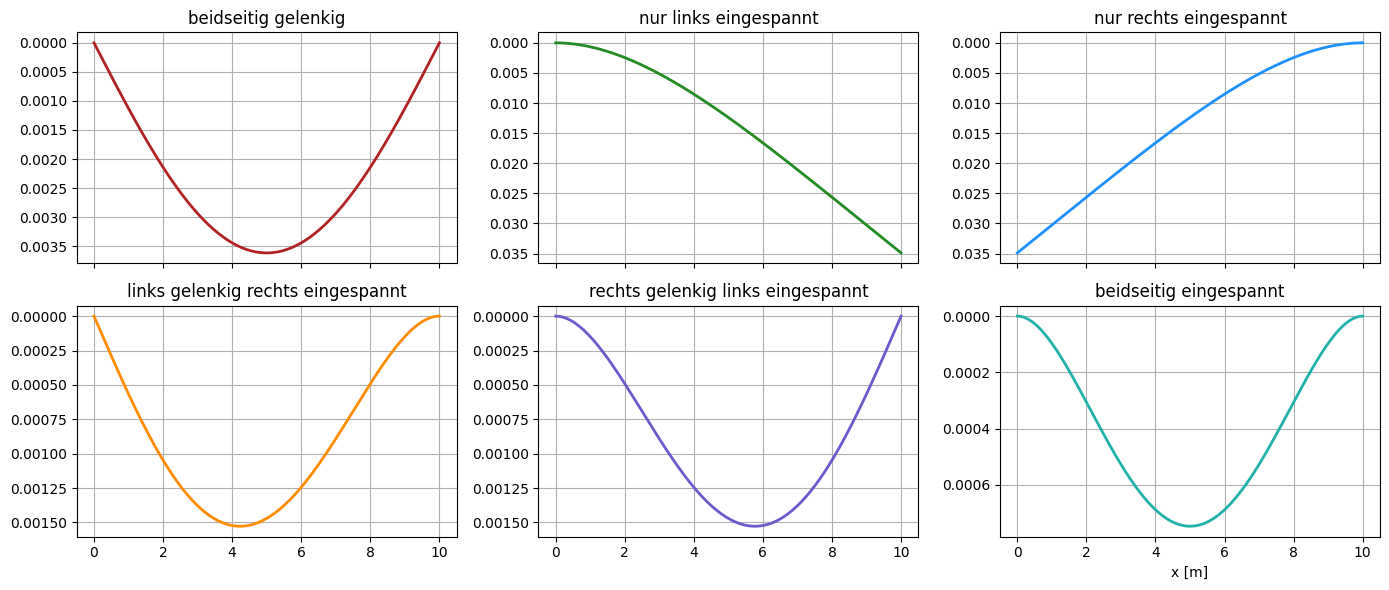

In [25]:
# Visualisierung der numerischen Lösungen

# -----------------------------------------------
# Vorbereitung der Lösung für verschiedene Randbedingungen
# -----------------------------------------------

solutions = {}

# Erstelle ein Dictionary zur besseren Lesbarkeit der Randbedingungsnamen
boundary_conditions_dict = {
    bc.replace("_", " "): bc for bc in boundary_conditions
}

# Berechne die Verschiebung w(x) für jede Randbedingung
for label, bc in boundary_conditions_dict.items():
    EIA, q_mod = build_bending_matrix(boundary_condition=bc)
    w = spsolve(EIA, q_mod) 
    solutions[label] = w

# -----------------------------------------------
# Visualisierung der Biegelinien in einem 3x2 Raster
# -----------------------------------------------

# 2x3 Raster, Anzahl der Subplots = 6
rows, cols = 2, 3

fig, axs = plt.subplots(rows, cols, sharex=True, figsize=(14, 6))  # Breite 14 Zoll, Höhe 6 Zoll und 2x3 Subplots
axs = axs.flatten()  # 2D Array in 1D umwandeln

for ax, (label, w), color in zip(axs, solutions.items(), beam_colors):
    ax.plot(x, w, color=color, linewidth=2)  # dickere Linie
    ax.set_title(label)
    ax.grid(True)
    ax.invert_yaxis()

plt.xlabel("x [m]")
plt.tight_layout()
plt.show()

## Alternative Implementierung 
### Automatische Ermittlung der Finite Differenzen Koeffizienten

Im Folgenden wird eine automatisierte Lösung vorgestellt, die sich gegenüber der Referenzlösung durch zwei wesentliche Verbesserungen auszeichnet:

1. **Symbolische Koeffizientenberechnung:**  
   Die Finite-Differenzen-Koeffizienten zur Approximation von Ableitungen werden **nicht fest eincodiert**, sondern bei Bedarf dynamisch über die Funktionen `build_taylor_matrix` und `finite_diff_coeffs` erzeugt. Dadurch ist die Lösung flexibel und leicht an andere Gitterabstände oder Ableitungsordnungen anpassbar.

2. **Effiziente Matrizenstruktur:**  
   Die Steifigkeitsmatrix wird mit der Funktion `scipy.sparse.diags` als sparse-Matrix effizient erzeugt. Für Randbedingungen wird das Format `scipy.sparse.lil_matrix` verwendet, um gezielt Zeilen zu modifizieren, bevor das System zur Lösung wieder in ein CSR-Format überführt werden kann.

Die resultierende Lösung ist numerisch **identisch** zur Referenzlösung, *sie weicht also von der exakten Lösung um dieselben Beträge ab*, ist aber in ihrer **Strukturierung automatisiert, modular und generalisierbar**.

### Übersicht der verwendeten Funktionen

| Funktion | Zweck |
|---------|-------|
| `set_dirichlet` | Erzwingt Dirichlet-Bedingung an einem Knoten |
| `build_fd_dict` | Liefert symbolisch berechnete FD-Koeffizienten als Dictionary |
| `set_explicit_derivative` | Schreibt FD-Bedingung (z. B. für $w'$, $w''$) in das Gleichungssystem |
| `apply_bc_derivative` | Kurzform: Kombination von `build_fd_dict` und `set_explicit_derivative` |
| `apply_beidseitig_gelenkig` | Setzt Randbedingungen für beidseitig gelenkig gelagerten Balken |
| `apply_nur_links_eingespannt` | Randbedingungen für Balken, der links eingespannt ist |
| `apply_nur_rechts_eingespannt` | Randbedingungen für rechts eingespannten Balken |
| `apply_links_gelenkig_rechts_eingespannt` | Gelenklager links, Einspannung rechts |
| `apply_rechts_gelenkig_links_eingespannt` | Gelenklager rechts, Einspannung links |
| `apply_beidseitig_eingespannt` | Randbedingungen für beidseitig eingespannten Balken |


In [26]:
def set_dirichlet(A, q_c, row_idx, node_idx, value=0):
    # Diese Funktion implementiert eine Dirichlet-Randbedingung in ein lineares Gleichungssystem.
    # Sie setzt den Wert einer bestimmten Unbekannten (Knotenwert) fest, indem die entsprechende
    # Gleichung so modifiziert wird, dass sie exakt diesen Wert erzwingt.
    #
    # Eingabeparameter:
    # -----------------
    # A        : Sparse-Matrix im LIL-Format (lil_matrix), Systemmatrix eines Finite-Differenzen- oder FEM-Verfahrens
    # q_c      : Rechte Seite des Gleichungssystems (1D-Numpy-Array)
    # row_idx  : Zeilenindex in A, der überschrieben werden soll (entspricht der Gleichung, die ersetzt wird)
    # node_idx : Index des Freiheitsgrads, dessen Wert festgelegt wird (Index eines Verschiebungsknotens)
    # value    : Der gewünschte Wert, den die Unbekannte annehmen soll (Standard: 0 = homogene Dirichlet-Randbedingung)
    #
    # Überschreibe die Struktur der Zeile in der Matrix A:
    # An der Stelle row_idx wird eine Gleichung der Form: 1 * u_node_idx = value eingefügt.
    # Dies erzwingt direkt u_node_idx = value.
    A.rows[row_idx] = [node_idx]  # Nur der node_idx erhält einen Koeffizienten ungleich Null
    A.data[row_idx] = [1.0]       # Der Koeffizient ist 1.0 (d.h. w[node_idx] = value)

    # Setze den entsprechenden Eintrag auf der rechten Seite q_c.
    # Dies ist das gewünschte Ergebnis der Gleichung.
    q_c[row_idx] = value          # Die Gleichung lautet nun: 1 * w[node_idx] = value


In [27]:
def build_fd_dict(node_indices, x0_idx, order, h):
    # Diese Hilfsfunktion berechnet die Finite-Differenzen-Koeffizienten zur Approximation
    # einer Ableitung beliebiger Ordnung an einem gegebenen Gitterpunkt (x0_idx) auf einem äquidistanten Gitter.
    #
    # Die Ausgabe ist ein Dictionary, das jedem beteiligten Knotenindex den zugehörigen
    # Finite-Differenzen-Koeffizienten zuordnet.
    #
    # Eingabeparameter:
    # -----------------
    # node_indices : Liste von Knotenindizes (z. B. [0, 1, 2]), die als Stützstellen verwendet werden
    # x0_idx       : Der Index des Auswertungspunkts (Stelle, an der die Ableitung approximiert wird)
    # order        : Ordnung der Ableitung (z. B. 1 für f', 2 für f'', usw.)
    # h            : Gleichmäßiger Gitterabstand (Spacing der Knoten)

    # Berechne die tatsächlichen x-Koordinaten der Stützstellen
    x_k = np.array(node_indices) * h

    # Berechne die x-Koordinate des Auswertungspunkts
    x0 = x0_idx * h

    # Berechne die Finite-Differenzen-Koeffizienten für die gewünschte Ableitung an x0
    # unter Verwendung der gegebenen Stützstellen
    coeffs = finite_diff_coeffs(x_k, x0, order)

    # Rückgabe als Dictionary: ordnet jedem Knotenindex den passenden Koeffizienten zu.
    # Beispiel: {0: 1.0, 1: -2.0, 2: 1.0}
    return dict(zip(node_indices, coeffs))

In [28]:
def set_explicit_derivative(A, q_c, row_idx, coeffs_dict, value=0):
    # Diese Funktion trägt eine explizite Finite-Differenzen-Gleichung in ein lineares Gleichungssystem ein.
    # Sie wird verwendet, um Ableitungsbedingungen (z. B. w'(x)=0, w''(x)=0, etc.)
    # in das System einzufügen, basierend auf vorher berechneten FD-Koeffizienten.
    #
    # Die Methode ersetzt eine bestehende Zeile in der Systemmatrix A und der rechten Seite q_c
    # durch eine gewichtete Linearkombination mehrerer Knotenwerte gemäß den gegebenen Koeffizienten.
    #
    # Eingabeparameter:
    # -----------------
    # A           : Sparse-Matrix im LIL-Format (lil_matrix), Systemmatrix des linearen Gleichungssystems
    # q_c         : Rechte Seite des Systems (1D-Numpy-Array)
    # row_idx     : Zeilenindex in A, der überschrieben wird (entspricht der Gleichung, die eingefügt wird)
    # coeffs_dict : Dictionary {node_idx: coeff}, das jedem beteiligten Freiheitsgrad (Knotenindex)
    #               den zugehörigen Finite-Differenzen-Koeffizienten zuordnet
    # value       : Rechter Wert der Gleichung (Standard = 0), d. h. das Ergebnis der Linearkombination

    # Setze die Struktur der Zeile row_idx in der Matrix A:
    # Die Matrixzeile enthält nur Einträge an den Stellen, die im Dictionary als Schlüssel vorhanden sind.
    # Jeder Knotenindex (node_idx) erhält den zugehörigen Koeffizienten aus coeffs_dict.
    A.rows[row_idx] = list(coeffs_dict.keys())     # Spalten (Freiheitsgrade) mit Nichtnull-Koeffizienten
    A.data[row_idx] = list(coeffs_dict.values())   # Entsprechende Koeffizienten

    # Setze den Eintrag der rechten Seite (Vektor q_c) für die Gleichung an Position row_idx.
    # Dies stellt die Bedingung dar, dass die gewichtete Summe der Knotenwerte gleich 'value' ist.
    q_c[row_idx] = value                            # Beispiel: a*w0 + b*w1 + c*w2 = value

In [29]:
def apply_bc_derivative(A, q_c, row, indices, order, h, x0_idx):
    # Diese Funktion formuliert und trägt eine Randbedingung der Form
    # w^(n)(x₀) = 0 als Zeile in das lineare Gleichungssystem ein,
    # wobei w^(n) die n-te Ableitung der Durchbiegung w ist.
    #
    # Sie verwendet dazu Finite-Differenzen-Koeffizienten, um die Ableitung
    # an der Position x[x0_idx] über die benachbarten Stützstellen
    # (definiert in 'indices') zu approximieren.
    #
    # Die Funktion dient typischerweise zur Umsetzung von Bedingungen wie:
    # - Momentenfreiheit: w''(x₀) = 0
    # - Schnittkraftfreiheit: w'''(x₀) = 0
    # - Neigungsfreiheit: w'(x₀) = 0
    #
    # Eingabeparameter:
    # -----------------
    # A       : Sparse-Matrix (lil_matrix), die Systemmatrix des Finite-Differenzen-Ansatzes
    # q_c     : Rechte Seite (1D-Array), Vektor der bekannten Terme
    # row     : Index der Zeile in A/q_c, in die die Bedingung eingetragen werden soll
    # indices : Liste von Knotenindices, die als Stützstellen für die FD-Näherung verwendet werden
    # order   : Ordnung der abzuleitenden Funktion (z. B. 2 für w'')
    # h       : Gitterabstand zwischen den Knoten (konstant angenommen)
    # x0_idx  : Index des Punkts x₀, an dem die Ableitung ausgewertet werden soll (aus 'indices')
    #
    # Funktionsweise:
    # -----------------
    # 1. Berechnet zunächst die Finite-Differenzen-Koeffizienten für die gegebene Ableitungsordnung.
    #    Die Koeffizienten sind eine Linearkombination der Werte an den Knoten 'indices',
    #    die die gewünschte Ableitung am Punkt x₀ approximieren.
    #
    # 2. Übergibt die berechneten Koeffizienten an 'set_explicit_derivative', das daraus eine
    #    Zeile im Gleichungssystem formt: Sum_i(coeff_i * w_i) = 0.
    #    Diese Gleichung ersetzt dann die Zeile 'row' in der Matrix A und im Vektor q_c.

    # Berechne die Finite-Differenzen-Koeffizienten für die n-te Ableitung an x₀
    coeffs = build_fd_dict(indices, x0_idx, order, h)

    # Trage die Gleichung mit den Koeffizienten in das Gleichungssystem ein (rechte Seite = 0)
    set_explicit_derivative(A, q_c, row, coeffs, 0)

In [30]:
def apply_beidseitig_gelenkig(A, q_c, h, N_nodes):
    # Diese Funktion setzt Randbedingungen für einen Balken mit
    # beidseitig gelenkiger Lagerung (d.h. beide Enden sind frei zu drehen, aber keine Verschiebung).
    #
    # Die Randbedingungen werden durch Modifikation der Systemmatrix A
    # und des rechten Vektors q_c definiert.
    #
    # Zeile 0: w(0) = 0
    # Zeile 1: w''(0) = 0
    # Zeile N_nodes - 2: w''(L) = 0
    # Zeile N_nodes - 1: w(L) = 0

    # Randbedingung (links): Verschiebung w(0) = 0
    # -> Dirichlet-Bedingung am linken Ende (Knoten 0)
    set_dirichlet(A, q_c, row_idx=0, node_idx=0, value=0)

    # Randbedingung (links): Krümmung w''(0) = 0
    # -> Zweite Ableitung verschwindet am linken Rand
    apply_bc_derivative(A, q_c, row=1, indices=[0, 1, 2], order=2, h=h, x0_idx=0)

    # Randbedingung (rechts): Krümmung w''(L) = 0
    # -> Zweite Ableitung verschwindet am rechten Ende
    # w''(L) = 0, mit Rückwärts-3-Punkte-Formel an Knoten N_nodes-3, N_nodes-2, N_nodes-1
    apply_bc_derivative(A, q_c, row=N_nodes-2, indices=[N_nodes-3, N_nodes-2, N_nodes-1], order=2, h=h, x0_idx=N_nodes - 1)

    # Randbedingung (rechts): Verschiebung w(L) = 0
    # -> Dirichlet-Bedingung am rechten Ende (Knoten N_nodes - 1)
    # w(L) = 0
    set_dirichlet(A, q_c, row_idx=N_nodes-1, node_idx=N_nodes-1, value=0)

In [31]:
def apply_nur_links_eingespannt(A, q_c, h, N_nodes):
    # Diese Funktion implementiert die Randbedingungen für einen Balken,
    # der nur am linken Ende eingespannt ist (klassisches einseitig eingespanntes Lager).
    #
    # Dabei wird das lineare Gleichungssystem (Matrix A und rechte Seite q_c)
    # entsprechend modifiziert, um die physikalisch gewünschten Randbedingungen
    # in Form von Dirichlet- oder Ableitungsbedingungen zu erzwingen.
    #
    # Annahme: Die Struktur besteht aus N_nodes diskreten Punkten (z. B. Gitterknoten),
    # wobei h den äquidistanten Abstand zwischen ihnen beschreibt.

    # Randbedingung (links): Verschiebung am linken Ende w(0) = 0
    # w(0) = 0 (Dirichlet am linken Ende, Knoten 0)
    set_dirichlet(A, q_c, row_idx=0, node_idx=0, value=0)

    # Randbedingung (links): Neigung w'(0) = 0
    # -> Erste Ableitung am Knoten 0 mit 3-Punkte-Vorwärtsdifferenz
    # Indices: Knoten 0, 1, 2
    apply_bc_derivative(A, q_c, row=1, indices=[0, 1, 2], order=1, h=h, x0_idx=0)

    # Randbedingung (rechts): Momentenfreiheit w'''(L) = 0
    # -> Dritte Ableitung am letzten Knoten mit 4-Punkte-Rückwärtsdifferenz
    # Indices: N-4, N-3, N-2, N-1
    apply_bc_derivative(A, q_c, row=N_nodes - 1, indices=[N_nodes - 4, N_nodes - 3, N_nodes - 2, N_nodes - 1],
       order=3, h=h, x0_idx=N_nodes-1)

    # Randbedingung (rechts): Krümmung w''(L) = 0
    # -> Zweite Ableitung am vorletzten Knoten mit 3-Punkte-Rückwärtsdifferenz
    # Indices: N-3, N-2, N-1
    apply_bc_derivative(A, q_c, row=N_nodes - 2, indices=[N_nodes - 3, N_nodes - 2, N_nodes - 1],
       order=2, h=h, x0_idx=N_nodes-1)

In [32]:
def apply_nur_rechts_eingespannt(A, q_c, h, N_nodes):
    # Diese Funktion definiert Randbedingungen für einen Balken,
    # der nur am rechten Ende eingespannt ist (rechts fest, links frei).
    #
    # Dabei werden folgende Randbedingungen angewandt:

    # Randbedingung (links): Krümmung w''(0) = 0
    # Zweite Ableitung am linken Rand mit 3-Punkte-Vorwärtsdifferenz
    # Approximation mittels 3-Punkt-Finite-Differenzen an den Knoten [0, 1, 2]
    apply_bc_derivative(A, q_c, 0, [0, 1, 2], order=2, h=h, x0_idx=0)

    # Randbedingung (links): Dreifache Ableitung w'''(0) = 0
    # Dritte Ableitung verschwindet am linken Ende
    # Approximation mit 4 Punkten [0, 1, 2, 3]
    apply_bc_derivative(A, q_c, row=1, indices=[0, 1, 2, 3], order=3, h=h, x0_idx=0)

    # Randbedingung (rechts): Steigung w'(L) = 0
    #  3-Punkt-Rückwärtsdifferenz 
    apply_bc_derivative(A, q_c, row=N_nodes - 2, 
      indices=[N_nodes - 3, N_nodes - 2, N_nodes - 1],
      order=1, h=h, x0_idx=N_nodes - 1)
    
    # Randbedingung (rechts): Verschiebung w(L) = 0
    # Dirichlet-Bedingung am rechten Randknoten
    set_dirichlet(A, q_c, row_idx=N_nodes - 1, node_idx=N_nodes - 1, value=0)

In [33]:
def apply_links_gelenkig_rechts_eingespannt(A, q_c, h, N_nodes):
    # Randbedingungen für Balken mit links gelenkigem Lager (frei drehbar, keine Verschiebung)
    # und rechts eingespannt (feste Einspannung, keine Verschiebung und Neigung).

    # Links: Verschiebung w(0) = 0 (Dirichlet)
    set_dirichlet(A, q_c, row_idx=0, node_idx=0, value=0)

    # Links: Krümmung w''(0) = 0 (freie Drehung, Moment = 0)
    # 3-Punkte-Vorwärts-Differenz
    apply_bc_derivative(A, q_c, 1, [0, 1, 2], order=2, h=h, x0_idx=0)

    # Rechts: Neigung w'(L) = 0 (eingespannt bedeutet feste Steigung)
    # 3-Punkte-Rückwärtsdifferenz
    apply_bc_derivative(A, q_c, row=N_nodes - 2, 
       indices=[N_nodes - 3, N_nodes - 2, N_nodes - 1], 
       order=1, h=h, x0_idx=N_nodes - 1)
    
    # Rechts: Verschiebung w(L) = 0 (Dirichlet)
    set_dirichlet(A, q_c, row_idx=N_nodes - 1, node_idx=N_nodes - 1, value=0)

In [34]:
def apply_rechts_gelenkig_links_eingespannt(A, q_c, h, N_nodes):
    # Randbedingungen für Balken mit rechts gelenkigem Lager (frei drehbar, keine Verschiebung)
    # und links eingespannt (feste Einspannung, keine Verschiebung und Neigung).

    # Links: Verschiebung w(0) = 0 (Dirichlet)
    set_dirichlet(A, q_c, row_idx=0, node_idx=0, value=0)

    # Links: Neigung w'(0) = 0 (eingespannt)
    # 3-Punkte Vorwärts-Diff.
    apply_bc_derivative(A, q_c, row=1, indices=[0, 1, 2], order=1, h=h, x0_idx=0)

    # Rechts: Krümmung w''(L) = 0 (frei drehbar, Moment = 0)
    # 3-Punkte Rückwärts-Diff
    apply_bc_derivative(A, q_c, row=N_nodes - 2, 
       indices=[N_nodes - 3, N_nodes - 2, N_nodes - 1], 
       order=2, h=h, x0_idx=N_nodes - 1)
    
    # Rechts: Verschiebung w(L) = 0 (Dirichlet)
    set_dirichlet(A, q_c, row_idx=N_nodes - 1, node_idx=N_nodes - 1, value=0)

In [35]:
def apply_beidseitig_eingespannt(A, q_c, h, N_nodes):
    # Randbedingungen für Balken, die an beiden Enden eingespannt sind
    # (Verschiebung und Neigung sind an beiden Enden null).

    # Links: Verschiebung w(0) = 0
    set_dirichlet(A, q_c, row_idx=0, node_idx=0, value=0)

    # Links: Neigung w'(0) = 0
    # w'(0) = 0 (Rotation links) - 5-Punkt einseitige FD mit Knoten 0..4
    # 3-Punkt Vorwärts-Differenz
    apply_bc_derivative(A, q_c, row=1, indices=[0, 1, 2], order=1, h=h, x0_idx=0)

    # Rechts: Neigung w'(L) = 0
    # Rechts: w'(L) = 0 (3-Punkt Rückwärts-Differenz)
    apply_bc_derivative(A, q_c, row=N_nodes - 2,
       indices=[N_nodes - 3, N_nodes - 2, N_nodes - 1],
       order=1, h=h, x0_idx=N_nodes - 1)

    # Rechts: Verschiebung w(L) = 0
    set_dirichlet(A, q_c, row_idx=N_nodes - 1, node_idx=N_nodes - 1, value=0)

### Das LIL-Format (List of Lists) für Sparse-Matrizen und seine Anwendung

In numerischen Berechnungen mit großen Matrizen, die überwiegend aus Nullen bestehen (sogenannte Sparse-Matrizen), ist es entscheidend, den Speicherverbrauch und die Rechenzeit durch geeignete Speicherformate zu minimieren. Die `scipy.sparse`-Bibliothek bietet hierfür verschiedene Speicherformate, die jeweils spezifische Vorteile in Bezug auf Speicherbedarf, Zugriffsgeschwindigkeit und Änderbarkeit bieten.

---

#### Überblick über Sparse-Matrix-Formate

- **CSR (Compressed Sparse Row):**
  - Speichert nur die Nicht-Null-Werte zeilenweise kompakt.
  - Besteht aus drei Arrays:
    - `data`: alle Nicht-Null-Werte,
    - `indices`: zugehörige Spaltenindizes,
    - `indptr`: Zeilenstart-Indizes im `data`-Array.
  - **Vorteile:** 
    - Sehr effizient für Matrix-Vektor-Multiplikationen (`A @ x`),
    - Schnell beim Zugriff auf ganze Zeilen,
    - Gut geeignet zur Lösung großer linearer Gleichungssysteme.

- **CSC (Compressed Sparse Column):**
  - Analog zu CSR, aber **spaltenweise** komprimiert.
  - Auch hier drei Arrays: `data`, `indices`, `indptr`, allerdings mit Fokus auf Spalten.
  - **Vorteile:** 
    - Effizient beim Zugriff auf Spalten,
    - Optimal für Operationen wie `A.T @ x` oder bei Faktorisierungen.

- **LIL (List of Lists):**
  - Speichert jede Zeile als zwei Listen:
    - `A.rows[i]`: Liste der Spaltenindizes der Nicht-Null-Elemente in Zeile `i`,
    - `A.data[i]`: Liste der entsprechenden Werte.
  - Beispiel:
    $$
    \texttt{A.rows}[i] = [j_1, j_2, ..., j_k] \quad\text{und}\quad \texttt{A.data}[i] = [a_{i,j_1}, a_{i,j_2}, ..., a_{i,j_k}]
    $$

---

#### Was ist das LIL-Format?

Das LIL-Format (List of Lists) eignet sich insbesondere für den **Aufbau** und die **nachträgliche Modifikation** einer Sparse-Matrix. Im Unterschied zu CSR oder CSC, bei denen Änderungen aufwendig und speicherintensiv sein können, erlaubt LIL dynamische Änderungen einzelner Einträge oder ganzer Zeilen mit geringem Aufwand.

##### Vorteile des LIL-Formats:

- **Einfaches Einfügen und Überschreiben von Einträgen:**
  Ideal in frühen Stadien, etwa beim sukzessiven Aufbau einer Systemmatrix.
- **Flexibler Umgang mit Zeilen:**
  Einzelne Zeilen lassen sich gezielt ersetzen oder leeren, z. B. um Randbedingungen zu implementieren.
- **Direkte Manipulation:** 
  Zugriff auf `A.rows[i]` und `A.data[i]` erlaubt direkte Änderungen der Datenstruktur ohne zusätzliche Methodenaufrufe.

**Nachteil:** Vor der eigentlichen Berechnung muss eine LIL-Matrix in ein performanteres Format wie CSR oder CSC umgewandelt werden (`A.tocsr()` bzw. `A.tocsc()`), da das LIL-Format für numerische Operationen vergleichsweise langsam ist.

---

#### Beispiel: Dirichlet-Randbedingung im LIL-Format

Bei der Lösung partieller Differentialgleichungen (z. B. mit Finite-Differenzen oder Finite-Elemente) muss man häufig **Dirichlet-Randbedingungen** erzwingen, also festlegen, dass eine bestimmte Unbekannte $u_j$ einen festen Wert $v$ annimmt.

Dies geschieht, indem man die gesamte Zeile $r$ der Systemmatrix durch eine Einheitszeile ersetzt:

- Spaltenindex: $\{j\}$,
- Wert: $\{1\}$,
- Rechte Seite: $q_c[r] = v$.

Das entspricht der Gleichung:

$$
1 \cdot u_j = v
$$

Im LIL-Format realisiert man das so:

```python
A.rows[r] = [j]
A.data[r] = [1.0]
q_c[r] = v

In [36]:
def build_bending_matrix_fd(boundary_condition):
    # Diese Funktion erzeugt die Steifigkeitsmatrix für die Balkenbiegung
    # unter Verwendung von Finite-Differenzen (FD) für die 4. Ableitung (Balkengleichung).
    #
    # Parameter:
    # -----------
    # boundary_condition : str
    #     String, der die Randbedingungen beschreibt. Erlaubte Werte sind:
    #     - "beidseitig_gelenkig"
    #     - "nur_links_eingespannt"
    #     - "nur_rechts_eingespannt"
    #
    # Rückgabe:
    # ----------
    # tuple:
    #     - EI * A: Sparse-Matrix (im CSR-Format), die das Steifigkeitsmatrix-System beschreibt.
    #     - q_c: Rechte Seite des modifizierten Gleichungssystems nach Anwendung der Randbedingungen.
    #
    # Voraussetzungen und Fehlerprüfung:
    # -----------------------------------
    # - Für "beidseitig_gelenkig" sind mindestens 5 Knoten erforderlich.
    # - Für Randbedingungen mit "eingespannt" mindestens 6 Knoten.
    # - Der Elastizitäts- und Trägheitsmodul EI muss größer als 0 sein.
    #
    # Beschreibung:
    # -------------
    # Die Matrix A beschreibt die 4. Ableitung mit einem 5-Punkt-Finite-Differenzen-Schema.
    # Die Diagonalen werden entsprechend mit den Koeffizienten der Diskretisierung belegt:
    #   -2 Nebendiagonale: +1/h^4
    #   -1 Nebendiagonale: -4/h^4
    #      Hauptdiagonale: +6/h^4
    #   +1 Nebendiagonale: -4/h^4
    #   +2 Nebendiagonale: +1/h^4
    #
    # Danach werden die Randbedingungen mit den entsprechenden Funktionen auf die Matrix und rechte Seite angewendet.

    if boundary_condition == "beidseitig_gelenkig" and N_nodes < 5:
        raise ValueError("Mindestens 5 Punkte für 'beidseitig_gelenkig' erforderlich!")
    elif "eingespannt" in boundary_condition and N_nodes < 6:
        raise ValueError("Mindestens 6 Punkte für eingespannten Rand erforderlich!")
    if EI <= 0:
        raise ValueError("EI muss größer 0 sein!")

    # Erzeuge eine Kopie des Lastvektors q, die modifiziert wird
    q_c = q.copy()

    # Erstelle die Diagonalwerte für die 4. Ableitung mit Finite-Differenzen (5-Punkt-Stencil)
    diagonals = [
        np.ones(N_nodes - 2) * (1 / h**4),          # -2 Nebendiagonale
        np.ones(N_nodes - 1) * (-4 / h**4),         # -1 Nebendiagonale
        np.ones(N_nodes) * (6 / h**4),              #    Hauptdiagonale
        np.ones(N_nodes - 1) * (-4 / h**4),         # +1 Nebendiagonale
        np.ones(N_nodes - 2) * (1 / h**4)           # +2 Nebendiagonale
    ]
    offsets = [-2, -1, 0, 1, 2]

    # Initialisiere eine Sparse-Matrix im lil-Format zur einfachen Zeilenmanipulation
    A = diags(diagonals, offsets, shape=(N_nodes, N_nodes), format='lil') # https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.diags.html
                                                                          # LIL format (Lists of Liste) ist ideal für den Aufbau und Modifikation
                                                                          # Wird verwendet, um Randbedingungen leicht einzubauen

    # Wende die spezifizierten Randbedingungen an
    match boundary_condition:
        case "beidseitig_gelenkig":
            apply_beidseitig_gelenkig(A, q_c, h , N_nodes)
        case "nur_links_eingespannt":
            apply_nur_links_eingespannt(A, q_c, h , N_nodes)
        case "nur_rechts_eingespannt":
            apply_nur_rechts_eingespannt(A, q_c, h , N_nodes)
        case "links_gelenkig_rechts_eingespannt":
            apply_links_gelenkig_rechts_eingespannt(A, q_c, h , N_nodes)
        case "rechts_gelenkig_links_eingespannt":
            apply_rechts_gelenkig_links_eingespannt(A, q_c, h , N_nodes)
        case "beidseitig_eingespannt":
            apply_beidseitig_eingespannt(A, q_c, h , N_nodes) 
        case _:
            raise ValueError(f"Unbekannte Randbedingung: '{boundary_condition}'")

    # Multipliziere Matrix A mit EI und wandle sie in das effiziente CSR-Format um.
    # Rückgabe der modifizierten Matrix und rechten Seite
    return EI * A.tocsr(), q_c # csr-Format ist ideal für Matrixmultiplikation und Solver!


# Zusammenfassung: Lösung der Balkengleichung mit Finite-Differenzen und `solve_bvp`

In den bisherigen Schritten wurde eine numerische Methode zur Lösung der Balkengleichung der Biegung zweiter Ordnung entwickelt. Die Balkengleichung wird hier als Differentialgleichung 4. Ordnung betrachtet:

$$
EI \, w^{(4)}(x) = q(x)
$$

wobei $w(x)$ die Durchbiegung, $EI$ das Biegesteifigkeitsprodukt und $q(x)$ die Querkraftlast darstellt.

Zur Diskretisierung wurde ein Finite-Differenzen-Verfahren mit einem 5-Punkte-Schema für die vierte Ableitung verwendet. Dabei wurde eine dünnbesetzte (sparse) Steifigkeitsmatrix $A$ aufgebaut, die die Finite-Differenzen-Koeffizienten auf den Haupt- und Nebendiagonalen enthält:

- Hauptdiagonale: $6/h^4$

- Erste Nebendiagonale (oben und unten): $-4/h^4$

- Zweite Nebendiagonale (oben und unten): $1/h^4$

Hierbei ist $h$ der Abstand zwischen den diskreten Knoten.

Verschiedene Randbedingungen, wie beidseitig gelenkige Lagerung, einseitig eingespannt oder beidseitig eingespannt, wurden durch spezifische Modifikationen der Matrix $A$ und des Lastvektors $q_c$ implementiert. Diese Modifikationen wurden in einzelnen Funktionen gekapselt, die je nach gewähltem Randbedingungstyp angewendet werden.

---

## Ausblick: Verwendung von `solve_bvp` zur numerischen Lösung

Die bisherige Herangehensweise nutzt ein Finite-Differenzen-Verfahren, um die Balkengleichung 4. Ordnung diskret als lineares Gleichungssystem abzubilden. Dieses System lässt sich direkt lösen und liefert die Durchbiegung $w(x)$ an diskreten Knoten. 

Eine alternative und sehr flexible Methode zur Lösung solcher Randwertprobleme ist die Verwendung der Funktion `solve_bvp` aus dem Python-Paket `scipy.integrate`. Diese Methode basiert auf der Umformulierung der Balkengleichung als System von gewöhnlichen Differentialgleichungen (ODE) erster Ordnung, was insbesondere für komplexere Randbedingungen und nichtlineare Lasten vorteilhaft ist.

### Umformulierung der Balkengleichung in ein System erster Ordnung

Die Balkengleichung

$$
EI \, w^{(4)}(x) = q(x)
$$

ist eine Differentialgleichung vierter Ordnung für die Durchbiegung $w(x)$. Um sie mit `solve_bvp` behandeln zu können, wird sie in ein System von vier gekoppelten Differentialgleichungen erster Ordnung umgeschrieben. Dazu werden neue Zustandsvariablen eingeführt:

$$
y_0 = w, \quad y_1 = w', \quad y_2 = w'', \quad y_3 = w'''
$$

Die Ableitungen dieser Zustandsvariablen lassen sich nun schreiben als

$$
\begin{cases}
y_0' = y_1 \\
y_1' = y_2 \\
y_2' = y_3 \\
y_3' = \frac{q(x)}{EI}
\end{cases}
$$

Das heißt, anstelle einer einzigen Gleichung 4. Ordnung behandeln wir ein System von 4 Gleichungen 1. Ordnung.

---

### Aufbau der Funktionen für `solve_bvp`

Um die Balkengleichung mit `solve_bvp` zu lösen, müssen zwei wesentliche Funktionen definiert werden:

1. **Die Ableitungsfunktion $fun(x, y)$:**

   `solve_bvp` erwartet ein System von gewöhnlichen Differentialgleichungen erster Ordnung. Die Balkengleichung 4. Ordnung

   $$
   EI \frac{d^4 w}{dx^4} = q(x)
   $$

   wird durch Einführung der Zustandsvariablen

   $$
   y_0 = w, \quad y_1 = w', \quad y_2 = w'', \quad y_3 = w'''
   $$

   in ein System von vier gekoppelte Gleichungen erster Ordnung umgeformt:

   $$
   \begin{cases}
   y_0' = y_1 \\
   y_1' = y_2 \\
   y_2' = y_3 \\
   y_3' = \frac{q(x)}{EI}
   \end{cases}
   $$

   Die Funktion $fun(x, y)$ gibt also den Vektor der Ableitungen $y'$ zurück:

   $$
   fun(x, y) =
   \begin{pmatrix}
   y_1 \\
   y_2 \\
   y_3 \\
   \frac{q(x)}{EI}
   \end{pmatrix}
   $$

2. **Die Randbedingungsfunktion $bc(ya, yb)$:**

   Diese Funktion definiert die Randbedingungen am linken Rand $x=a$ (Zustandsvektor $ya$) und am rechten Rand $x=b$ (Zustandsvektor $yb$).

   Sie gibt einen Vektor zurück, dessen Komponenten die sogenannten **Residuen** der Randbedingungen darstellen.  

   **Residuen** messen, wie stark die momentane Lösung die Randbedingungen verletzt. Sind die Residuen für alle Bedingungen exakt null, so werden die Randbedingungen exakt erfüllt.

   Beispielsweise gilt für die Randbedingung $w(0) = 0$ das Residuum:

   $$
   r_1 = ya_0 - 0 = ya_0
   $$

   Nur wenn $r_1 = 0$ ist, erfüllt die Lösung diese Randbedingung exakt. Für $w'(L) = 0$ ist das Residuum

   $$
   r_2 = yb_1 - 0 = yb_1
   $$

   Die numerische Routine `solve_bvp` versucht, eine Lösung $y(x)$ zu finden, bei der alle Residuen möglichst klein (idealerweise null) sind. So gewährleistet sie, dass die Randbedingungen genau eingehalten werden.

---

### Vorteile der `solve_bvp`-Methode

- **Hohe Flexibilität bei Randbedingungen:** Durch Anpassung der Randbedingungsfunktion $bc$ können verschiedenste Lagerungsbedingungen (frei, gelenkig, eingespannt) und Kombinationen davon einfach modelliert werden.
- **Beliebige Lastfunktionen $q(x)$:** Die Belastung kann als analytische Funktion vorliegen und muss nicht auf diskrete Stützstellen approximiert werden.
- **Adaptive Gitterverfeinerung:** `solve_bvp` wählt die Stützstellen automatisch so, dass die Lösung mit hoher Genauigkeit auch bei komplexen Lasten und in Randbereichen mit großen Gradienten gelingt.
- **Erweiterbarkeit:** Das Verfahren lässt sich problemlos auf nichtlineare oder gekoppelte Systeme erweitern.

---

Im nächsten Schritt formulieren wir die Balkengleichung explizit als System erster Ordnung und implementieren die Funktionen $fun$ und $bc$. Anschließend verwenden wir `solve_bvp`, um die Gleichung mit den zuvor diskutierten Randbedingungen numerisch zu lösen. Dies ermöglicht eine flexible und präzise Analyse verschiedener Balkensituationen unter unterschiedlichen Lasten.

---

In [37]:
def fun(x, y, EI, q):
    """
    Ableitungsfunktion für die Balkengleichung 4. Ordnung,
    umgeschrieben als System erster Ordnung.
    fun(x, y) soll die rechte Seite deines Differentialgleichungssystems zurückgeben, also dy/dx = f(x, y)
    
    Parameter:
    ----------
    x : float oder np.ndarray
        Der aktuelle Ort im Balken (Skalar oder Vektor).
    y : np.ndarray
        Zustandsvektor mit den Variablen:
            y[0] = w(x)   (Auslenkung)
            y[1] = w'(x)  (Neigung)
            y[2] = w''(x) (Krümmung)
            y[3] = w'''(x) (3. Ableitung)
    EI : float
        Biegesteifigkeit des Balkens (Elastizitätsmodul * Flächenträgheitsmoment).
        Muss größer als 0 sein.
    q : callable
        Lastfunktion q(x), die die Belastung an der Stelle x angibt.

    Rückgabe:
    ---------
    dydx : np.ndarray
        Vektor der Ableitungen des Zustandsvektors y, also y'.
        Entsprechend gilt:
            y'[0] = y[1]
            y'[1] = y[2]
            y'[2] = y[3]
            y'[3] = q(x)/EI

    Beschreibung:
    -------------
    Die 4. Ableitung der Auslenkung w(x) wird über die Balkengleichung
    definiert als:
        EI * w''''(x) = q(x)
    Daraus folgt:
        w''''(x) = q(x) / EI

    Da solve_bvp nur Systeme erster Ordnung lösen kann,
    wird ein Zustandsvektor y mit 4 Komponenten definiert,
    sodass die Ableitungen als Vektor zurückgegeben werden.
    """
    # Berechne die Ableitungen y' für alle Punkte x
    dydx = np.vstack((   # https://numpy.org/devdocs/reference/generated/numpy.vstack.html
        y[1],            # w' = y1
        y[2],            # w'' = y2
        y[3],            # w''' = y3
        q(x) / EI        # w'''' = q(x)/EI
    ))
    return dydx

In [38]:
def bc_beidseitig_gelenkig(ya, yb):
    """
    Randbedingungen für Balken, der beidseitig gelenkig gelagert ist.
    (frei drehbar, keine Verschiebung an beiden Enden)

    Randbedingungen:
    - Links: w(0) = 0          (Auslenkung verschwindet)
    - Links: Moment M(0) = 0   => w''(0) = 0 (freie Drehung, keine Krümmung)
    - Rechts: w(L) = 0
    - Rechts: Moment M(L) = 0  => w''(L) = 0

    Parameter:
    ----------
    ya : np.ndarray
        Zustandsvektor am linken Rand x=a, enthält [w, w', w'', w'''] bei x=0
    yb : np.ndarray
        Zustandsvektor am rechten Rand x=b, enthält [w, w', w'', w'''] bei x=L

    Rückgabe:
    ---------
    residuen : np.ndarray
        Residuen der Randbedingungen (Vektor der Abweichungen von 0).
    """
    return np.array([
        ya[0],     # w(0) = 0
        ya[2],     # w''(0) = 0 (Moment = 0)
        yb[0],     # w(L) = 0
        yb[2]      # w''(L) = 0 (Moment = 0)
    ])

In [39]:
def bc_nur_links_eingespannt(ya, yb):
    """
    Randbedingungen für Balken, der nur links eingespannt ist (rechts frei).

    Randbedingungen:
    - Links: w(0) = 0          (keine Verschiebung)
    - Links: w'(0) = 0         (keine Neigung, feste Einspannung)
    - Rechts: Moment M(L) = 0  => w''(L) = 0 (frei drehbar)
    - Rechts: Querkraft V(L) = 0 => w'''(L) = 0 (keine Schubkraft)

    Parameter:
    ----------
    ya : np.ndarray
        Zustandsvektor am linken Rand x=0
    yb : np.ndarray
        Zustandsvektor am rechten Rand x=L

    Rückgabe:
    ---------
    residuen : np.ndarray
    """
    return np.array([
        ya[0],     # w(0) = 0
        ya[1],     # w'(0) = 0
        yb[2],     # w''(L) = 0 (Moment)
        yb[3]      # w'''(L) = 0 (Querkraft)
    ])


In [40]:
def bc_nur_rechts_eingespannt(ya, yb):
    """
    Randbedingungen für Balken, der nur rechts eingespannt ist (links frei).

    Randbedingungen:
    - Links: Moment M(0) = 0 => w''(0) = 0 (frei drehbar)
    - Links: Querkraft V(0) = 0 => w'''(0) = 0
    - Rechts: w(L) = 0        (keine Verschiebung)
    - Rechts: w'(L) = 0       (keine Neigung, feste Einspannung)

    Parameter:
    ----------
    ya : np.ndarray
    yb : np.ndarray

    Rückgabe:
    ---------
    residuen : np.ndarray
    """
    return np.array([
        ya[2],     # w''(0) = 0
        ya[3],     # w'''(0) = 0
        yb[0],     # w(L) = 0
        yb[1]      # w'(L) = 0
    ])


In [41]:
def bc_links_gelenkig_rechts_eingespannt(ya, yb):
    """
    Randbedingungen für Balken mit links gelenkigem Lager und rechts eingespannt.

    Randbedingungen:
    - Links: w(0) = 0          (keine Verschiebung)
    - Links: Moment M(0) = 0   => w''(0) = 0 (frei drehbar)
    - Rechts: w(L) = 0         (keine Verschiebung)
    - Rechts: w'(L) = 0        (keine Neigung, feste Einspannung)

    Parameter:
    ----------
    ya : np.ndarray
    yb : np.ndarray

    Rückgabe:
    ---------
    residuen : np.ndarray
    """
    return np.array([
        ya[0],     # w(0) = 0
        ya[2],     # w''(0) = 0
        yb[0],     # w(L) = 0
        yb[1]      # w'(L) = 0
    ])


In [42]:
def bc_rechts_gelenkig_links_eingespannt(ya, yb):
    """
    Randbedingungen für Balken mit rechts gelenkigem Lager und links eingespannt.

    Randbedingungen:
    - Links: w(0) = 0          (keine Verschiebung)
    - Links: w'(0) = 0         (keine Neigung, feste Einspannung)
    - Rechts: w(L) = 0         (keine Verschiebung)
    - Rechts: Moment M(L) = 0  => w''(L) = 0 (frei drehbar)

    Parameter:
    ----------
    ya : np.ndarray
    yb : np.ndarray

    Rückgabe:
    ---------
    residuen : np.ndarray
    """
    return np.array([
        ya[0],     # w(0) = 0
        ya[1],     # w'(0) = 0
        yb[0],     # w(L) = 0
        yb[2]      # w''(L) = 0
    ])


In [43]:
def bc_beidseitig_eingespannt(ya, yb):
    """
    Randbedingungen für Balken, der beidseitig eingespannt ist.

    Randbedingungen:
    - Links: w(0) = 0          (keine Verschiebung)
    - Links: w'(0) = 0         (keine Neigung)
    - Rechts: w(L) = 0         (keine Verschiebung)
    - Rechts: w'(L) = 0        (keine Neigung)

    Parameter:
    ----------
    ya : np.ndarray
    yb : np.ndarray

    Rückgabe:
    ---------
    residuen : np.ndarray
    """
    return np.array([
        ya[0],     # w(0) = 0
        ya[1],     # w'(0) = 0
        yb[0],     # w(L) = 0
        yb[1]      # w'(L) = 0
    ])

In [44]:
def get_bc_function(boundary_condition):
    """
    Gibt die passende Randbedingungsfunktion für solve_bvp zurück,
    basierend auf dem String boundary_condition.

    Parameters
    ----------
    boundary_condition : str
        Beschreibung der Randbedingung, z.B.:
        - "beidseitig_gelenkig"
        - "nur_links_eingespannt"
        - "nur_rechts_eingespannt"
        - "links_gelenkig_rechts_eingespannt"
        - "rechts_gelenkig_links_eingespannt"
        - "beidseitig_eingespannt"

    Returns
    -------
    bc_func : function
        Funktion bc(ya, yb), die Residuen der Randbedingungen zurückgibt.
    """
    mapping = {
        "beidseitig_gelenkig": bc_beidseitig_gelenkig,
        "nur_links_eingespannt": bc_nur_links_eingespannt,
        "nur_rechts_eingespannt": bc_nur_rechts_eingespannt,
        "links_gelenkig_rechts_eingespannt": bc_links_gelenkig_rechts_eingespannt,
        "rechts_gelenkig_links_eingespannt": bc_rechts_gelenkig_links_eingespannt,
        "beidseitig_eingespannt": bc_beidseitig_eingespannt
    }

    if boundary_condition not in mapping:
        raise ValueError(f"Unbekannte Randbedingung: '{boundary_condition}'")

    return mapping[boundary_condition]

In [45]:
# Die Lastfunktion q(x) beschreibt die Belastung des Balkens entlang seiner Länge.
# Sie kann beliebig definiert werden, z. B. als konstante Kraft, linienförmig
# veränderliche Last oder komplexe verteilte Lasten. q0 ist als eine globale Variable definiert.

def q_constant(x):
    """Konstante Last q(x) = q0"""
    return q0 * np.ones_like(x)

def q_linear(x):
    """Linienförmig veränderliche Last, z.B. q(x) = q0 * (1 - x/L)"""
    L = x[-1]
    return q0 * (1 - x / L)

def q_custom(x):
    """Beispiel einer komplexeren Lastfunktion, z.B. sinusförmig"""
    L = x[-1]
    return q0 * np.sin(np.pi * x / L)


In [46]:
# Diskretisierungspunkte x sind bereits definiert (global):
#    x = np.linspace(0, L, N_nodes)
#
# Definition der Zustandsvariable y:
# Da wir ein System 1. Ordnung lösen, wird y ein Array mit 4 Zeilen sein:
#
#    y[0] = w       (Verschiebung)
#    y[1] = w'      (erste Ableitung)
#    y[2] = w''     (zweite Ableitung)
#    y[3] = w'''    (dritte Ableitung)
#
# Für die Startschätzung initialisieren wir y als Nullvektor:
y_init = np.zeros((4, x.size))

# Auswahl der Randbedingung. Möglichkeiten:
#
#   "beidseitig_gelenkig"
#   "nur_links_eingespannt"
#   "nur_rechts_eingespannt"
#   "links_gelenkig_rechts_eingespannt"
#   "rechts_gelenkig_links_eingespannt"
#   "beidseitig_eingespannt"

boundary_condition = "beidseitig_gelenkig"  # zum Beispiel

# Hole die passende Randbedingungsfunktion mit get_bc_function
bc = get_bc_function(boundary_condition)

# Wahl der Lastfunktion für das Problem
q_wahl = q_constant

# Hier wird ein Lambda genutzt, um EI und q an die Funktionsdefinition zu übergeben.
# Das wrapped_fun nimmt nur x und y, genau wie solve_bvp es verlangt.
# Ein lambda in Python ist eine Ausdrucksform zur Definition einer anonymen, einstufigen Funktion.
# Sie besitzt die Syntax lambda argumente: ausdruck und entspricht funktional einer mittels def definierten Funktion, 
# jedoch ohne Namen und ausschließlich mit einem einzelnen Ausdruck als Funktionsrumpf.
wrapped_fun = lambda x, y: fun(x, y, EI, q_wahl)  # q_wahl ist hier z. B. q_constant (eine Funktion), wie zuvor definiert.

# solve_bvp, mit der ausgewählten Randbedingung
solution = solve_bvp(fun=wrapped_fun, bc=bc, x=x, y=y_init)

# Lösung auswerten an den gegebenen Stützstellen x
y_solved = solution.sol(x)

w      = y_solved[0]  # Durchbiegung
w_x    = y_solved[1]  # Neigung
w_xx   = y_solved[2]  # Krümmung
w_xxx  = y_solved[3]  # Biegemomentverlauf proportional


In [47]:
def test_all_conditions(f):

    results = []

    bc_list = boundary_conditions

    asol = analytical_solutions

    # Legt die Anzahl der Zeilen und Spalten für die Subplots fest
    rows, cols = 2, 3
    
    # Erzeugt ein Figure-Objekt mit einem Gitter von Subplots (2 Zeilen x 3 Spalten)
    # Die x-Achse wird zwischen den Subplots geteilt (sharex=True)
    fig, axs = plt.subplots(rows, cols, figsize=(15, 8), sharex=True)
    
    # Die Achsenobjekte in ein flaches Array umwandeln, um sie leichter iterieren zu können
    axs = axs.flatten() # https://numpy.org/doc/2.1/reference/generated/numpy.ndarray.flatten.html

    # Iteriere über jedes Achsenobjekt, die Randbedingung und die Farbe der Kurven
    for ax, bc, clr in zip(axs, bc_list, beam_colors):
        # Rufe die Funktion f mit der aktuellen Randbedingung auf
        # Erwartet wird entweder:
        # - Tuple (EIA, q_adj) für das lineare Gleichungssystem (Finite-Differenzen-Ansatz), oder
        # - Tuple (None, w_num) für die Lösung mit solve_bvp
        result = f(boundary_condition=bc)

        # Prüfe, ob die erste Komponente None ist (Indikator für solve_bvp-Lösung)
        if result[0] is None:
            # Direkt die numerische Lösung aus dem Rückgabewert entnehmen
            w_num = result[1]
        else:
            # Sonst liegt ein lineares Gleichungssystem vor:
            EIA, q_adj = result
            # Löst das lineare Gleichungssystem EIA * w_num = q_adj numerisch, um die Biegelinie zu erhalten
            w_num = spsolve(EIA, q_adj)        
        
        # Berechnet die analytische Lösung der Biegelinie an den Stützstellen x für die aktuelle Randbedingung
        w_ana = asol[bc](x)

        #=========================#
        # Fehler berechnen Anfang #
        #=========================#
        
        # Relative Fehler in der L2-Norm (euklidische Norm):
        # Die L2-Norm misst die quadratische Abweichung über alle Stützstellen.
        # Sie ist besonders empfindlich gegenüber größeren Fehlern an einzelnen Punkten,
        # da die Fehler quadriert und summiert werden, bevor die Wurzel gezogen wird.
        # Die Division durch die L2-Norm der analytischen Lösung normalisiert den Fehler,
        # sodass er dimensionslos und vergleichbar zwischen verschiedenen Fällen ist.
        err_L2 = np.linalg.norm(w_num - w_ana, ord=2) / np.linalg.norm(w_ana, ord=2)

        # Relative Fehler in der L1-Norm (Manhattan-Norm):
        # Die L1-Norm summiert die absoluten Beträge der Fehler über alle Stützstellen.
        # Sie ist robuster gegenüber Ausreißern als die L2-Norm und gibt einen 
        # Durchschnittsfehler über den gesamten Bereich an.
        # Die Normierung durch die L1-Norm der analytischen Lösung ermöglicht einen
        # direkten Vergleich der Fehlergröße relativ zur Gesamtlösung.
        err_L1 = np.linalg.norm(w_num - w_ana, ord=1) / np.linalg.norm(w_ana, ord=1)

        # Relative Fehler in der L∞-Norm (Maximumsnorm):
        # Diese Norm betrachtet nur den maximalen absoluten Fehler an irgendeinem Punkt.
        # Sie ist nützlich, um den schlimmsten Einzelfehler zu bestimmen,
        # was für sicherheitskritische Anwendungen wichtig sein kann.
        # Die Normierung durch die maximale absolute Auslenkung der analytischen Lösung
        # macht den Fehler relativ und vergleichbar.
        err_Linf = np.linalg.norm(w_num - w_ana, ord=np.inf) / np.linalg.norm(w_ana, ord=np.inf)

        #=======================#
        # Fehler berechnen Ende #
        #=======================#

        # Ergebniszeile anhängen
        results.append({
            "Methode": f.__name__,           
            "Randbedingung": bc,
            "Fehler L2-Norm": err_L2,
            "Fehler L1-Norm": err_L1,
            "Fehler L∞-Norm": err_Linf
        })

        # Zeichnet die numerische Lösung als durchgezogene Linie in der jeweiligen Farbe
        ax.plot(x, w_num, color=clr, linestyle='-', linewidth=1, label='Numerisch')
        
        # Zeichnet die analytische Lösung als gestrichelte Linie in der gleichen Farbe
        ax.plot(x, w_ana, color=clr, linestyle='--', linewidth=1, label='Analytisch')
        
        # Setzt den Titel des Subplots mit der Bezeichnung der Randbedingung
        ax.set_title(f"Randbedingung: {bc}")
        
        # Beschriftet die x-Achse
        ax.set_xlabel('x [m]')
        
        # Beschriftet die y-Achse
        ax.set_ylabel('w(x)')
        
        # Aktiviert das Gitternetz für bessere Lesbarkeit
        ax.grid(True)
        
        # Kehrt die y-Achse um, sodass größere Auslenkungen nach unten zeigen (üblich bei Biegelinien)
        ax.invert_yaxis()

        # Bestimmt den maximalen Wert zwischen numerischer und analytischer Lösung für die Skalierung der y-Achse
        y_max = max(w_num.max(), w_ana.max())
        
        # Erhöht den maximalen Wert um 10% Puffer, um die Grafik nicht am Rand enden zu lassen
        y_lim = y_max * 1.1
        
        # Setzt 8 gleichmäßig verteilte Tick-Marken auf der y-Achse von 0 bis y_lim
        ax.set_yticks(np.linspace(0, y_lim, 8))

        # Fügt eine Legende hinzu mit kleinerer Schriftgröße
        ax.legend(fontsize=8)

    # Optimiert das Layout, sodass sich Subplots und Achsenbeschriftungen nicht überlappen
    plt.tight_layout()
    
    # Zeigt die erstellten Plots an
    plt.show()

    return results

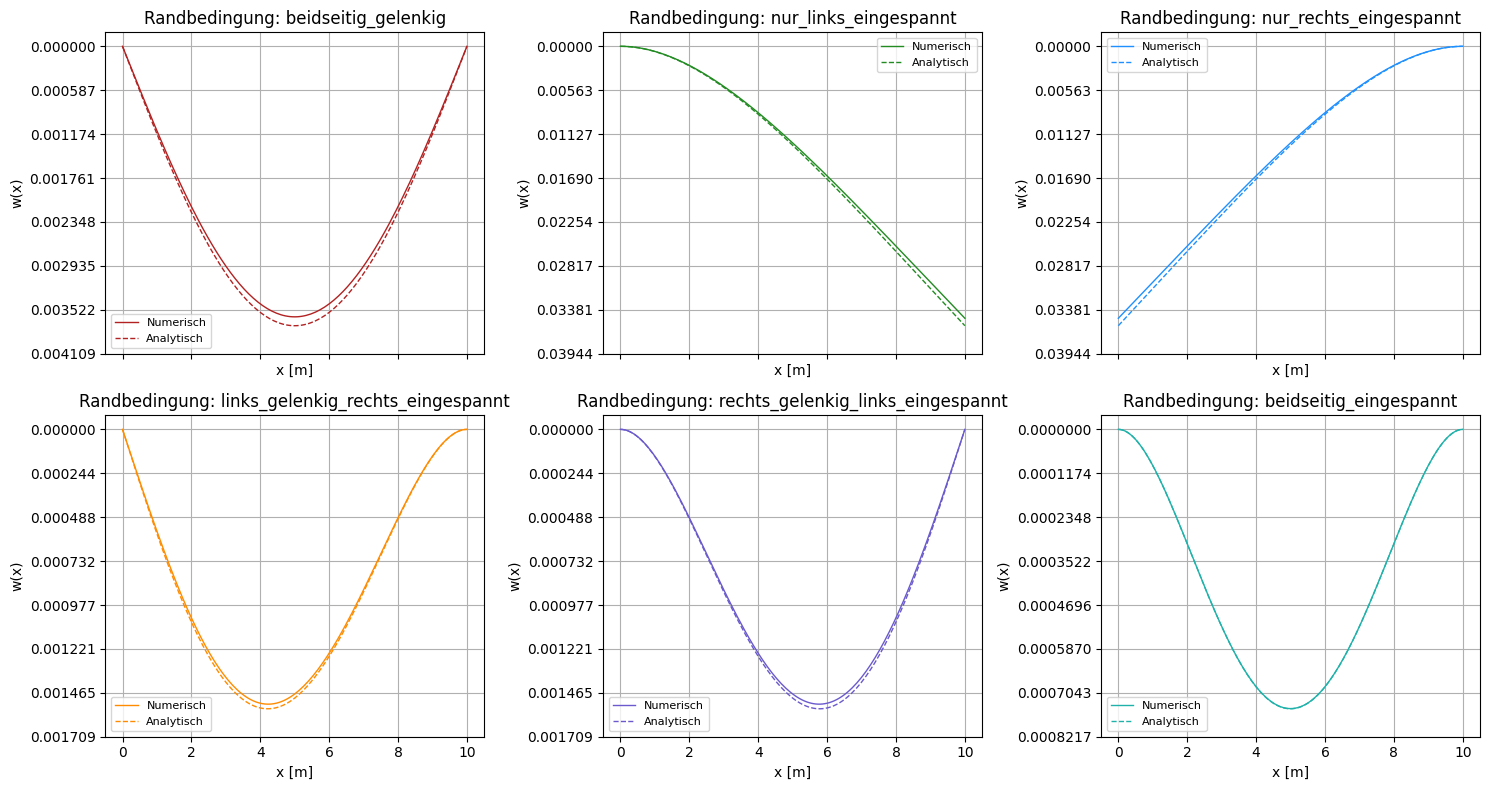

In [48]:
results_build_bending_matrix = test_all_conditions(build_bending_matrix) # Referenzlösung

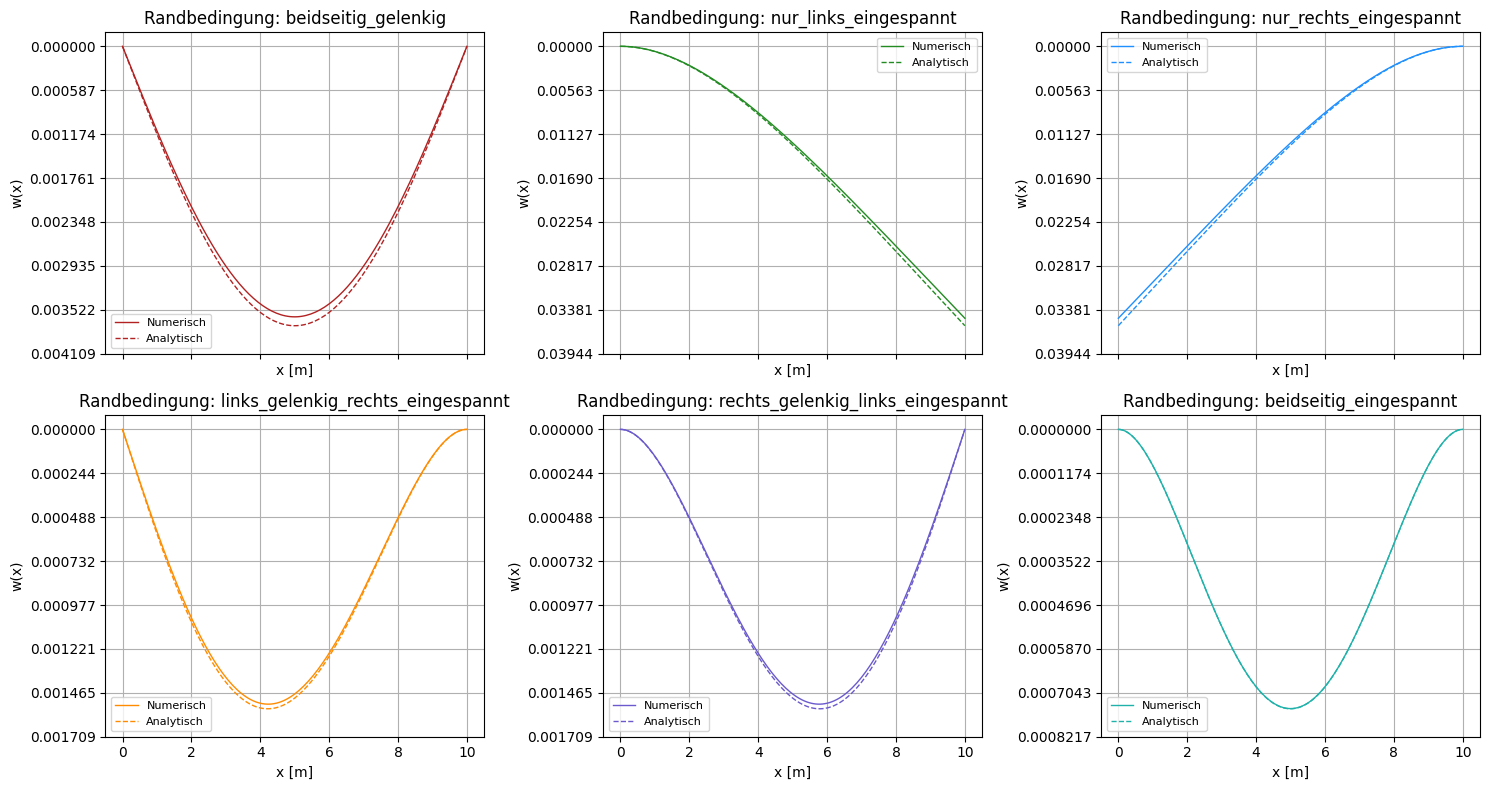

In [49]:
results_build_bending_matrix_fd = test_all_conditions(build_bending_matrix_fd) # Modulare Lösung

In [50]:
def solve_with_bvp(boundary_condition):
    bc_func = get_bc_function(boundary_condition)
    fun_bvp = lambda x, y: fun(x, y, EI, q_wahl)
    sol = solve_bvp(fun_bvp, bc_func, x, y_init)
    w_num = sol.sol(x)[0]
    return None, w_num

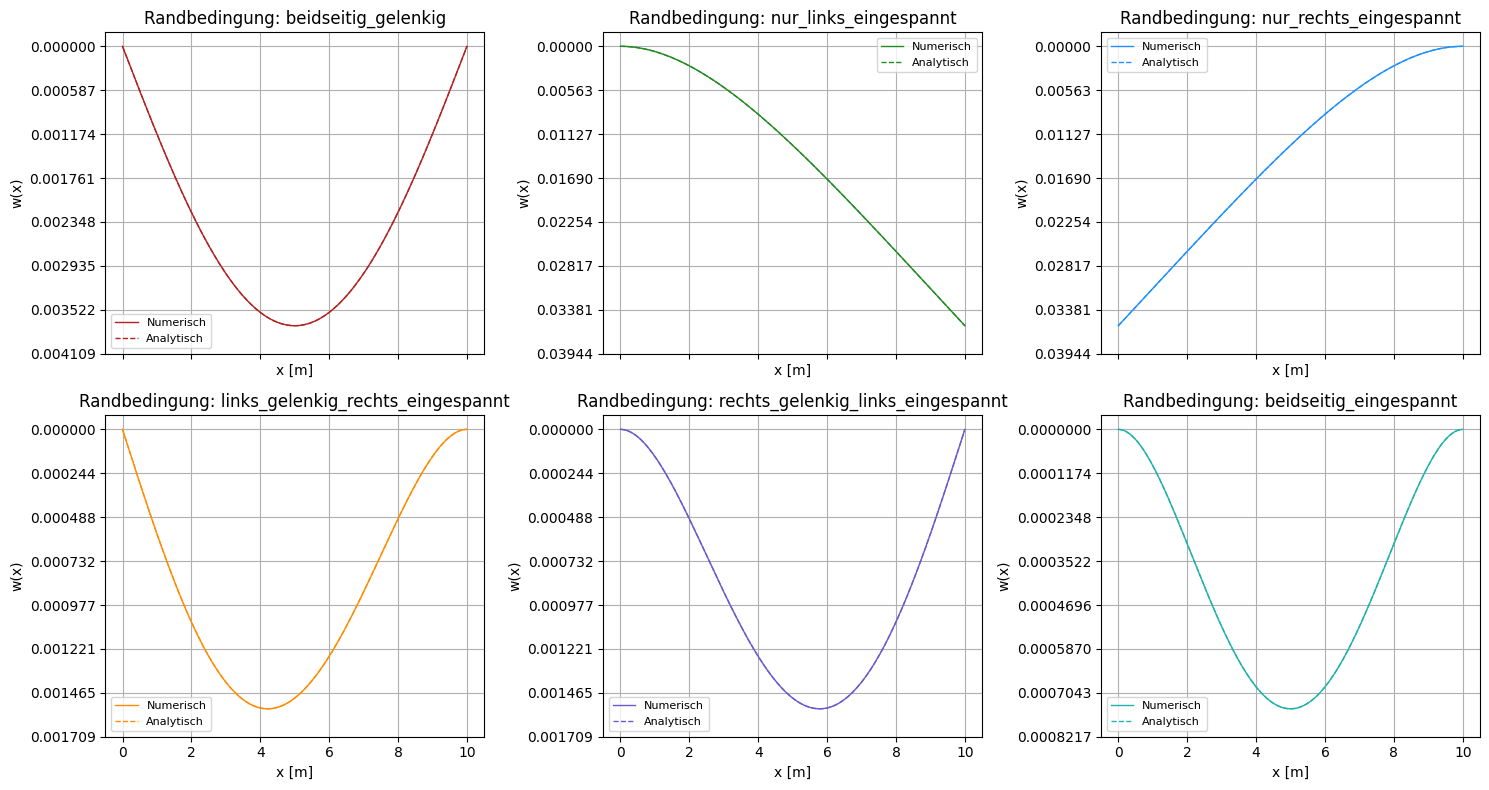

In [51]:
results_solve_bvp = test_all_conditions(solve_with_bvp)

## Fehleranalyse für den Fall "beidseitig_gelenkig"

Im Folgenden analysieren wir die Fehler der numerischen Verschiebungslösungen im Fall der beidseitig gelenkigen Randbedingung. 

Dazu werden zunächst die Verschiebungen mit drei Verfahren berechnet:
- Finite-Differenzen-Methode (manuell)
- Finite-Differenzen-Methode (automatisch)
- Boundary Value Problem (BVP) Lösung

Anschließend werden die absoluten Fehler dieser numerischen Lösungen gegenüber der analytischen Lösung berechnet und graphisch dargestellt – sowohl im linearen als auch im logarithmischen Maßstab. 

Darüber hinaus vergleichen wir die Fehlerdifferenzen der numerischen Methoden untereinander, um deren Übereinstimmung und Unterschiede sichtbar zu machen.  

Die folgenden Codezellen führen diese Berechnungen und Visualisierungen durch.

In [52]:
# Ergebnisse aus Funktionen holen
result = []
result.append(build_bending_matrix(boundary_condition="beidseitig_gelenkig"))
result.append(build_bending_matrix_fd(boundary_condition="beidseitig_gelenkig"))

# Verschiebungen berechnen
w_analytisch = analytical_solution_beidseitig_gelenkig(x)
w1 = spsolve(result[0][0], result[0][1])
w2 = spsolve(result[1][0], result[1][1]) 
_, w3 = solve_with_bvp(boundary_condition="beidseitig_gelenkig")

# Fehler berechnen (absolute Abweichung zur analytischen Lösung)
err1 = np.abs(w1 - w_analytisch)
err2 = np.abs(w2 - w_analytisch)
err3 = np.abs(w3 - w_analytisch)

# Sehr kleine Werte begrenzen
epsilon = 1e-120
err1[err1 < epsilon] = epsilon
err2[err2 < epsilon] = epsilon
err3[err3 < epsilon] = epsilon


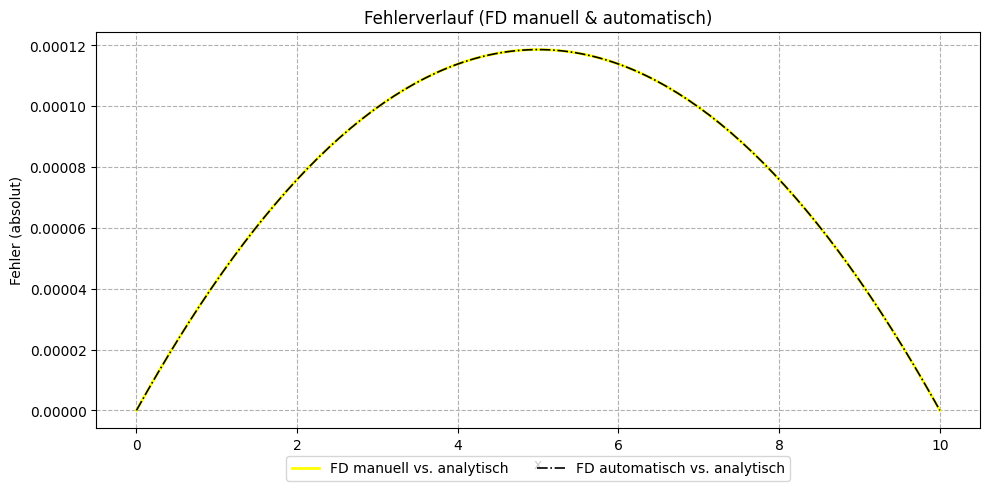

In [78]:
plt.figure(figsize=(10, 5))
plt.plot(x, err1, label="FD manuell vs. analytisch", color="yellow", linewidth=2)
plt.plot(x, err2, label="FD automatisch vs. analytisch", color="black", linestyle='-.', linewidth=1.2)
plt.xlabel("x")
plt.ylabel("Fehler (absolut)")
plt.title("Fehlerverlauf (FD manuell & automatisch)")
# bbox_to_anchor=(0.5, -0.15) schiebt die Legende horizontal auf die Mitte (0.5) und vertikal etwas nach unten (−0.15) außerhalb der Plot-Box.
# x = 0.5 --> Horizontal bei 50 % der Breite des Bezugssystems (also genau in der Mitte).
# y = -0.15 --> Vertikal etwas unterhalb der untersten Achsenlinie (weil negative Werte außerhalb der Achsenbox liegen).
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()


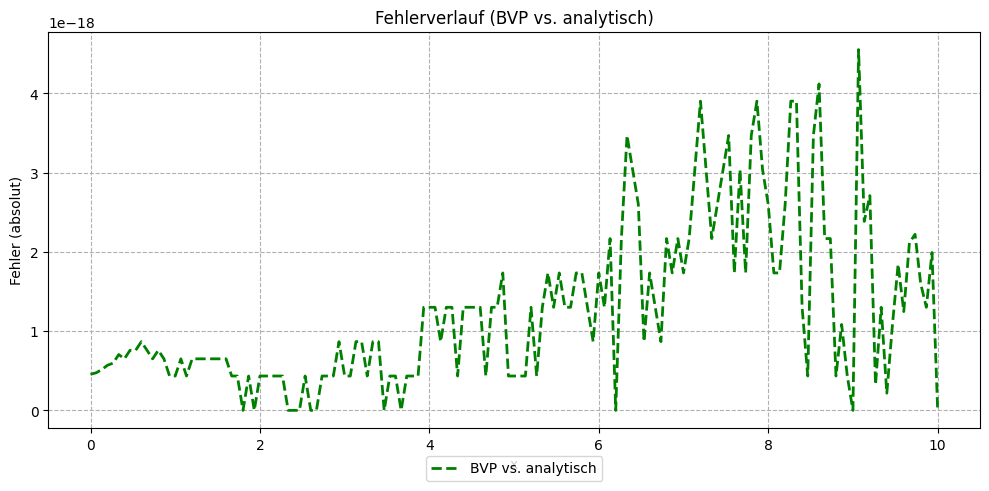

In [79]:
plt.figure(figsize=(10, 5))
plt.plot(x, err3, label="BVP vs. analytisch", color="green", linestyle='--', linewidth=2)
plt.xlabel("x")
plt.ylabel("Fehler (absolut)")
plt.title("Fehlerverlauf (BVP vs. analytisch)")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=1)
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

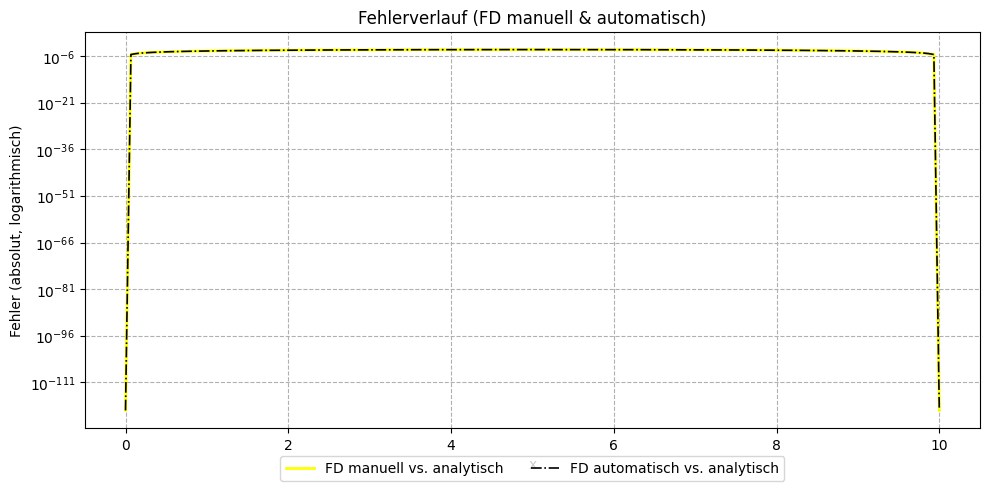

In [80]:
plt.figure(figsize=(10, 5))
plt.semilogy(x, err1, label="FD manuell vs. analytisch", color="yellow", linewidth=2)
plt.semilogy(x, err2, label="FD automatisch vs. analytisch", color="black", linestyle='-.', linewidth=1.2)
plt.xlabel("x")
plt.ylabel("Fehler (absolut, logarithmisch)")
plt.title("Fehlerverlauf (FD manuell & automatisch)")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()


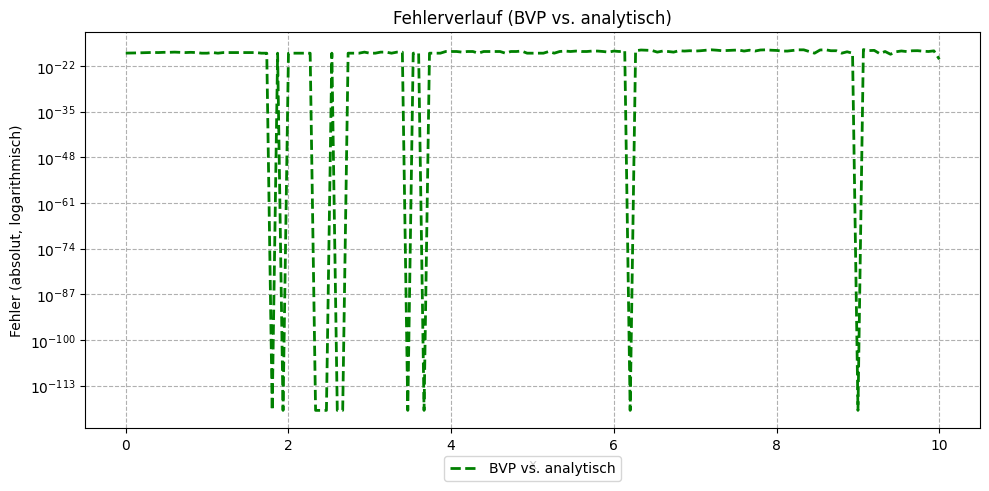

In [81]:
plt.figure(figsize=(10, 5))
plt.semilogy(x, err3, label="BVP vs. analytisch", color="green", linestyle='--', linewidth=2)
plt.xlabel("x")
plt.ylabel("Fehler (absolut, logarithmisch)")
plt.title("Fehlerverlauf (BVP vs. analytisch)")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=1)
plt.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()


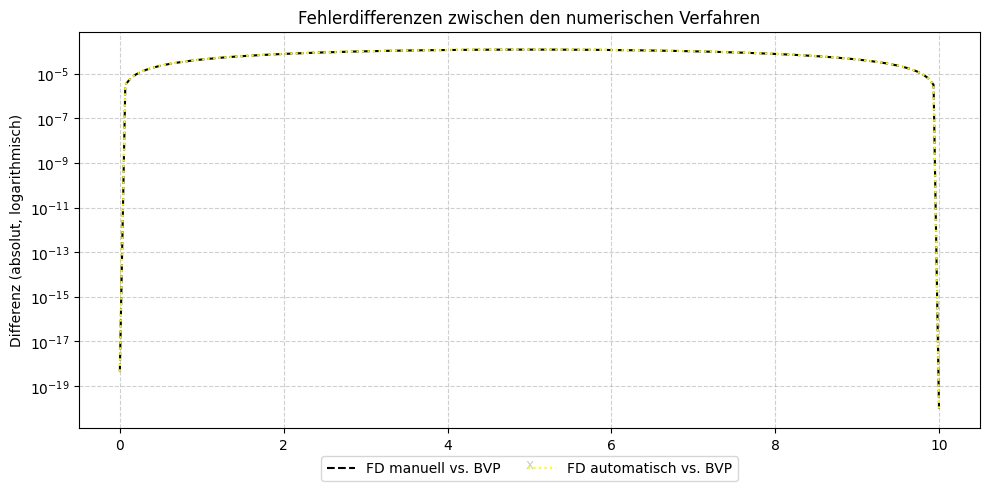

In [82]:
def set_min_positive(arr):
    positive_vals = arr[arr > 0]
    if len(positive_vals) == 0:
        # Falls keine positiven Werte, setze auf 1 (oder epsilon)
        return np.zeros_like(arr)
    min_pos = np.min(positive_vals)
    arr_corrected = np.copy(arr)
    arr_corrected[arr_corrected <= 0] = min_pos
    return arr_corrected

# Differenzen zwischen den numerischen Methoden
diff_1_2 = np.abs(w1 - w2)  # FD manuell vs. FD automatisch
diff_1_3 = np.abs(w1 - w3)  # FD manuell vs. BVP
diff_2_3 = np.abs(w2 - w3)  # FD automatisch vs. BVP

diff_1_2 = set_min_positive(diff_1_2)
diff_1_3 = set_min_positive(diff_1_3)
diff_2_3 = set_min_positive(diff_2_3)

plt.figure(figsize=(10, 5))
plt.semilogy(x, diff_1_3, label="FD manuell vs. BVP", color="black", linestyle='--', linewidth=1.5)
plt.semilogy(x, diff_2_3, label="FD automatisch vs. BVP", color="yellow", linestyle=':', linewidth=1.5)

plt.xlabel("x")
plt.ylabel("Differenz (absolut, logarithmisch)")
plt.title("Fehlerdifferenzen zwischen den numerischen Verfahren")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



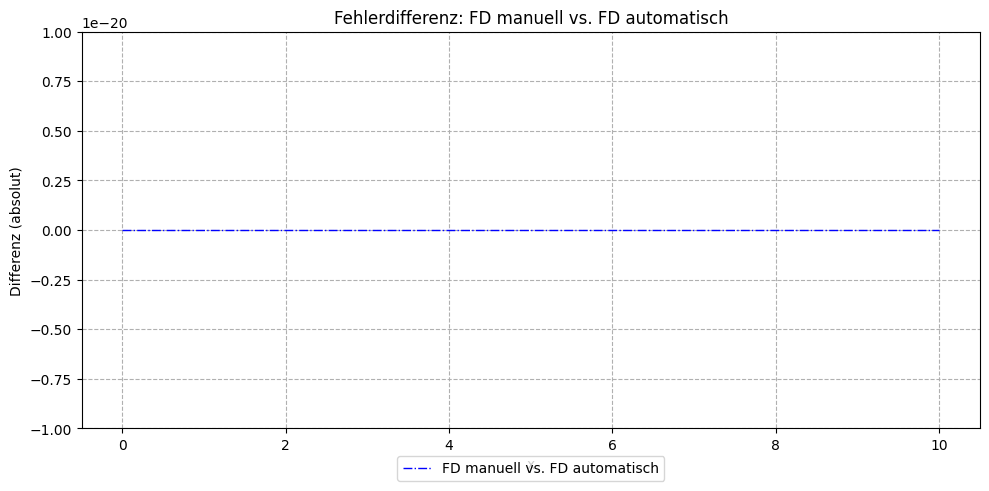

In [85]:
plt.figure(figsize=(10, 5))
plt.plot(x, diff_1_2, label="FD manuell vs. FD automatisch", color="blue", linestyle='-.', linewidth=1.0)
plt.xlabel("x")
plt.ylabel("Differenz (absolut)")
atol=1e-20 # absolute Toleranz
plt.ylim(-atol,+atol)
plt.title("Fehlerdifferenz: FD manuell vs. FD automatisch")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=1)
plt.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()


## Fehlervergleich und Zusammenfassung der Ergebnisse aller Randbedingungen und Methoden

In den folgenden Zellen werden die gesammelten Fehlerdaten aus drei unterschiedlichen numerischen Verfahren (Referenzmethode (Finite-Differenzen-Methode manuell), Finite-Differenzen-Methode (automatisch), BVP-Lösung) jeweils als Pandas DataFrame organisiert. 

Diese Daten liegen als Listen von Dictionaries vor, die Informationen zu Randbedingung, Methode und verschiedenen Fehlermaßen (L1-, L2- und Maximumsnorm) enthalten.

Durch das Umwandeln in DataFrames und das Zusammenführen in eine kombinierte Pivot-Tabelle können wir die Fehlerwerte tabellarisch übersichtlich vergleichen und auswerten.

Anschließend werden die Fehlernormen (L1, L2, L∞) in separaten Tabellen dargestellt, mit farblicher Hervorhebung, die zeigt, wie nahe sich die Fehler der Methoden zueinander verhalten.

Dies erleichtert die Bewertung und Interpretation der Genauigkeit der verschiedenen numerischen Verfahren über alle Randbedingungen hinweg.


In [59]:
# Erstelle aus den Rückgabewerten der drei Testläufe jeweils einen Pandas DataFrame.
# Die Variablen 'results_build_bending_matrix', 'results_build_bending_matrix_fd' und
# 'results_solve_bvp' enthalten jeweils eine Liste von Dictionaries.
# Jedes Dictionary repräsentiert die Resultate für eine spezifische Randbedingung und Methode,
# und beinhaltet folgende Schlüssel: "Methode", "Randbedingung", "Fehler L2-Norm", "Fehler L1-Norm" und "Fehler L∞-Norm".
# Durch die Umwandlung in einen DataFrame werden diese Listen tabellarisch strukturiert und 
# sind einfacher für Datenanalyse und Visualisierung nutzbar.
df_ref = pd.DataFrame(results_build_bending_matrix)        # DataFrame mit Fehlerdaten der Referenzmethode
df_fd = pd.DataFrame(results_build_bending_matrix_fd)      # DataFrame mit Fehlerdaten der Finite-Differenzen-Methode (FD)
df_bvp = pd.DataFrame(results_solve_bvp)                   # DataFrame mit Fehlerdaten der Lösung über Boundary Value Problem (BVP)

# Kombiniere alle drei DataFrames zeilenweise (vertikal).
# Dabei werden die Zeilen untereinandergehängt, so dass ein großer DataFrame
# entsteht, der alle Fehlerwerte aller Randbedingungen und Methoden enthält.
# Die Differenzierung der Methoden erfolgt durch die Spalte "Methode".
# Dies ermöglicht es, alle Ergebnisse in einer gemeinsamen Tabelle zu analysieren,
# wobei jede Zeile eine Kombination aus Randbedingung und Methode darstellt.
df_all = pd.concat([df_ref, df_fd, df_bvp])

# Erzeuge eine Pivot-Tabelle aus dem kombinierten DataFrame.
# Eine Pivot-Tabelle ordnet die Daten neu an, so dass:
# - Die Zeilen durch 'index="Randbedingung"' nach den Randbedingungen gruppiert sind,
#   also jede Zeile entspricht einer spezifischen Randbedingung.
# - Die Spalten durch 'columns="Methode"' in Gruppen für jede Methode unterteilt sind,
#   so dass für jede Methode eine eigene Spalte entsteht.
# - Die Werte, die in die Zellen eingetragen werden, sind die Fehlermaße
#   ("Fehler L2-Norm", "Fehler L1-Norm", "Fehler L∞-Norm").
# Das Ergebnis ist eine Tabelle mit hierarchischem Spaltenindex (MultiIndex):
# Die erste Ebene sind die Fehlerarten, die zweite Ebene die jeweiligen Methoden.
pivot_df = df_all.pivot_table(
    index="Randbedingung",
    columns="Methode",
    values=["Fehler L2-Norm", "Fehler L1-Norm", "Fehler L∞-Norm"]
)

# Extrahiere nun einzelne DataFrames für jede Fehlernorm aus der Pivot-Tabelle.
# Dies ist nützlich, wenn man die Fehler für jede Norm separat betrachten,
# visualisieren oder vergleichen möchte.
# Dabei bleibt der Index die Randbedingung, und die Spalten sind die Methoden.
df_L1 = pivot_df["Fehler L1-Norm"]   # DataFrame für die L1-Norm, alle Methoden nebeneinander
df_L2 = pivot_df["Fehler L2-Norm"]   # DataFrame für die L2-Norm, alle Methoden nebeneinander
df_Linf = pivot_df["Fehler L∞-Norm"] # DataFrame für die Maximumsnorm, alle Methoden nebeneinander


In [60]:
# Funktion zur farblichen Hervorhebung von Zellen in einer Zeile,
# basierend auf der Differenz zwischen den ersten beiden Spaltenwerten.
def highlight_equal_values(row):
    # Extrahiere die Werte aus der ersten und zweiten Spalte der gegebenen Zeile.
    val1 = row.iloc[0]
    val2 = row.iloc[1]

    # Berechne die absolute Differenz zwischen den beiden Werten.
    diff = abs(val1 - val2)

    # Verwende ein `match-case`, um die Differenz in Toleranzbereiche einzuteilen.
    # Je nach Bereich wird eine bestimmte Hintergrundfarbe ausgewählt.
    match diff:
        # Falls die Abweichung extrem klein ist (< 1e-30), dann grün (nahezu identisch).
        case d if d < 1e-30:
            color = 'lightgreen'
        # Falls die Abweichung klein ist (< 1e-15), dann hellorange (noch gut).
        case d if d < 1e-15:
            color = 'lightsalmon'
        # Falls die Abweichung etwas größer ist (< 1e-9), dann gelblich (noch akzeptabel).
        case d if d < 1e-9:
            color = 'khaki'
        # Falls die Abweichung größer als alle obigen Schwellen ist,
        # wird keine Farbe gesetzt (leere Zeichenkette).
        case _:
            return [''] * len(row)

   # Wir erstellen hier eine Liste von CSS-Stilstrings, die später Zeile für Zeile
    # an die Pandas-Styling-Engine übergeben wird, um einzelne Zellen farblich zu formatieren.

    # Die Idee ist:
    # - Wir möchten die ersten beiden Zellen (Spalten) der Zeile farblich hervorheben,
    #   wenn ihre Werte fast gleich sind (innerhalb eines gewissen Toleranzbereichs).
    # - Die restlichen Zellen der Zeile (z. B. Abweichungen, Indexspalte etc.) sollen
    #   keine Farbformatierung erhalten.

    # Teil 1: [f'background-color: {color}'] * 2
    # - Dies erzeugt eine Liste mit zwei Einträgen, z. B.:
    #   ['background-color: lightgreen', 'background-color: lightgreen']
    # - Diese Formatierung wird also **für die ersten zwei Zellen** der Zeile angewendet.

    # Teil 2: [''] * (len(row) - 2)
    # - Diese erzeugt eine Liste mit leeren Formatierungsstrings für die restlichen Zellen.
    # - 'len(row)' gibt die Gesamtanzahl der Zellen (Spalten) in dieser Zeile an.
    # - Wir ziehen 2 ab, weil die ersten beiden Zellen schon oben behandelt wurden.
    # - Ergebnis ist z. B. [''] * 3 --> ['','', ''] für drei Spalten ohne Formatierung.

    # Schließlich werden beide Listen über das Pluszeichen zu einer einzigen Liste
    # zusammengefügt und zurückgegeben.
    # Beispiel-Ergebnis für eine Zeile mit 5 Spalten:
    # ['background-color: lightgreen', 'background-color: lightgreen', '', '', '']
    return [f'background-color: {color}'] * 2 + [''] * (len(row) - 2)


# Funktion zum Anzeigen einer Tabelle mit Fehlernormen inklusive farblicher Hervorhebung
# sowie einer passenden mathematischen Formel (als LaTeX) oberhalb der Tabelle.
def show_norm_table_colored(df, norm_name):
    # Ein Dictionary mit den LaTeX-Formeln für die verschiedenen Fehlernormen.
    # Jede Formel wird in \displaystyle gesetzt für größere Darstellung.
    formulas = {
        "L1-Norm": r"\displaystyle \|e\|_1 = \frac{\sum_{i=1}^n |w_{\text{num},i} - w_{\text{ana},i}|}{\sum_{i=1}^n |w_{\text{ana},i}|}",
        "L2-Norm": r"\displaystyle \|e\|_2 = \frac{\sqrt{\sum_{i=1}^n (w_{\text{num},i} - w_{\text{ana},i})^2}}{\sqrt{\sum_{i=1}^n (w_{\text{ana},i})^2}}",
        "L∞-Norm": r"\displaystyle \|e\|_\infty = \frac{\max_{i} |w_{\text{num},i} - w_{\text{ana},i}|}{\max_i |w_{\text{ana},i}|}"
    }

    # Zeige eine Markdown-Überschrift über der Tabelle, z. B. "Fehler L1-Norm".
    display(Markdown(f"### Fehler {norm_name}"))

    # Zeige die zur Norm passende LaTeX-Formel in vergrößerter Schrift.
    # Die Formel wird direkt im Markdown gerendert (zwischen $...$).
    display(Markdown(f"$\n\Large{formulas[norm_name]}\n$"))

    # Style die Tabelle:
    # - Zeige alle Zahlen mit 20 Dezimalstellen.
    # - Wende die Funktion `highlight_equal_values` auf jede Zeile an (axis=1).
    styled = df.style.format(precision=20).apply(highlight_equal_values, axis=1)

    # Zeige die formatierte Tabelle.
    display(styled)


# Drei Tabellen mit Fehlerwerten für unterschiedliche Normen werden angezeigt.
# Die Tabellen selbst (df_L1, df_L2, df_Linf) müssen vorher erstellt worden sein.
show_norm_table_colored(df_L1, "L1-Norm")
show_norm_table_colored(df_L2, "L2-Norm")
show_norm_table_colored(df_Linf, "L∞-Norm")


### Fehler L1-Norm

$
\Large\displaystyle \|e\|_1 = \frac{\sum_{i=1}^n |w_{\text{num},i} - w_{\text{ana},i}|}{\sum_{i=1}^n |w_{\text{ana},i}|}
$

Methode,build_bending_matrix,build_bending_matrix_fd,solve_with_bvp
Randbedingung,,,
beidseitig_eingespannt,0.00087996087126870882,0.00087996087126946602,0.00000000000000143423
beidseitig_gelenkig,0.03307382912767369704,0.03307382912767369704,0.00000000000000053166
links_gelenkig_rechts_eingespannt,0.01702406798932509790,0.01702406798932496260,0.00000000000000188264
nur_links_eingespannt,0.02502348967863452303,0.02502348989262631954,0.00000000000000047073
nur_rechts_eingespannt,0.02502348992878346973,0.02502348935493873758,0.00000000000000289995
rechts_gelenkig_links_eingespannt,0.01702406794260144171,0.01702406794260144171,0.00000000000000110842


### Fehler L2-Norm

$
\Large\displaystyle \|e\|_2 = \frac{\sqrt{\sum_{i=1}^n (w_{\text{num},i} - w_{\text{ana},i})^2}}{\sqrt{\sum_{i=1}^n (w_{\text{ana},i})^2}}
$

Methode,build_bending_matrix,build_bending_matrix_fd,solve_with_bvp
Randbedingung,,,
beidseitig_eingespannt,0.00080653330265144840,0.00080653330265222198,0.00000000000000206861
beidseitig_gelenkig,0.03266613416062408293,0.03266613416062408293,0.00000000000000061755
links_gelenkig_rechts_eingespannt,0.01715960603256452138,0.01715960603256441036,0.00000000000000177610
nur_links_eingespannt,0.02555020866128882018,0.02555020887994861531,0.00000000000000057620
nur_rechts_eingespannt,0.02555020891698638399,0.02555020833044148107,0.00000000000000286800
rechts_gelenkig_links_eingespannt,0.01715960598724879105,0.01715960598724879105,0.00000000000000166948


### Fehler L∞-Norm

$
\Large\displaystyle \|e\|_\infty = \frac{\max_{i} |w_{\text{num},i} - w_{\text{ana},i}|}{\max_i |w_{\text{ana},i}|}
$

Methode,build_bending_matrix,build_bending_matrix_fd,solve_with_bvp
Randbedingung,,,
beidseitig_eingespannt,0.00070399998148754236,0.00070399998148826801,0.00000000000000522482
beidseitig_gelenkig,0.03175111115459857553,0.03175111115459857553,0.00000000000000121912
links_gelenkig_rechts_eingespannt,0.01733807780995334780,0.01733807780995320902,0.00000000000000281426
nur_links_eingespannt,0.02662044429742746812,0.02662044452542199416,0.00000000000000096756
nur_rechts_eingespannt,0.02662044456429176267,0.02662044395237161271,0.00000000000000290268
rechts_gelenkig_links_eingespannt,0.01733807776696905806,0.01733807776696905806,0.00000000000000553910
